# Steam Hybrid V3 Recommender - MERGED FULL NOTEBOOK

Notebook này đã gộp 2 file trước đó thành 1 luồng chạy thống nhất:

- **Cell 0 → 7**: chuẩn bị dữ liệu, train/load ALS, Item2Item, fine-tune encoder, build FAISS/BM25.
- **Cell 8A → 8E**: build sequence dataset, train/evaluate Text-Enhanced SASRec, load Hybrid Engine và patch SASRec vào engine.
- **Cell 9 → 15**: đánh giá candidate recall, train reranker, đánh giá final, demo query và API.

## Cách chạy nhanh nếu artifact đã có trong Google Drive

Nếu đã từng chạy xong Cell 2→7 và 8A→8E rồi, sau khi Runtime bị ngắt chỉ cần chạy lại:

1. Install packages.
2. `%%writefile cell_0.py` và `%run cell_0.py`.
3. `%%writefile cell_8.py` và cell `%run cell_8.py` để load `ENGINE`.
4. `%%writefile cell_8e.py` và cell `%run cell_8e.py` để patch SASRec nếu đã train SASRec.
5. Cell 9 / 9B để đánh giá candidate recall.
6. Cell 10 + 10B nếu cần build feature cho reranker.
7. Cell 11B nếu cần train LightGBM reranker.
8. Cell 12A nếu chỉ muốn chuẩn bị hàm load reranker cho demo; Cell 12B nếu muốn evaluate final.
9. Cell 13 + 13B hoặc Cell 14 để demo query.
10. Cell 15 chỉ chạy nếu cần mở API demo.

## Cách chạy từ đầu hoàn toàn

Chạy theo đúng thứ tự logic: **0 → 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8A → 8B → 8C → 8D → 8 → 8E → 9 → 9B → 10 → 10B → 11B → 12A → 12B → 13 → 13B/14 → 15**.

Lưu ý: Cell 6 full train và Cell 8C train SASRec có thể rất lâu. Cell 9/12 nếu để full val/test 4.1M cũng rất lâu, nên mặc định dùng sample để demo trước.


---
# PHẦN A - CELL 0 ĐẾN CELL 7: DATA + BASE HYBRID ARTIFACTS


## Hệ thống Hướng mới nhất của hệ thống là Hybrid V3

Không phải “V3 thuần SASRec” và cũng không phải “V2 cũ”. Hướng mới nhất đang là:

`Hybrid V3 = V2 Candidate Engine + Text-Enhanced SASRec`

Tức là hệ thống cuối cùng gồm các nhánh:

```text
1. Dense NLP / FAISS
2. BM25 lexical search
3. ALS collaborative filtering
4. Item-to-Item co-visitation
5. Popular fallback
6. Text-Enhanced SASRec
```

**cell_8.py** hiện vẫn là CandidateEngineV2, nó load các nhánh Dense NLP, BM25, ALS, Item2Item, Popular. Trong code CandidateEngineV2, các branch này được khai báo rõ: Dense NLP FAISS, BM25, ALS, Item-to-Item và Popular fallback.

Còn **cell_0.py** đã có thêm các path V3 như SEQ_TRAIN_PATH, SEQ_TRAIN_VAL_PATH, SEQ_VAL_TARGET_PATH, SEQ_TEST_TARGET_PATH, TEXT_SASREC_MODEL_PATH, RERANKER_V3_MODEL_PATH.

Nghĩa là code hiện tại là V2 nền + V3 mở rộng, không phải bỏ toàn bộ V2.

- 1. Nếu build lại từ đầu hoàn toàn, Chạy theo thứ tự này:
`cell_0.py -> ... -> cell_7.py -> cell_8a.py -> cell_8b.py -> cell_8c.py -> cell_8d.py -> cell_8.py -> cell_8e.py`

- Ý nghĩa:
```text
0   = khai báo toàn bộ path/config
1   = audit dữ liệu gốc
2   = build game document store + popular fallback
3   = build item/user mapping + ALS sparse matrix
4   = train/load ALS model
5   = build Item2Item co-visitation
6   = fine-tune multilingual sentence encoder
7   = build NLP FAISS + BM25
8A  = build sequence dataset cho SASRec
8B  = define Text-Enhanced SASRec
8C  = train Text-Enhanced SASRec
8D  = evaluate SASRec standalone
8   = load full CandidateEngine V2
8E  = patch thêm SASRec vào ENGINE

Sau đó mới chạy các cell sau nếu có:

9B / 10 / 10B / 11B / 12B / 13B
```

Lần sau chạy lại ko cần chạy:
```text
cell_1.py
cell_2.py
cell_3.py
cell_4.py
cell_5.py
cell_6.py
cell_7.py
```

In [ ]:
!pip install -q duckdb faiss-cpu lightgbm sentence-transformers rank-bm25 implicit pyarrow fastparquet scipy scikit-learn tqdm fastapi uvicorn nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 59.9 MB/s eta 0:00:00


In [ ]:
%%writefile cell_0.py
# ============================================================
# CELL 0: INSTALL + IMPORT + GLOBAL CONFIG
# ============================================================

# !pip install -q duckdb faiss-cpu lightgbm sentence-transformers rank-bm25 implicit pyarrow fastparquet scipy scikit-learn tqdm fastapi uvicorn nest_asyncio

import os
import re
import gc
import json
import time
import math
import pickle
import random
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import duckdb
import faiss
import scipy.sparse as sp
import lightgbm as lgb

from tqdm.notebook import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, InputExample, losses

import torch
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from google.colab import drive
drive.mount("/content/drive")

# =========================
# PATH CONFIG
# =========================

BASE_PATH = "/content/drive/MyDrive/steam/steam_base2"
MODEL_DIR = f"{BASE_PATH}/models_nlp_v2"
CACHE_DIR = f"{BASE_PATH}/cache_nlp_v2"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

TRAIN_PATH = f"{BASE_PATH}/train_interactions.parquet"
VAL_PATH = f"{BASE_PATH}/val_interactions.parquet"
TEST_PATH = f"{BASE_PATH}/test_interactions.parquet"

USER_FEAT_PATH = f"{BASE_PATH}/user_features_full.parquet"
GAME_FEAT_PATH = f"{BASE_PATH}/game_features_enhanced.parquet"
GAME_API_PATH = f"{BASE_PATH}/game_features_api_enriched.parquet"

GAME_DOCS_PATH = f"{CACHE_DIR}/game_documents.parquet"
POPULAR_PATH = f"{CACHE_DIR}/popular_games.parquet"

ALS_PAIRS_PATH = f"{CACHE_DIR}/als_train_pairs.parquet"
USER_ITEM_MATRIX_PATH = f"{CACHE_DIR}/user_item_train.npz"
USER2IDX_PATH = f"{CACHE_DIR}/user2idx.pkl"
IDX2USER_PATH = f"{CACHE_DIR}/idx2user.pkl"
ITEM2IDX_PATH = f"{CACHE_DIR}/item2idx.pkl"
IDX2ITEM_PATH = f"{CACHE_DIR}/idx2item.pkl"

ITEM2ITEM_PATH = f"{CACHE_DIR}/item2item_topk.parquet"

BASE_EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
FINETUNED_ENCODER_DIR = f"{MODEL_DIR}/steam_multilingual_text_encoder"

FAISS_NLP_INDEX_PATH = f"{MODEL_DIR}/faiss_nlp_game_index.bin"
FAISS_NLP_APPIDS_PATH = f"{MODEL_DIR}/faiss_nlp_appids.npy"
GAME_TEXT_EMB_PATH = f"{MODEL_DIR}/game_text_embeddings.npy"
BM25_PATH = f"{MODEL_DIR}/bm25_game_docs.pkl"

ALS_MODEL_PATH = f"{MODEL_DIR}/als_model.pkl"
RERANKER_MODEL_PATH = f"{MODEL_DIR}/lightgbm_reranker_v2.txt"
RERANKER_FEATURES_PATH = f"{MODEL_DIR}/reranker_features.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 80)
print("Steam NLP-first Recommender V2")
print(f"BASE_PATH: {BASE_PATH}")
print(f"MODEL_DIR: {MODEL_DIR}")
print(f"DEVICE: {DEVICE}")
print("=" * 80)


# ============================================================
# PATCH V2 CELL 0: ADVANCED RECSYS MODEL PATHS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

ADV_MODEL_DIR = f"{BASE_PATH}/models_recsys_v3"
ADV_CACHE_DIR = f"{BASE_PATH}/cache_recsys_v3"
os.makedirs(ADV_MODEL_DIR, exist_ok=True)
os.makedirs(ADV_CACHE_DIR, exist_ok=True)

SEQ_TRAIN_PATH = f"{ADV_CACHE_DIR}/seq_train.parquet"
SEQ_TRAIN_VAL_PATH = f"{ADV_CACHE_DIR}/seq_train_val.parquet"
SEQ_VAL_TARGET_PATH = f"{ADV_CACHE_DIR}/seq_val_target.parquet"
SEQ_TEST_TARGET_PATH = f"{ADV_CACHE_DIR}/seq_test_target.parquet"

TEXT_SASREC_MODEL_PATH = f"{ADV_MODEL_DIR}/text_enhanced_sasrec.pt"

RERANKER_V3_MODEL_PATH = f"{ADV_MODEL_DIR}/lightgbm_reranker_v3_sasrec.txt"
RERANKER_V3_FEATURES_PATH = f"{ADV_MODEL_DIR}/reranker_v3_features.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"[V3] ADV_MODEL_DIR: {ADV_MODEL_DIR}")
print(f"[V3] DEVICE: {DEVICE}")
print(f"[C3] TRAIN_PATH: {TRAIN_PATH}")
print(f"[C3] SEQ_TRAIN_PATH: {SEQ_TRAIN_PATH}")

Writing cell_0.py


In [ ]:
%run cell_0.py

/content/cell_0.py:28: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


Mounted at /content/drive
Steam NLP-first Recommender V2
BASE_PATH: /content/drive/MyDrive/steam/steam_base2
MODEL_DIR: /content/drive/MyDrive/steam/steam_base2/models_nlp_v2
DEVICE: cpu
[V3] ADV_MODEL_DIR: /content/drive/MyDrive/steam/steam_base2/models_recsys_v3
[V3] DEVICE: cpu
[C3] TRAIN_PATH: /content/drive/MyDrive/steam/steam_base2/train_interactions.parquet
[C3] SEQ_TRAIN_PATH: /content/drive/MyDrive/steam/steam_base2/cache_recsys_v3/seq_train.parquet


In [ ]:
%%writefile cell_1.py

# ============================================================
# CELL 1: DATA AUDIT - FUNCTION VERSION
# ============================================================

import os
import duckdb
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print


def check_required_files(required_files: dict) -> None:
    """ Kiểm tra các file bắt buộc có tồn tại không.Nếu thiếu file thì raise FileNotFoundError. """

    missing = []

    print("=" * 80)
    print("CHECK REQUIRED FILES")
    print("=" * 80)
    for name, path in required_files.items():
        ok = os.path.exists(path)
        print(f"{name:30s} | {'OK' if ok else 'MISSING'} | {path}")
        if not ok:
            missing.append(path)
    if missing:
        raise FileNotFoundError(f"Thiếu file: {missing}")
    print("[OK] Tất cả file bắt buộc đều tồn tại.\n")

def create_duckdb_connection(memory_limit: str = "8GB", threads: int = 4):
    """Tạo DuckDB connection với cấu hình RAM và threads."""
    con = duckdb.connect()
    con.execute(f"PRAGMA memory_limit='{memory_limit}'")
    con.execute(f"PRAGMA threads={threads}")
    return con

def count_parquet_rows(con, parquet_paths: list[tuple[str, str]]) -> pd.DataFrame:
    """
    Đếm số dòng của từng file parquet.
    Input:
        parquet_paths = [
            ("train", TRAIN_PATH),
            ("val", VAL_PATH),
            ...
        ]
    Output:
        DataFrame gồm name, path, row_count, status.
    """
    rows = []

    print("=" * 80)
    print("QUICK COUNTS")
    print("=" * 80)

    for name, path in parquet_paths:
        try:
            n = con.execute( f"SELECT COUNT(*) FROM read_parquet('{path}')").fetchone()[0]
            print(f"{name:15s}: {n:,}")
            rows.append({
                "name": name,
                "path": path,
                "row_count": n,
                "status": "OK",
                "error": ""
            })
        except Exception as e:
            print(f"{name:15s}: ERROR {e}")
            rows.append({
                "name": name,
                "path": path,
                "row_count": None,
                "status": "ERROR",
                "error": str(e)
            })
    print()
    return pd.DataFrame(rows)

def describe_parquet_schema(con, path: str, title: str = "SCHEMA") -> pd.DataFrame:
    """
    In schema của một file parquet bằng DuckDB.
    """
    print("=" * 80)
    print(title)
    print("=" * 80)
    schema_df = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{path}')").df()
    display(schema_df)
    print()
    return schema_df

def run_data_audit( train_path: str, val_path: str, test_path: str, user_feat_path: str, game_feat_path: str, game_api_path: str, memory_limit: str = "8GB", threads: int = 4, ) -> dict:
    """
    Hàm chính để chạy toàn bộ Cell 1 Data Audit.
    Return:
        dict gồm:
        - counts_df
        - game_api_schema
        - train_schema
    """
    required_files = {
        "train_interactions": train_path,
        "val_interactions": val_path,
        "test_interactions": test_path,
        "user_features": user_feat_path,
        "game_features_enhanced": game_feat_path,
        "game_features_api_enriched": game_api_path,
    }
    check_required_files(required_files)
    con = create_duckdb_connection( memory_limit=memory_limit, threads=threads )
    try:
        counts_df = count_parquet_rows( con,
            [ ("train", train_path), ("val", val_path), ("test", test_path),
              ("game_api", game_api_path), ("game_feat", game_feat_path),
              ("user_feat", user_feat_path), ]
        )
        game_api_schema = describe_parquet_schema( con, game_api_path, title="SCHEMA GAME_API" )
        train_schema = describe_parquet_schema( con, train_path, title="SCHEMA TRAIN" )
    finally:
        con.close()
    return {
        "counts_df": counts_df,
        "game_api_schema": game_api_schema,
        "train_schema": train_schema,
    }

In [ ]:
#===========#
# CHẠY CELL 1 #

%run cell_1.py

audit_result = run_data_audit( train_path=TRAIN_PATH, val_path=VAL_PATH, test_path=TEST_PATH, user_feat_path=USER_FEAT_PATH, game_feat_path=GAME_FEAT_PATH, game_api_path=GAME_API_PATH, )

# Nếu muốn xem lại bảng count:
display(audit_result["counts_df"])

In [ ]:
%%writefile cell_2.py

# ============================================================
# CELL 2: BUILD GAME DOCUMENT STORE - FUNCTION VERSION
# ============================================================

import os
import re
import html
import duckdb
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

def safe_text(x) -> str:
    """ Chuyển input bất kỳ thành text an toàn.
    - NaN/None -> ""
    - HTML unescape
    - Chuẩn hóa whitespace
    """
    if pd.isna(x):
        return ""
    x = str(x)
    x = html.unescape(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def clean_for_doc(x) -> str:
    """ Làm sạch text để đưa vào game_document. """
    x = safe_text(x)
    x = x.replace("|", " ")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def normalize_tags(x) -> str:
    """ Chuẩn hóa genres/categories/review_keywords thành tag text. """
    x = clean_for_doc(x)
    x = x.replace(",", " ")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def create_duckdb_connection(memory_limit: str = "8GB", threads: int = 4):
    """ Tạo DuckDB connection với cấu hình RAM và số threads. """
    con = duckdb.connect()
    con.execute(f"PRAGMA memory_limit='{memory_limit}'")
    con.execute(f"PRAGMA threads={threads}")
    return con

def load_raw_game_features( game_api_path: str, game_feat_path: str, memory_limit: str = "8GB", threads: int = 4, ) -> pd.DataFrame:
    """ Đọc game metadata từ game_features_api_enriched.parquet và join với game_features_enhanced.parquet. """

    print("Đang load game API + game feature bằng DuckDB...")
    con = create_duckdb_connection( memory_limit=memory_limit, threads=threads )
    query = f"""
        SELECT
            CAST(a.appid AS VARCHAR) AS appid, COALESCE(a.name, '') AS name, COALESCE(a.developer, '') AS developer, COALESCE(a.genres, '') AS genres,
            COALESCE(a.categories, '') AS categories, COALESCE(a.review_keywords, '') AS review_keywords, COALESCE(CAST(a.is_free AS VARCHAR), 'False') AS is_free,
            COALESCE(a.release_date, '') AS release_date,

            CAST(COALESCE(g.total_reviews, 0) AS DOUBLE) AS total_reviews, CAST(COALESCE(g.positive_review_ratio, 0) AS DOUBLE) AS positive_review_ratio,
            CAST(COALESCE(g.avg_weighted_score, 0) AS DOUBLE) AS avg_weighted_score, CAST(COALESCE(g.global_avg_playtime, 0) AS DOUBLE) AS global_avg_playtime,
            CAST(COALESCE(g.avg_review_length, 0) AS DOUBLE) AS avg_review_length, CAST(COALESCE(g.deep_review_ratio, 0) AS DOUBLE) AS deep_review_ratio
        FROM read_parquet('{game_api_path}') a
        LEFT JOIN read_parquet('{game_feat_path}') g ON CAST(a.appid AS BIGINT) = g.appid
    """

    try:
        df = con.execute(query).df()
    finally:
        con.close()

    print(f"Loaded raw game rows: {len(df):,}")
    return df

def build_game_document(row) -> str:
    """ Tạo document dài cho NLP embedding. Dùng cho SentenceTransformer / FAISS / Semantic Search. """
    return f"""
Game name: {row['name']}
Developer: {row['developer']}
Genres: {row['genres']}
Steam tags and categories: {row['categories']}
Review keywords from players: {row['review_keywords']}
Release date: {row['release_date']}
Free to play: {row['is_free']}
Quality signals: positive_ratio={row['positive_review_ratio']:.3f}, weighted_score={row['avg_weighted_score']:.3f}, total_reviews={int(row['total_reviews'])}
""".strip()


def build_short_document(row) -> str:
    """ Tạo document ngắn cho user profile text. """
    return (  f"{row['name']} | " f"{row['genres']} | " f"{row['categories']} | " f"{row['review_keywords']}").strip()

def clean_game_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """ Làm sạch các cột text và chuẩn hóa appid. """
    df = df.copy()
    text_cols = [ "name", "developer", "genres", "categories", "review_keywords", "is_free", "release_date", ]
    for c in text_cols:
        if c not in df.columns:
            df[c] = ""
        df[c] = df[c].apply(clean_for_doc)
    df["appid"] = df["appid"].astype(str)
    numeric_cols = [ "total_reviews", "positive_review_ratio", "avg_weighted_score", "global_avg_playtime", "avg_review_length", "deep_review_ratio", ]
    for c in numeric_cols:
        if c not in df.columns:
            df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
    return df

def add_document_columns(df: pd.DataFrame) -> pd.DataFrame:
    """ Thêm: - tag_text  - game_document  - short_document """
    df = df.copy()
    df["tag_text"] = ( df["genres"].fillna("") + " " + df["categories"].fillna("") + " " + df["review_keywords"].fillna("") ).apply(normalize_tags)
    df["game_document"] = df.apply(build_game_document, axis=1)
    df["short_document"] = df.apply(build_short_document, axis=1)
    return df

def deduplicate_games(df: pd.DataFrame) -> pd.DataFrame:
    """ Xóa duplicate theo appid. """
    before = len(df)
    df = df.drop_duplicates(subset=["appid"]).reset_index(drop=True)
    after = len(df)
    print(f"Deduplicate appid: {before:,} -> {after:,}")
    return df

def build_popular_fallback(df: pd.DataFrame) -> pd.DataFrame:
    """ Tạo bảng popular fallback dựa trên: - total_reviews - positive_review_ratio - avg_weighted_score """

    pop_df = df.copy()
    pop_df["popular_score"] = (
        np.log1p(pop_df["total_reviews"].fillna(0)) * (0.5 + pop_df["positive_review_ratio"].fillna(0)) * (0.5 + pop_df["avg_weighted_score"].fillna(0))
    )
    pop_df = pop_df.sort_values("popular_score", ascending=False)
    return pop_df[[ "appid", "name", "popular_score", "genres", "categories", ]].reset_index(drop=True)

def save_game_documents( game_docs_df: pd.DataFrame, popular_df: pd.DataFrame, game_docs_path: str, popular_path: str, ) -> None:
    """ Lưu game document store và popular fallback. """

    os.makedirs(os.path.dirname(game_docs_path), exist_ok=True)
    os.makedirs(os.path.dirname(popular_path), exist_ok=True)

    game_docs_df.to_parquet(game_docs_path, index=False)
    popular_df.to_parquet(popular_path, index=False)

    print(f"Saved game docs: {game_docs_path}")
    print(f"Saved popular fallback: {popular_path}")

def report_game_documents(df: pd.DataFrame, game_docs_path: str) -> None:
    """ In báo cáo nhanh sau khi build. """
    print("=" * 80)
    print("GAME DOCUMENT STORE REPORT")
    print("=" * 80)
    print(f"Saved: {game_docs_path}")
    print(f"Total games: {len(df):,}")
    print(f"Unique appids: {df['appid'].nunique():,}")
    unknown_count = df["name"].fillna("").astype(str).str.startswith("Unknown Game").sum()
    print(f"Unknown Game names: {unknown_count:,} ({unknown_count / max(len(df), 1):.2%})")
    for c in ["name", "genres", "categories", "review_keywords", "game_document"]:
        empty_count = df[c].fillna("").astype(str).str.strip().eq("").sum()
        print(f"Empty {c:20s}: {empty_count:,}")
    print("=" * 80)
    preview_cols = [ "appid", "name", "genres", "categories", "review_keywords", "game_document", ]

    display(df[preview_cols].head(3))

def run_build_game_document_store( game_api_path: str, game_feat_path: str, game_docs_path: str, popular_path: str, memory_limit: str = "8GB", threads: int = 4, ) -> dict:
    """ Hàm chính thay cho toàn bộ Cell 2 cũ.
    Output: dict gồm: - game_docs_df - popular_df
    """
    print("Đang tạo game_documents.parquet...")
    raw_df = load_raw_game_features( game_api_path=game_api_path, game_feat_path=game_feat_path, memory_limit=memory_limit, threads=threads, )
    clean_df = clean_game_dataframe(raw_df)
    doc_df = add_document_columns(clean_df)
    doc_df = deduplicate_games(doc_df)
    popular_df = build_popular_fallback(doc_df)
    save_game_documents( game_docs_df=doc_df, popular_df=popular_df, game_docs_path=game_docs_path, popular_path=popular_path, )
    report_game_documents(doc_df, game_docs_path)
    return {
        "game_docs_df": doc_df,
        "popular_df": popular_df,
    }

In [ ]:
%run cell_2.py

### Vì chạy tạo Data xong rồi nên chạy code đọc thôi

# cell2_result = run_build_game_document_store( game_api_path=GAME_API_PATH, game_feat_path=GAME_FEAT_PATH, game_docs_path=GAME_DOCS_PATH,
#     popular_path=POPULAR_PATH, memory_limit="8GB", threads=4, )

game_docs_df = pd.read_parquet(GAME_DOCS_PATH)
popular_df = pd.read_parquet(POPULAR_PATH)

print(len(game_docs_df), len(popular_df))
display(game_docs_df.head(3))

In [ ]:
%%writefile cell_3.py

# ============================================================
# CELL 3: BUILD USER/ITEM MAPPING + SPARSE MATRIX FOR ALS
# FUNCTION VERSION
# ============================================================

import os
import gc
import pickle
import duckdb
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from scipy.sparse import coo_matrix, save_npz, load_npz

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

def create_duckdb_connection(memory_limit: str = "8GB", threads: int = 4):
    con = duckdb.connect()
    con.execute(f"PRAGMA memory_limit='{memory_limit}'")
    con.execute(f"PRAGMA threads={threads}")
    return con

# 2. BUILD AGGREGATED ALS PAIRS

def build_als_pairs( train_path: str, als_pairs_path: str, memory_limit: str = "8GB", threads: int = 4, rebuild: bool = False, ) -> str:
    """
    Tạo file ALS_PAIRS_PATH từ train_interactions.parquet.
    Output schema: author_id, appid, score, total_interactions, best_reverse_chron_rank
    """

    if os.path.exists(als_pairs_path) and not rebuild:
        print(f"ALS pairs đã tồn tại, bỏ qua: {als_pairs_path}")
        return als_pairs_path
    print("1. Tạo aggregated train pairs cho ALS...")
    os.makedirs(os.path.dirname(als_pairs_path), exist_ok=True)
    con = create_duckdb_connection( memory_limit=memory_limit, threads=threads, )
    try:
        con.execute(f"""
            COPY (
                SELECT CAST(author_id AS VARCHAR) AS author_id, CAST(appid AS VARCHAR) AS appid,
                    MAX(CAST(COALESCE(interaction_score, 0) AS DOUBLE)) AS score,
                    MAX(CAST(COALESCE(total_interactions, 0) AS DOUBLE)) AS total_interactions,
                    MIN(CAST(COALESCE(reverse_chron_rank, 999999999) AS DOUBLE)) AS best_reverse_chron_rank
                FROM read_parquet('{train_path}')
                GROUP BY author_id, appid
            ) TO '{als_pairs_path}' (FORMAT PARQUET)
        """)
    finally:
        con.close()
    print(f"Saved ALS pairs: {als_pairs_path}")
    return als_pairs_path

# 3. BUILD USER / ITEM VOCAB

def load_user_ids_from_als_pairs( als_pairs_path: str, memory_limit: str = "8GB", threads: int = 4, ) -> list[str]:
    """ Lấy danh sách user_id từ ALS pairs. """

    print("2. Build user vocab...")
    con = create_duckdb_connection( memory_limit=memory_limit, threads=threads, )
    try:
        user_ids = con.execute(f""" SELECT DISTINCT author_id FROM read_parquet('{als_pairs_path}') ORDER BY author_id""").df()["author_id"].astype(str).tolist()
    finally:
        con.close()
    print(f"Users: {len(user_ids):,}")
    return user_ids

def load_item_ids_from_game_docs(game_docs_path: str) -> list[str]:
    """
    Lấy danh sách appid từ GAME_DOCS_PATH.
    """
    print("3. Build item vocab...")
    item_ids = ( pd.read_parquet(game_docs_path, columns=["appid"])["appid"].astype(str).tolist())
    print(f"Items: {len(item_ids):,}")
    return item_ids

def build_id_mappings( user_ids: list[str], item_ids: list[str], ) -> dict:
    """
    Build user2idx, idx2user, item2idx, idx2item.
    """

    user2idx = {u: i for i, u in enumerate(user_ids)}
    idx2user = np.array(user_ids, dtype=object)
    item2idx = {a: i for i, a in enumerate(item_ids)}
    idx2item = np.array(item_ids, dtype=object)
    return {
        "user2idx": user2idx,
        "idx2user": idx2user,
        "item2idx": item2idx,
        "idx2item": idx2item,
    }

def save_id_mappings( mappings: dict, user2idx_path: str, idx2user_path: str, item2idx_path: str, idx2item_path: str,) -> None:
    """
    Lưu mapping ra file pickle.
    """

    os.makedirs(os.path.dirname(user2idx_path), exist_ok=True)
    with open(user2idx_path, "wb") as f:
        pickle.dump(mappings["user2idx"], f)
    with open(idx2user_path, "wb") as f:
        pickle.dump(mappings["idx2user"], f)
    with open(item2idx_path, "wb") as f:
        pickle.dump(mappings["item2idx"], f)
    with open(idx2item_path, "wb") as f:
        pickle.dump(mappings["idx2item"], f)
    print(f"Saved user2idx: {user2idx_path}")
    print(f"Saved idx2user: {idx2user_path}")
    print(f"Saved item2idx: {item2idx_path}")
    print(f"Saved idx2item: {idx2item_path}")

def build_and_save_mappings( als_pairs_path: str, game_docs_path: str, user2idx_path: str, idx2user_path: str, item2idx_path: str, idx2item_path: str, memory_limit: str = "8GB", threads: int = 4,) -> dict:
    """
    Build + save toàn bộ mapping.
    """

    user_ids = load_user_ids_from_als_pairs( als_pairs_path=als_pairs_path, memory_limit=memory_limit, threads=threads, )
    item_ids = load_item_ids_from_game_docs( game_docs_path=game_docs_path, )
    mappings = build_id_mappings( user_ids=user_ids, item_ids=item_ids, )
    save_id_mappings( mappings=mappings, user2idx_path=user2idx_path, idx2user_path=idx2user_path, item2idx_path=item2idx_path, idx2item_path=idx2item_path, )
    print(f"Users: {len(mappings['user2idx']):,}")
    print(f"Items: {len(mappings['item2idx']):,}")

    return mappings

# 4. LOAD MAPPING

def load_pickle(path: str):
    """ Load pickle file. """
    with open(path, "rb") as f:
        return pickle.load(f)

def load_id_mappings( user2idx_path: str, idx2user_path: str, item2idx_path: str, idx2item_path: str, ) -> dict:
    """ Load user/item mappings từ pickle. """

    return {
        "user2idx": load_pickle(user2idx_path),
        "idx2user": load_pickle(idx2user_path),
        "item2idx": load_pickle(item2idx_path),
        "idx2item": load_pickle(idx2item_path),
    }

# 5. CONFIDENCE FUNCTION

def compute_als_confidence( score: np.ndarray, total_interactions: np.ndarray, best_reverse_chron_rank: np.ndarray, als_alpha: float = 20.0, ) -> np.ndarray:
    """
    Tính confidence cho implicit ALS.
    Công thức:
        recency_boost = 1 / sqrt(rank)
        raw_score = score + 0.1 * log1p(total_interactions) + 0.5 * recency_boost
        conf = 1 + alpha * log1p(max(raw_score, 0))
    """

    rank = np.maximum(best_reverse_chron_rank, 1.0)
    recency_boost = 1.0 / np.sqrt(rank)
    raw_score = ( score + 0.1 * np.log1p(total_interactions) + 0.5 * recency_boost )
    conf = 1.0 + als_alpha * np.log1p(np.maximum(raw_score, 0.0))
    return conf.astype(np.float32)

# 6. BUILD SPARSE MATRIX

def build_sparse_user_item_matrix( als_pairs_path: str, user2idx: dict, item2idx: dict, als_alpha: float = 20.0, batch_size: int = 500000, ) -> coo_matrix:
    """
    Build sparse user-item matrix từ ALS pairs.
    Matrix shape:
        [num_users, num_items]
    Value:
        implicit confidence
    """

    print("4. Build sparse matrix user_items...")
    rows = []
    cols = []
    data = []
    pf = pq.ParquetFile(als_pairs_path)
    for batch in tqdm( pf.iter_batches(batch_size=batch_size), desc="Reading ALS pairs"):
        bdf = batch.to_pandas()
        bdf["author_id"] = bdf["author_id"].astype(str)
        bdf["appid"] = bdf["appid"].astype(str)
        r = bdf["author_id"].map(user2idx)
        c = bdf["appid"].map(item2idx)
        mask = r.notna() & c.notna()
        if mask.sum() == 0:
            del bdf, r, c, mask
            gc.collect()
            continue
        score = bdf.loc[mask, "score"].astype(float).values
        total_interactions = bdf.loc[mask, "total_interactions"].astype(float).values
        best_rank = bdf.loc[mask, "best_reverse_chron_rank"].astype(float).values
        conf = compute_als_confidence( score=score, total_interactions=total_interactions, best_reverse_chron_rank=best_rank, als_alpha=als_alpha, )
        rows.append(r[mask].astype(np.int32).values)
        cols.append(c[mask].astype(np.int32).values)
        data.append(conf)
        del bdf, r, c, mask, score, total_interactions, best_rank, conf
        gc.collect()
    if not rows:
        raise ValueError("Không build được sparse matrix vì không có row hợp lệ.")
    rows = np.concatenate(rows)
    cols = np.concatenate(cols)
    data = np.concatenate(data)
    user_items = coo_matrix( (data, (rows, cols)), shape=(len(user2idx), len(item2idx)), dtype=np.float32, ).tocsr()
    print(f"Sparse matrix shape: {user_items.shape}")
    print(f"Sparse matrix nnz: {user_items.nnz:,}")
    return user_items

def save_sparse_matrix(user_items, user_item_matrix_path: str) -> None:
    """
    Lưu sparse matrix ra .npz.
    """
    os.makedirs(os.path.dirname(user_item_matrix_path), exist_ok=True)
    save_npz(user_item_matrix_path, user_items)
    print(f"Saved sparse matrix: {user_item_matrix_path}")
    print(f"Shape: {user_items.shape}, nnz={user_items.nnz:,}")

# 7. AUDIT MATRIX

def audit_sparse_matrix( user_item_matrix_path: str, user2idx_path: str, item2idx_path: str,) -> dict:
    """
    Kiểm tra sparse matrix có khớp mapping không.
    """
    user_items = load_npz(user_item_matrix_path).tocsr()
    user2idx = load_pickle(user2idx_path)
    item2idx = load_pickle(item2idx_path)
    report = {
        "matrix_shape": user_items.shape,
        "matrix_nnz": int(user_items.nnz),
        "num_users_mapping": len(user2idx),
        "num_items_mapping": len(item2idx),
        "shape_match": ( user_items.shape[0] == len(user2idx) and user_items.shape[1] == len(item2idx)),
    }
    print("=" * 80)
    print("ALS MATRIX AUDIT")
    print("=" * 80)
    for k, v in report.items():
        print(f"{k:25s}: {v}")
    if report["shape_match"]:
        print("[OK] Sparse matrix khớp với user/item mapping.")
    else:
        print("[WARNING] Sparse matrix KHÔNG khớp mapping.")
    return report

# 8. MAIN RUNNER

def run_build_als_matrix( train_path: str, game_docs_path: str, als_pairs_path: str, user_item_matrix_path: str, user2idx_path: str,
    idx2user_path: str, item2idx_path: str, idx2item_path: str,
    rebuild_als_pairs: bool = False, rebuild_matrix: bool = False, memory_limit: str = "8GB",
    threads: int = 4, als_alpha: float = 20.0, batch_size: int = 500_000, ) -> dict:
    """
    Hàm chính thay cho toàn bộ Cell 3 cũ.
    Nếu user_item_matrix_path đã tồn tại và rebuild_matrix=False:
        bỏ qua build matrix, chỉ audit.
    """

    if os.path.exists(user_item_matrix_path) and not rebuild_matrix:
        print("ALS matrix đã tồn tại, bỏ qua build.")
        print(user_item_matrix_path)
        audit_report = audit_sparse_matrix( user_item_matrix_path=user_item_matrix_path, user2idx_path=user2idx_path, item2idx_path=item2idx_path, )
        return {
            "status": "skipped_existing_matrix",
            "audit_report": audit_report,
        }

    als_pairs_path = build_als_pairs( train_path=train_path, als_pairs_path=als_pairs_path, memory_limit=memory_limit, threads=threads, rebuild=rebuild_als_pairs, )
    mappings = build_and_save_mappings( als_pairs_path=als_pairs_path, game_docs_path=game_docs_path, user2idx_path=user2idx_path,
                                       idx2user_path=idx2user_path, item2idx_path=item2idx_path, idx2item_path=idx2item_path, memory_limit=memory_limit, threads=threads, )
    user_items = build_sparse_user_item_matrix( als_pairs_path=als_pairs_path, user2idx=mappings["user2idx"], item2idx=mappings["item2idx"], als_alpha=als_alpha, batch_size=batch_size,)
    save_sparse_matrix( user_items=user_items, user_item_matrix_path=user_item_matrix_path, )
    audit_report = audit_sparse_matrix( user_item_matrix_path=user_item_matrix_path, user2idx_path=user2idx_path, item2idx_path=item2idx_path, )
    return {
        "status": "built_matrix",
        "mappings": mappings,
        "audit_report": audit_report,
    }

In [ ]:
%run cell_3.py

cell3_result = run_build_als_matrix( train_path=TRAIN_PATH, game_docs_path=GAME_DOCS_PATH, als_pairs_path=ALS_PAIRS_PATH, user_item_matrix_path=USER_ITEM_MATRIX_PATH,
                                    user2idx_path=USER2IDX_PATH, idx2user_path=IDX2USER_PATH, item2idx_path=ITEM2IDX_PATH, idx2item_path=IDX2ITEM_PATH,
                                    rebuild_als_pairs=False, rebuild_matrix=False, memory_limit="8GB", threads=4, als_alpha=20.0, batch_size=500_000,)

## Nếu muốn chạy build lại
# cell3_result = run_build_als_matrix( train_path=TRAIN_PATH, game_docs_path=GAME_DOCS_PATH, als_pairs_path=ALS_PAIRS_PATH, user_item_matrix_path=USER_ITEM_MATRIX_PATH,
#                                     user2idx_path=USER2IDX_PATH, idx2user_path=IDX2USER_PATH, item2idx_path=ITEM2IDX_PATH, idx2item_path=IDX2ITEM_PATH,
#                                      rebuild_als_pairs=True, rebuild_matrix=True,)

In [ ]:
%%writefile cell_4.py

# ============================================================
# CELL 4: TRAIN ALS COLLABORATIVE FILTERING
# FUNCTION VERSION - FIXED USER/ITEM ORIENTATION
# ============================================================

import os
import gc
import pickle

import implicit
from scipy.sparse import load_npz

# 1. LOAD / SAVE HELPERS

def load_user_item_matrix(user_item_matrix_path: str):
    """
    Load sparse user-item matrix từ .npz.
    Shape đúng:
        [num_users, num_items]
    """
    if not os.path.exists(user_item_matrix_path):
        raise FileNotFoundError(f"Không tìm thấy user-item matrix: {user_item_matrix_path}")
    print("Load sparse matrix...")
    user_items = load_npz(user_item_matrix_path).tocsr()
    print(f"Loaded matrix: shape={user_items.shape}, nnz={user_items.nnz:,}")
    return user_items

def save_als_model(als_model, als_model_path: str) -> None:
    """
    Lưu ALS model ra file pickle.
    """
    os.makedirs(os.path.dirname(als_model_path), exist_ok=True)
    with open(als_model_path, "wb") as f:
        pickle.dump(als_model, f)
    print(f"Saved ALS model: {als_model_path}")

def load_als_model(als_model_path: str):
    """
    Load ALS model từ file pickle.
    """
    if not os.path.exists(als_model_path):
        raise FileNotFoundError(f"Không tìm thấy ALS model: {als_model_path}")
    with open(als_model_path, "rb") as f:
        model = pickle.load(f)
    print(f"Loaded ALS model: {als_model_path}")
    return model

# 2. CREATE / TRAIN ALS

def create_als_model( factors: int = 128, regularization: float = 0.05, iterations: int = 30, alpha: float = 1.0, random_state: int = 42, use_gpu: bool = False, ):
    """
    Khởi tạo implicit ALS model.
    Lưu ý:
        Matrix ở Cell 3 đã là confidence matrix rồi,
        nên alpha ở implicit có thể để 1.0.
    """
    return implicit.als.AlternatingLeastSquares( factors=factors, regularization=regularization, iterations=iterations,
                                                alpha=alpha, random_state=random_state, use_gpu=use_gpu, )

def train_als_model( user_items, factors: int = 128, regularization: float = 0.05, iterations: int = 30, alpha: float = 1.0,
                    random_state: int = 42, use_gpu: bool = False, show_progress: bool = True, ):
    """
    Train ALS collaborative filtering.
    QUAN TRỌNG:
        user_items shape = [num_users, num_items]
    Với version implicit hiện tại của bạn, phải fit trực tiếp:
        als_model.fit(user_items)
    Không dùng user_items.T, vì như vậy sẽ đảo user/game.
    """
    print("Train ALS...")
    print(f"Input matrix shape: {user_items.shape}")
    als_model = create_als_model( factors=factors, regularization=regularization, iterations=iterations, alpha=alpha, random_state=random_state, use_gpu=use_gpu, )
    # FIX QUAN TRỌNG: không transpose
    als_model.fit( user_items, show_progress=show_progress,)
    print("ALS training completed.")
    return als_model

# 3. AUDIT ALS MODEL

def get_factor_shape(model, attr_name: str):
    x = getattr(model, attr_name, None)
    if x is None:
        return None
    return x.shape

def audit_als_model(als_model, user_items) -> dict:
    """
    Kiểm tra shape của ALS factors có khớp user-item matrix không.
    Expected:
        user_factors_shape[0] == num_users
        item_factors_shape[0] == num_items
    """
    user_count, item_count = user_items.shape
    user_factors_shape = get_factor_shape(als_model, "user_factors")
    item_factors_shape = get_factor_shape(als_model, "item_factors")

    report = {
        "matrix_shape": user_items.shape,
        "matrix_nnz": int(user_items.nnz),
        "expected_num_users": user_count,
        "expected_num_items": item_count,
        "user_factors_shape": user_factors_shape,
        "item_factors_shape": item_factors_shape,
        "user_factor_count_match": (
            user_factors_shape is not None and user_factors_shape[0] == user_count
        ),
        "item_factor_count_match": (
            item_factors_shape is not None and item_factors_shape[0] == item_count
        ),
    }

    report["orientation_ok"] = ( report["user_factor_count_match"] and report["item_factor_count_match"])

    print("=" * 80)
    print("ALS MODEL AUDIT")
    print("=" * 80)

    for k, v in report.items():
        print(f"{k:30s}: {v}")

    if report["orientation_ok"]:
        print("[OK] ALS factors khớp với user-item matrix.")
    else:
        print("[WARNING] ALS factors KHÔNG khớp với user-item matrix.")
        print("Model ALS hiện tại có khả năng bị train ngược chiều user/item.")

    return report

def is_als_orientation_valid(als_model, user_items) -> bool:
    """
    True nếu model có user_factors và item_factors đúng chiều.
    """
    report = audit_als_model(als_model, user_items)
    return bool(report["orientation_ok"])


# ============================================================
# 4. MAIN RUNNER
# ============================================================

def run_train_als_model( user_item_matrix_path: str, als_model_path: str, retrain_als: bool = False, auto_retrain_if_mismatch: bool = True,
                        factors: int = 128, regularization: float = 0.05, iterations: int = 30, alpha: float = 1.0,
                         random_state: int = 42, use_gpu: bool = False, show_progress: bool = True, ) -> dict:
    """
    Hàm chính cho Cell 4.
    Logic:
        1. Load user_items matrix.
        2. Nếu model đã tồn tại và retrain_als=False:
            - Load model.
            - Audit shape.
            - Nếu shape đúng: skip train.
            - Nếu shape sai và auto_retrain_if_mismatch=True: train lại.
        3. Nếu chưa có model hoặc retrain_als=True:
            - Train ALS.
            - Save model.
            - Audit lại.
    Quan trọng:
        Bản này train ALS bằng:
            als_model.fit(user_items)
        Không dùng:
            user_items.T
    """

    user_items = load_user_item_matrix(user_item_matrix_path)

    model_exists = os.path.exists(als_model_path)

    if model_exists and not retrain_als:
        print("ALS model đã tồn tại, kiểm tra orientation...")
        print(als_model_path)

        als_model = load_als_model(als_model_path)
        audit_report = audit_als_model( als_model=als_model, user_items=user_items, )

        if audit_report["orientation_ok"]:
            print("[OK] Existing ALS model dùng được. Bỏ qua train.")

            del user_items, als_model
            gc.collect()

            return {
                "status": "skipped_existing_valid_model",
                "audit_report": audit_report,
            }

        print("[WARNING] Existing ALS model bị mismatch user/item.")

        if not auto_retrain_if_mismatch:
            print("auto_retrain_if_mismatch=False nên không train lại.")

            del user_items, als_model
            gc.collect()

            return {
                "status": "existing_model_mismatch_not_retrained",
                "audit_report": audit_report,
            }

        print("Sẽ train lại ALS model đúng chiều user-item...")

        del als_model
        gc.collect()

    als_model = train_als_model( user_items=user_items, factors=factors, regularization=regularization, iterations=iterations, alpha=alpha, random_state=random_state, use_gpu=use_gpu, show_progress=show_progress,)
    save_als_model( als_model=als_model, als_model_path=als_model_path, )
    audit_report = audit_als_model( als_model=als_model, user_items=user_items, )

    del user_items, als_model
    gc.collect()

    return {
        "status": "trained_model",
        "audit_report": audit_report,
    }

In [ ]:
%run cell_4.py

cell4_result = run_train_als_model(
    user_item_matrix_path=USER_ITEM_MATRIX_PATH,
    als_model_path=ALS_MODEL_PATH,
    retrain_als=False,
    auto_retrain_if_mismatch=True,
    factors=128,
    regularization=0.05,
    iterations=30,
    alpha=1.0,
    use_gpu=False,
    show_progress=True,
)

In [ ]:
%%writefile cell_5.py

# ============================================================
# CELL 5 SPARK: BUILD ITEM-TO-ITEM CO-VISITATION FAST
# FUNCTION VERSION
# ============================================================

import os
import math
import glob

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import ( ArrayType, StructType, StructField, StringType, DoubleType, )
from pyspark.sql.window import Window


# ============================================================
# 1. SPARK SESSION
# ============================================================

def create_spark_session( app_name: str = "build_item2item_covis", shuffle_partitions: int = 400,):
    """
    Tạo SparkSession tối ưu cho job build Item-to-Item.
    """
    spark = (
        SparkSession.builder
        .appName(app_name)
        .config("spark.sql.shuffle.partitions", str(shuffle_partitions))
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.sql.adaptive.skewJoin.enabled", "true")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .getOrCreate()
    )
    return spark

def spark_parquet_exists(path: str) -> bool:
    """
    Spark ghi parquet thành thư mục chứa part-*.parquet.
    Hàm này kiểm tra output parquet directory có tồn tại và có part file không.
    """
    if not os.path.exists(path):
        return False
    if os.path.isfile(path):
        return path.endswith(".parquet")
    if os.path.isdir(path):
        part_files = glob.glob(os.path.join(path, "*.parquet"))
        success_file = os.path.join(path, "_SUCCESS")
        return len(part_files) > 0 or os.path.exists(success_file)
    return False


# ============================================================
# 2. LOAD RECENT INTERACTIONS
# ============================================================

def load_recent_interactions( spark, train_path: str, history_limit_for_covis: int = 15, ):
    """
    Load các interaction gần nhất trong train để build co-visitation.
    Lấy các dòng:
        reverse_chron_rank >= 3
        reverse_chron_rank < 3 + history_limit_for_covis
    Vì:
        rank 1 = test
        rank 2 = val
        rank >= 3 = train history
    """
    print("1. Load recent interactions...")

    recent = (
        spark.read.parquet(train_path)
        .select(
            F.col("author_id").cast("string").alias("author_id"),
            F.col("appid").cast("string").alias("appid"),
            F.col("reverse_chron_rank").cast("int").alias("rnk"),
        )
        .where( (F.col("reverse_chron_rank") >= 3) & (F.col("reverse_chron_rank") < 3 + history_limit_for_covis))
        .dropDuplicates(["author_id", "appid"])
    )
    return recent

def build_item_popularity(recent_df):
    """
    Tính popularity của mỗi item trong recent interactions.
    """
    print("2. Build item popularity...")
    pop = ( recent_df.groupBy("appid").agg(F.count("*").alias("item_pop")))
    return pop

def build_user_history(recent_df):
    """
    Gom lịch sử từng user thành list struct(rnk, appid), sort theo rnk.
    """
    print("3. Group history per user...")

    user_hist = (
        recent_df
        .groupBy("author_id")
        .agg(
            F.sort_array(
                F.collect_list( F.struct( F.col("rnk"), F.col("appid"),))
            ).alias("items")
        )
    )

    return user_hist


# ============================================================
# 3. PAIR GENERATION
# ============================================================

def create_pair_schema():
    """
    Schema output của UDF tạo item pairs.
    """
    return ArrayType(
        StructType([ StructField("item_a", StringType(), False), StructField("item_b", StringType(), False), StructField("pair_score", DoubleType(), False), ])
    )


def make_pair_udf(history_limit_for_covis: int = 15):
    """
    Tạo UDF generate tất cả cặp item trong history của một user.
    Mỗi pair được chuẩn hóa:
        item_a < item_b
    để aggregate không bị trùng hướng.
    pair_score:
        1 / log(2 + min(rank_i, rank_j))
    để ưu tiên các item gần thời điểm hiện tại hơn.
    """
    pair_schema = create_pair_schema()

    @F.udf(pair_schema)
    def _make_pairs(items):
        if items is None:
            return []
        items = items[:history_limit_for_covis]
        out = []
        n = len(items)
        for i in range(n):
            try:
                r1 = int(items[i]["rnk"])
                a = str(items[i]["appid"])
            except Exception:
                continue
            for j in range(i + 1, n):
                try:
                    r2 = int(items[j]["rnk"])
                    b = str(items[j]["appid"])
                except Exception:
                    continue
                if a == b:
                    continue
                if a < b:
                    item_a, item_b = a, b
                else:
                    item_a, item_b = b, a
                score = 1.0 / math.log(2.0 + min(r1, r2))
                out.append((item_a, item_b, float(score)))
        return out
    return _make_pairs

def generate_pair_events( user_hist_df, history_limit_for_covis: int = 15, ):
    """
    Từ user history tạo DataFrame pair events:
        item_a
        item_b
        pair_score
    """
    print("4. Generate item pairs by iterator/combinations...")

    pair_udf = make_pair_udf( history_limit_for_covis=history_limit_for_covis )
    pair_events = (
        user_hist_df
        .select(F.explode(pair_udf(F.col("items"))).alias("p"))
        .select(
            F.col("p.item_a").alias("item_a"),
            F.col("p.item_b").alias("item_b"),
            F.col("p.pair_score").alias("pair_score"),
        )
    )

    return pair_events


# ============================================================
# 4. AGGREGATE + NORMALIZE
# ============================================================

def aggregate_pair_scores( pair_events_df, min_co_count: int = 2, ):
    """
    Aggregate các pair:
        co_count = số user có cặp đó
        co_score = tổng pair_score
    """
    print("5. Aggregate pair scores...")
    raw_pairs = (
        pair_events_df
        .groupBy("item_a", "item_b")
        .agg( F.count("*").alias("co_count"), F.sum("pair_score").alias("co_score"),)
        .where(F.col("co_count") >= min_co_count)
    )
    return raw_pairs

def normalize_pair_scores(raw_pairs_df, pop_df):
    """
    Normalize co-visitation score bằng popularity:
        i2i_score = co_score / sqrt(pop_a * pop_b)
    Mục tiêu:
        giảm bias về game quá phổ biến.
    """
    print("6. Normalize by popularity...")

    pa = pop_df.select( F.col("appid").alias("item_a"), F.col("item_pop").alias("pop_a"),)
    pb = pop_df.select( F.col("appid").alias("item_b"), F.col("item_pop").alias("pop_b"),)

    scored = (
        raw_pairs_df
        .join(pa, "item_a", "inner")
        .join(pb, "item_b", "inner")
        .select( "item_a", "item_b", "co_count", ( F.col("co_score") / F.sqrt(F.col("pop_a") * F.col("pop_b")) ).alias("i2i_score"), )
    )
    return scored

def make_symmetric_pairs(scored_df):
    """
    Biến pair vô hướng thành có hướng:
        A -> B
        B -> A
    Output:
        source_appid
        target_appid
        co_count
        i2i_score
    """
    print("7. Make symmetric pairs...")
    forward = scored_df.select( F.col("item_a").alias("source_appid"), F.col("item_b").alias("target_appid"), "co_count", "i2i_score",)
    backward = scored_df.select( F.col("item_b").alias("source_appid"), F.col("item_a").alias("target_appid"), "co_count", "i2i_score",)
    scored_sym = forward.unionByName(backward)
    return scored_sym

def topk_per_source_item( scored_sym_df, topk_i2i_per_item: int = 50, ):
    """
    Lấy top-K target item cho mỗi source item.
    """
    print("8. TopK per source item...")
    w = Window.partitionBy("source_appid").orderBy(F.desc("i2i_score"))
    i2i = ( scored_sym_df.withColumn("rn", F.row_number().over(w)).where(F.col("rn") <= topk_i2i_per_item).drop("rn"))
    return i2i

# 5. SAVE + AUDIT

def save_item2item_parquet( i2i_df, item2item_path: str, repartition_num: int = 64, ):
    """
    Lưu Item2Item DataFrame ra Spark parquet directory.
    """
    print("9. Save item2item parquet...")
    ( i2i_df.repartition(repartition_num, "source_appid").write.mode("overwrite").parquet(item2item_path) )
    print(f"Saved: {item2item_path}")

def audit_item2item_spark(spark, item2item_path: str) -> dict:
    """
    Audit nhanh file Item2Item parquet sau khi build.
    """
    print("=" * 80)
    print("ITEM2ITEM AUDIT")
    print("=" * 80)
    if not spark_parquet_exists(item2item_path):
        raise FileNotFoundError(f"Không tìm thấy Spark parquet output: {item2item_path}")
    df = spark.read.parquet(item2item_path)
    row_count = df.count()
    source_count = df.select("source_appid").distinct().count()
    target_count = df.select("target_appid").distinct().count()
    report = {
        "item2item_path": item2item_path,
        "rows": row_count,
        "source_items": source_count,
        "target_items": target_count,
    }
    for k, v in report.items():
        print(f"{k:20s}: {v}")
    print("=" * 80)
    print("Preview:")
    df.orderBy(F.desc("i2i_score")).show(10, truncate=False)
    return report

# 6. MAIN RUNNER

def run_build_item2item_spark( train_path: str, item2item_path: str, rebuild_item2item: bool = False, topk_i2i_per_item: int = 50, history_limit_for_covis: int = 15,
                              min_co_count: int = 2, shuffle_partitions: int = 400, repartition_num: int = 64, stop_spark_after_run: bool = True, ) -> dict:
    """
    Hàm chính thay cho toàn bộ Cell 5 cũ.
    Pipeline:
        1. Load recent interactions
        2. Build item popularity
        3. Group user history
        4. Generate item pairs
        5. Aggregate pair scores
        6. Normalize by item popularity
        7. Make symmetric pairs
        8. TopK per source item
        9. Save parquet
        10. Audit
    """

    spark = create_spark_session( app_name="build_item2item_covis", shuffle_partitions=shuffle_partitions,)

    try:
        if spark_parquet_exists(item2item_path) and not rebuild_item2item:
            print("Item2Item đã tồn tại, bỏ qua build.")
            print(item2item_path)
            audit_report = audit_item2item_spark(spark=spark, item2item_path=item2item_path,)
            return {
                "status": "skipped_existing_item2item",
                "audit_report": audit_report,
            }
        recent = load_recent_interactions( spark=spark, train_path=train_path, history_limit_for_covis=history_limit_for_covis,)
        pop = build_item_popularity(recent)
        user_hist = build_user_history(recent)
        pair_events = generate_pair_events( user_hist_df=user_hist, history_limit_for_covis=history_limit_for_covis,)
        raw_pairs = aggregate_pair_scores( pair_events_df=pair_events, min_co_count=min_co_count, )
        scored = normalize_pair_scores( raw_pairs_df=raw_pairs, pop_df=pop, )
        scored_sym = make_symmetric_pairs(scored)
        i2i = topk_per_source_item( scored_sym_df=scored_sym, topk_i2i_per_item=topk_i2i_per_item,)
        save_item2item_parquet( i2i_df=i2i, item2item_path=item2item_path, repartition_num=repartition_num, )
        audit_report = audit_item2item_spark( spark=spark, item2item_path=item2item_path,)
        return {
            "status": "built_item2item",
            "audit_report": audit_report,
        }
    finally:
        if stop_spark_after_run:
            spark.stop()
            print("Spark stopped.")

In [ ]:
%run cell_5.py

cell5_result = run_build_item2item_spark( train_path=TRAIN_PATH, item2item_path=ITEM2ITEM_PATH, rebuild_item2item=False, topk_i2i_per_item=50, history_limit_for_covis=15,
                                         min_co_count=2, shuffle_partitions=400, repartition_num=64, stop_spark_after_run=True, )

## Nếu muốn chạy lại
# cell5_result = run_build_item2item_spark( train_path=TRAIN_PATH, item2item_path=ITEM2ITEM_PATH, rebuild_item2item=True, topk_i2i_per_item=100, history_limit_for_covis=20,
#                                          min_co_count=2,)


In [ ]:
%%writefile cell_6.py

# ============================================================
# CELL 6: FINETUNE MULTILINGUAL SENTENCE EMBEDDING MODEL
# SPARK + STREAMING TRAIN VERSION
# ============================================================

import os
import gc
import glob
import json
import time
import random
import shutil
from math import ceil

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import torch
from torch.utils.data import IterableDataset, DataLoader, get_worker_info

from sentence_transformers import SentenceTransformer, losses
from sentence_transformers.util import batch_to_device

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

# ============================================================
# GPU SPEEDUP SETTINGS
# ============================================================
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

def _make_grad_scaler(device, enabled=True):
    try:
        return torch.amp.GradScaler("cuda", enabled=(enabled and device == "cuda"))
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=(enabled and device == "cuda"))

# ============================================================
# 1. COMMON PATH / IO
# ============================================================

def remove_path_if_exists(path):
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)

def spark_parquet_exists(path):
    if not os.path.exists(path):
        return False
    if os.path.isfile(path):
        return path.endswith(".parquet")
    if os.path.isdir(path):
        part_files = glob.glob(os.path.join(path, "*.parquet"))
        success_file = os.path.join(path, "_SUCCESS")
        return len(part_files) > 0 or os.path.exists(success_file)
    return False

def get_parquet_part_files(path):
    if os.path.isfile(path):
        return [path]
    files = sorted(glob.glob(os.path.join(path, "*.parquet")))
    if not files:
        files = sorted(glob.glob(os.path.join(path, "**", "*.parquet"), recursive=True))
    if not files:
        raise FileNotFoundError(f"No parquet part files found in: {path}")
    return files

def default_cell6_pairs_path(cache_dir):
    return os.path.join(cache_dir, "cell6_finetune_pairs_spark.parquet")

def default_cell6_metrics_path(finetuned_encoder_dir):
    return os.path.join(finetuned_encoder_dir, "cell6_spark_metrics.json")

def default_cell6_metrics_csv_path(finetuned_encoder_dir):
    return os.path.join(finetuned_encoder_dir, "cell6_spark_metrics.csv")

def save_json(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    print(f"[CELL 6] Saved JSON: {path}")

def save_epoch_csv(metrics, path):
    rows = metrics.get("epoch_metrics", [])
    if rows:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        pd.DataFrame(rows).to_csv(path, index=False)
        print(f"[CELL 6] Saved CSV: {path}")

# ============================================================
# 2. SPARK SESSION
# ============================================================

def create_spark_session_for_cell6( app_name="cell6_build_finetune_pairs", shuffle_partitions=400, driver_memory="8g", ):
    spark = (
        SparkSession.builder
        .appName(app_name)
        .config("spark.driver.memory", driver_memory)
        .config("spark.sql.shuffle.partitions", str(shuffle_partitions))
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.sql.adaptive.skewJoin.enabled", "true")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .getOrCreate()
    )

    return spark

# ============================================================
# 3. GAME DOCUMENT MAPS
# ============================================================

def load_game_doc_maps(game_docs_path):
    print("[CELL 6] Load game document maps...")
    gdf = pd.read_parquet(game_docs_path)
    required_cols = ["appid", "game_document", "short_document"]
    missing_cols = [c for c in required_cols if c not in gdf.columns]
    if missing_cols:
        raise ValueError(f"GAME_DOCS_PATH thiếu cột: {missing_cols}")
    gdf["appid"] = gdf["appid"].astype(str)
    appid_to_doc = dict(zip(gdf["appid"], gdf["game_document"].fillna("").astype(str)))
    appid_to_short = dict(zip(gdf["appid"], gdf["short_document"].fillna("").astype(str)))
    print(f"[CELL 6] Loaded game docs: {len(appid_to_doc):,}")
    return appid_to_doc, appid_to_short

def make_profile_text_from_history_ids(history_ids, appid_to_short, max_items=20):
    ids = [str(x) for x in history_ids if str(x) in appid_to_short]
    ids = ids[:max_items]
    parts = []
    for i, aid in enumerate(ids):
        short_doc = appid_to_short.get(aid, "")
        if short_doc:
            parts.append(f"Played game {i + 1}: {short_doc}")
    if not parts:
        return ""
    return (
        "User game taste profile. "
        "The user likes these Steam games:\n"
        + "\n".join(parts)
    )


# ============================================================
# 4. BUILD FINETUNE PAIRS BY SPARK
# ============================================================

def build_finetune_pairs_spark( train_path, pairs_path, rebuild_pairs=False, sample_ratio=0.05, max_users_sample=300_000, max_pairs=120_000,
                               max_history_rank=40, shuffle_partitions=400, repartition_num=64, stop_spark_after_run=True, ):
    """
    Tạo pairs bằng Spark.
    Output parquet schema:
        author_id
        target_appid
        history_appids
    Logic:
        target = reverse_chron_rank = 3
        history = reverse_chron_rank >= 4 and < max_history_rank
    sample_ratio:
        0.05 = 5% user
        1.0  = full user
    max_users_sample:
        None = không limit user
        int  = giới hạn số user sau khi hash sample
    max_pairs:
        None = không limit pairs
        int  = giới hạn số pairs cuối cùng
    """

    if spark_parquet_exists(pairs_path) and not rebuild_pairs:
        print("[CELL 6] Finetune pairs already exist. Skip build.")
        print(pairs_path)
        spark = create_spark_session_for_cell6( shuffle_partitions=shuffle_partitions, )
        try:
            n = spark.read.parquet(pairs_path).count()
            print(f"[CELL 6] Existing pairs: {n:,}")
            spark.read.parquet(pairs_path).show(5, truncate=100)
            return {
                "status": "skipped_existing_pairs",
                "pairs_path": pairs_path,
                "num_pairs": int(n),
            }
        finally:
            if stop_spark_after_run:
                spark.stop()
                print("[CELL 6] Spark stopped.")

    remove_path_if_exists(pairs_path)
    spark = create_spark_session_for_cell6( shuffle_partitions=shuffle_partitions, )

    try:
        print("[CELL 6] Building finetune pairs by Spark...")
        print(f"[CELL 6] sample_ratio={sample_ratio}")
        print(f"[CELL 6] max_users_sample={max_users_sample}")
        print(f"[CELL 6] max_pairs={max_pairs}")

        base = (
            spark.read.parquet(train_path)
            .select(
                F.col("author_id").cast("string").alias("author_id"),
                F.col("appid").cast("string").alias("appid"),
                F.col("reverse_chron_rank").cast("int").alias("rnk"),
            )
        )

        users = (
            base.select("author_id")
            .dropDuplicates(["author_id"])
            .where( F.pmod(F.xxhash64(F.col("author_id")), F.lit(1_000_000)) < int(float(sample_ratio) * 1_000_000) )
        )

        if max_users_sample is not None:
            users = users.limit(int(max_users_sample))
        users = users.cache()
        user_count = users.count()
        print(f"[CELL 6] Sampled users: {user_count:,}")

        target = (
            base
            .where(F.col("rnk") == 3)
            .join(users, on="author_id", how="inner")
            .select( "author_id", F.col("appid").alias("target_appid"), )
        )

        hist = (
            base
            .where((F.col("rnk") >= 4) & (F.col("rnk") < int(max_history_rank)))
            .join(users, on="author_id", how="inner")
            .groupBy("author_id")
            .agg( F.sort_array( F.collect_list( F.struct( F.col("rnk"), F.col("appid"), )), asc=True, ).alias("items") )
            .select( "author_id", F.concat_ws( " ", F.expr("transform(items, x -> x.appid)") ).alias("history_appids"), )
            .where(F.length(F.col("history_appids")) > 0)
        )

        pairs = ( target.join(hist, on="author_id", how="inner").select("author_id", "target_appid", "history_appids"))

        if max_pairs is not None:
            pairs = pairs.limit(int(max_pairs))
            pairs.repartition(repartition_num, "author_id").write.mode("overwrite").parquet(pairs_path)

        n = spark.read.parquet(pairs_path).count()
        print(f"[CELL 6] Saved pairs: {pairs_path}")
        print(f"[CELL 6] Num pairs: {n:,}")
        spark.read.parquet(pairs_path).show(5, truncate=100)

        return {
            "status": "built_pairs_spark",
            "pairs_path": pairs_path,
            "num_pairs": int(n),
            "sampled_users": int(user_count),
        }

    finally:
        if stop_spark_after_run:
            spark.stop()
            print("[CELL 6] Spark stopped.")


# ============================================================
# 5. STREAMING DATASET FROM PAIRS PARQUET
# ============================================================

class FinetunePairsIterableDataset(IterableDataset):
    """
    Đọc Spark parquet part files theo batch bằng PyArrow.
    Không load toàn bộ pairs vào RAM.
    """

    def __init__( self, pairs_path, appid_to_doc, appid_to_short, max_history_items=20, min_profile_len=20, min_target_len=20, parquet_batch_size=4096, shuffle_files=True, ):
        self.pairs_path = pairs_path
        self.files = get_parquet_part_files(pairs_path)
        self.appid_to_doc = appid_to_doc
        self.appid_to_short = appid_to_short
        self.max_history_items = max_history_items
        self.min_profile_len = min_profile_len
        self.min_target_len = min_target_len
        self.parquet_batch_size = parquet_batch_size
        self.shuffle_files = shuffle_files

    def __iter__(self):
        files = list(self.files)

        # IMPORTANT: when DataLoader(num_workers>0), each worker must read
        # a different shard. Otherwise every worker repeats the same data.
        worker = get_worker_info()
        if worker is not None:
            files = files[worker.id::worker.num_workers]
        if self.shuffle_files:
            random.shuffle(files)
        for fp in files:
            pf = pq.ParquetFile(fp)
            for batch in pf.iter_batches( batch_size=self.parquet_batch_size, columns=["target_appid", "history_appids"], ):
                df = batch.to_pandas()
                for row in df.itertuples(index=False):
                    target_appid = str(row.target_appid)
                    if target_appid not in self.appid_to_doc:
                        continue
                    history_ids = str(row.history_appids).split()
                    profile_text = make_profile_text_from_history_ids( history_ids=history_ids, appid_to_short=self.appid_to_short, max_items=self.max_history_items, )
                    target_text = self.appid_to_doc[target_appid]
                    if len(profile_text) < self.min_profile_len:
                        continue
                    if len(target_text) < self.min_target_len:
                        continue
                    yield profile_text, target_text

def collate_text_pairs(batch):
    left = [x[0] for x in batch]
    right = [x[1] for x in batch]
    return left, right


# ============================================================
# 6. STREAMING TRAIN LOOP
# ============================================================

def train_sentence_encoder_streaming( text_encoder, pairs_path, appid_to_doc, appid_to_short, output_path, metrics, metrics_path, metrics_csv_path,
                                     device, epochs=1, batch_size=64, lr=2e-5, weight_decay=0.01, max_grad_norm=1.0, max_history_items=20, min_examples=1000,
                                      max_train_steps=None, parquet_batch_size=4096, num_workers=2, save_every_steps=500, use_amp=True, ):
    """
    Fine-tune SentenceTransformer bằng streaming pairs parquet.
    Không dùng:
        list[InputExample]
        pandas full dataframe
    Dùng:
        IterableDataset đọc part parquet theo batch.
    """

    dataset = FinetunePairsIterableDataset( pairs_path=pairs_path, appid_to_doc=appid_to_doc, appid_to_short=appid_to_short,
                                           max_history_items=max_history_items, parquet_batch_size=parquet_batch_size, shuffle_files=True, )
    loader_kwargs = dict( batch_size=batch_size, shuffle=False, num_workers=int(num_workers), collate_fn=collate_text_pairs, drop_last=True, pin_memory=(device == "cuda"), )
    if int(num_workers) > 0:
        loader_kwargs.update( persistent_workers=True, prefetch_factor=4, )

    train_loader = DataLoader(dataset, **loader_kwargs)
    train_loss = losses.MultipleNegativesRankingLoss(text_encoder)
    optimizer = torch.optim.AdamW( text_encoder.parameters(), lr=lr, weight_decay=weight_decay, )
    scaler = _make_grad_scaler(device, enabled=use_amp)

    os.makedirs(output_path, exist_ok=True)
    metrics["epoch_metrics"] = []

    global_step = 0
    total_seen_examples = 0

    for epoch in range(1, epochs + 1):
        text_encoder.train()
        epoch_loss = 0.0
        epoch_steps = 0
        epoch_examples = 0
        start_time = time.time()

        pbar = tqdm( train_loader, desc=f"Cell6 Encoder Epoch {epoch}/{epochs}", )

        for texts_a, texts_b in pbar:
            if len(texts_a) == 0:
                continue
            features = [ text_encoder.tokenize(texts_a), text_encoder.tokenize(texts_b), ]
            features = [ batch_to_device(feature, device) for feature in features ]

            labels = torch.zeros(len(texts_a), device=device)
            optimizer.zero_grad(set_to_none=True)

            if device == "cuda" and use_amp:
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    loss = train_loss(features, labels)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_( text_encoder.parameters(), max_norm=max_grad_norm, )
                scaler.step(optimizer)
                scaler.update()
            else:
                loss = train_loss(features, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_( text_encoder.parameters(), max_norm=max_grad_norm, )
                optimizer.step()

            next_step = global_step + 1
            if save_every_steps and next_step > 0 and next_step % int(save_every_steps) == 0:
                text_encoder.save(output_path)
                metrics["last_checkpoint_step"] = int(next_step)
                save_json(metrics, metrics_path)
                save_epoch_csv(metrics, metrics_csv_path)
                print(f"[CELL 6] Checkpoint saved at step {next_step}: {output_path}")

            loss_value = float(loss.item())

            epoch_loss += loss_value
            epoch_steps += 1
            epoch_examples += len(texts_a)
            global_step += 1
            total_seen_examples += len(texts_a)

            pbar.set_postfix({
                "loss": epoch_loss / max(epoch_steps, 1),
                "examples": epoch_examples,
            })

            if max_train_steps is not None and global_step >= int(max_train_steps):
                print(f"[CELL 6] Stop early at max_train_steps={max_train_steps}")
                break

        elapsed = time.time() - start_time

        epoch_metric = {
            "epoch": int(epoch),
            "avg_loss": float(epoch_loss / max(epoch_steps, 1)),
            "steps": int(epoch_steps),
            "examples": int(epoch_examples),
            "elapsed_sec": float(elapsed),
            "global_step": int(global_step),
            "total_seen_examples": int(total_seen_examples),
        }

        metrics["epoch_metrics"].append(epoch_metric)
        metrics["last_avg_loss"] = epoch_metric["avg_loss"]
        metrics["last_epoch"] = int(epoch)

        save_json(metrics, metrics_path)
        save_epoch_csv(metrics, metrics_csv_path)

        text_encoder.save(output_path)
        print(f"[CELL 6] Saved encoder after epoch {epoch}: {output_path}")

        if max_train_steps is not None and global_step >= int(max_train_steps):
            break

    if total_seen_examples < min_examples:
        print( f"[CELL 6][WARN] Seen examples {total_seen_examples:,} < min_examples {min_examples:,}.")

    text_encoder.save(output_path)
    print(f"[CELL 6] Final saved encoder: {output_path}")

    metrics["total_seen_examples"] = int(total_seen_examples)
    metrics["status"] = "trained_streaming_encoder"

    save_json(metrics, metrics_path)
    save_epoch_csv(metrics, metrics_csv_path)

    return text_encoder, metrics


# ============================================================
# 7. EVALUATION
# ============================================================

def build_eval_pairs_spark( train_path, val_path, eval_pairs_path, rebuild_eval_pairs=False, eval_sample_users=3000, max_history_rank=40, shuffle_partitions=200, repartition_num=16, stop_spark_after_run=True, ):
    if spark_parquet_exists(eval_pairs_path) and not rebuild_eval_pairs:
        print("[CELL 6] Eval pairs already exist. Skip build.")
        print(eval_pairs_path)
        return eval_pairs_path

    remove_path_if_exists(eval_pairs_path)

    spark = create_spark_session_for_cell6( app_name="cell6_build_eval_pairs", shuffle_partitions=shuffle_partitions, )

    try:
        train = (
            spark.read.parquet(train_path)
            .select(
                F.col("author_id").cast("string").alias("author_id"),
                F.col("appid").cast("string").alias("appid"),
                F.col("reverse_chron_rank").cast("int").alias("rnk"),
            )
        )

        val = (
            spark.read.parquet(val_path)
            .select(
                F.col("author_id").cast("string").alias("author_id"),
                F.col("appid").cast("string").alias("target_appid"),
            )
            .orderBy(F.rand(seed=42))
            .limit(int(eval_sample_users * 3))
        )

        hist = (
            train
            .where((F.col("rnk") >= 3) & (F.col("rnk") < int(max_history_rank)))
            .join(val.select("author_id"), on="author_id", how="inner")
            .groupBy("author_id")
            .agg( F.sort_array( F.collect_list(F.struct(F.col("rnk"), F.col("appid"))), asc=True, ).alias("items") )
            .select( "author_id", F.concat_ws(" ", F.expr("transform(items, x -> x.appid)")).alias("history_appids"), )
        )

        out = (
            val.join(hist, on="author_id", how="inner")
            .select("author_id", "target_appid", "history_appids")
            .limit(int(eval_sample_users))
        )

        out.repartition(repartition_num, "author_id").write.mode("overwrite").parquet(eval_pairs_path)

        n = spark.read.parquet(eval_pairs_path).count()
        print(f"[CELL 6] Saved eval pairs: {eval_pairs_path}")
        print(f"[CELL 6] Eval pairs: {n:,}")

        return eval_pairs_path

    finally:
        if stop_spark_after_run:
            spark.stop()
            print("[CELL 6] Spark stopped.")


def load_eval_records( eval_pairs_path, appid_to_doc, appid_to_short, max_history_items=20, max_records=3000, ):
    files = get_parquet_part_files(eval_pairs_path)
    records = []
    for fp in files:
        pf = pq.ParquetFile(fp)
        for batch in pf.iter_batches( batch_size=4096, columns=["author_id", "target_appid", "history_appids"],):
            df = batch.to_pandas()
            for row in df.itertuples(index=False):
                target_appid = str(row.target_appid)
                if target_appid not in appid_to_doc:
                    continue
                profile_text = make_profile_text_from_history_ids( history_ids=str(row.history_appids).split(), appid_to_short=appid_to_short, max_items=max_history_items, )
                if not profile_text:
                    continue
                records.append({
                    "author_id": str(row.author_id),
                    "target_appid": target_appid,
                    "profile_text": profile_text,
                })
                if len(records) >= max_records:
                    return records
    return records


def evaluate_encoder_retrieval( text_encoder, eval_records, appid_to_doc, top_ks=(10, 50, 100), batch_size_query=128, batch_size_doc=128, ):
    if not eval_records:
        return {
            "valid_eval_records": 0,
            "error": "no eval records",
        }

    print("[CELL 6] Encoding game catalog for eval...")

    all_appids = np.array(list(appid_to_doc.keys()), dtype=str)
    all_docs = [appid_to_doc[aid] for aid in all_appids]
    appid_to_pos = {aid: i for i, aid in enumerate(all_appids)}

    doc_emb = text_encoder.encode( all_docs, batch_size=batch_size_doc, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=True, ).astype("float32")

    profile_texts = [r["profile_text"] for r in eval_records]
    targets = [r["target_appid"] for r in eval_records]

    max_k = max(top_ks)
    hits = {k: 0 for k in top_ks}
    ndcg = {k: 0.0 for k in top_ks}
    valid = 0

    for start in tqdm(range(0, len(profile_texts), batch_size_query), desc="Cell6 eval"):
        end = min(start + batch_size_query, len(profile_texts))

        q_emb = text_encoder.encode( profile_texts[start:end], batch_size=batch_size_query, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False, ).astype("float32")

        scores = q_emb @ doc_emb.T

        actual_k = min(max_k, scores.shape[1])
        top_idx = np.argpartition(-scores, actual_k - 1, axis=1)[:, :actual_k]
        top_scores = np.take_along_axis(scores, top_idx, axis=1)
        order = np.argsort(-top_scores, axis=1)
        top_idx = np.take_along_axis(top_idx, order, axis=1)

        for i, target_appid in enumerate(targets[start:end]):
            if target_appid not in appid_to_pos:
                continue
            target_pos = appid_to_pos[target_appid]
            ranked = top_idx[i]
            found = np.where(ranked == target_pos)[0]
            valid += 1
            if len(found) == 0:
                continue
            rank = int(found[0]) + 1
            for k in top_ks:
                if rank <= k:
                    hits[k] += 1
                    ndcg[k] += 1.0 / np.log2(rank + 1)
    result = {}

    for k in top_ks:
        result[f"Recall@{k}"] = hits[k] / max(valid, 1)
        result[f"NDCG@{k}"] = ndcg[k] / max(valid, 1)

    result["valid_eval_records"] = int(valid)
    result["catalog_items"] = int(len(all_appids))

    return result


# ============================================================
# 8. MAIN RUNNER
# ============================================================

def run_finetune_multilingual_encoder_spark( train_path, val_path, game_docs_path, base_embedding_model, finetuned_encoder_dir, cache_dir, device,
                                            do_finetune=True, retrain_encoder=False, pairs_path=None, rebuild_pairs=False, sample_ratio=0.05,
                                             max_users_sample=300_000, max_pairs=120_000, epochs=1, batch_size=64, lr=2e-5, weight_decay=0.01, max_history_items=20,
                                             do_eval=True, eval_sample_users=3000, eval_top_ks=(10, 50, 100), shuffle_partitions=400, repartition_num=64,
                                             max_train_steps=None, num_workers=2, save_every_steps=500, use_amp=True, ):
    """
    Spark + streaming version cho Cell 6.
    Có thể chạy full pair generation:
        sample_ratio=1.0
        max_users_sample=None
        max_pairs=None
    Nhưng full training 4M pairs trên Colab sẽ rất lâu.
    """

    if pairs_path is None:
        pairs_path = default_cell6_pairs_path(cache_dir)

    metrics_path = default_cell6_metrics_path(finetuned_encoder_dir)
    metrics_csv_path = default_cell6_metrics_csv_path(finetuned_encoder_dir)

    os.makedirs(cache_dir, exist_ok=True)
    os.makedirs(finetuned_encoder_dir, exist_ok=True)

    appid_to_doc, appid_to_short = load_game_doc_maps(game_docs_path)

    metrics = {
        "cell": "cell_6_spark",
        "train_path": train_path,
        "val_path": val_path,
        "game_docs_path": game_docs_path,
        "pairs_path": pairs_path,
        "finetuned_encoder_dir": finetuned_encoder_dir,
        "base_embedding_model": base_embedding_model,
        "device": device,
        "config": {
            "do_finetune": bool(do_finetune),
            "retrain_encoder": bool(retrain_encoder),
            "sample_ratio": float(sample_ratio),
            "max_users_sample": max_users_sample,
            "max_pairs": max_pairs,
            "epochs": int(epochs),
            "batch_size": int(batch_size),
            "lr": float(lr),
            "weight_decay": float(weight_decay),
            "max_history_items": int(max_history_items),
            "max_train_steps": max_train_steps,
            "num_workers": int(num_workers),
            "save_every_steps": int(save_every_steps) if save_every_steps else None,
            "use_amp": bool(use_amp),
        },
        "start_time": time.time(),
    }

    # Existing model case
    if os.path.exists(finetuned_encoder_dir) and not retrain_encoder:
        print("[CELL 6] Existing finetuned encoder found. Load only.")
        print(finetuned_encoder_dir)

        text_encoder = SentenceTransformer(finetuned_encoder_dir, device=device)

        metrics["status"] = "loaded_existing_finetuned_encoder"

        if do_eval:
            eval_pairs_path = os.path.join(cache_dir, "cell6_eval_pairs_spark.parquet")
            build_eval_pairs_spark( train_path=train_path, val_path=val_path, eval_pairs_path=eval_pairs_path, rebuild_eval_pairs=False, eval_sample_users=eval_sample_users, shuffle_partitions=200, repartition_num=16, )
            eval_records = load_eval_records( eval_pairs_path=eval_pairs_path, appid_to_doc=appid_to_doc, appid_to_short=appid_to_short, max_history_items=max_history_items, max_records=eval_sample_users, )
            metrics["eval_existing_model"] = evaluate_encoder_retrieval( text_encoder=text_encoder, eval_records=eval_records, appid_to_doc=appid_to_doc, top_ks=eval_top_ks, )

        metrics["elapsed_sec"] = float(time.time() - metrics["start_time"])

        save_json(metrics, metrics_path)
        save_epoch_csv(metrics, metrics_csv_path)

        return {
            "status": "loaded_existing_finetuned_encoder",
            "text_encoder": text_encoder,
            "metrics": metrics,
            "metrics_path": metrics_path,
        }

    # Base-only case
    if not do_finetune:
        print("[CELL 6] DO_FINETUNE=False. Load base encoder only.")

        text_encoder = SentenceTransformer(base_embedding_model, device=device)
        metrics["status"] = "loaded_base_encoder_no_finetune"

        if do_eval:
            eval_pairs_path = os.path.join(cache_dir, "cell6_eval_pairs_spark.parquet")

            build_eval_pairs_spark( train_path=train_path, val_path=val_path, eval_pairs_path=eval_pairs_path, rebuild_eval_pairs=False,
                                   eval_sample_users=eval_sample_users, shuffle_partitions=200, repartition_num=16, )

            eval_records = load_eval_records( eval_pairs_path=eval_pairs_path, appid_to_doc=appid_to_doc, appid_to_short=appid_to_short,
                                             max_history_items=max_history_items, max_records=eval_sample_users, )

            metrics["eval_base_model"] = evaluate_encoder_retrieval( text_encoder=text_encoder, eval_records=eval_records, appid_to_doc=appid_to_doc, top_ks=eval_top_ks, )

        metrics["elapsed_sec"] = float(time.time() - metrics["start_time"])

        save_json(metrics, metrics_path)
        save_epoch_csv(metrics, metrics_csv_path)

        return {
            "status": "loaded_base_encoder_no_finetune",
            "text_encoder": text_encoder,
            "metrics": metrics,
            "metrics_path": metrics_path,
        }

    # Build pairs with Spark
    pair_report = build_finetune_pairs_spark( train_path=train_path, pairs_path=pairs_path, rebuild_pairs=rebuild_pairs, sample_ratio=sample_ratio, max_users_sample=max_users_sample, max_pairs=max_pairs,
                                             shuffle_partitions=shuffle_partitions, repartition_num=repartition_num, stop_spark_after_run=True, )

    metrics["pair_report"] = pair_report

    # Train streaming
    text_encoder = SentenceTransformer(base_embedding_model, device=device)

    text_encoder, metrics = train_sentence_encoder_streaming( text_encoder=text_encoder, pairs_path=pairs_path, appid_to_doc=appid_to_doc,
                                                             appid_to_short=appid_to_short, output_path=finetuned_encoder_dir,
                                                             metrics=metrics, metrics_path=metrics_path, metrics_csv_path=metrics_csv_path,
                                                             device=device, epochs=epochs, batch_size=batch_size, lr=lr, weight_decay=weight_decay,
                                                              max_history_items=max_history_items, max_train_steps=max_train_steps, num_workers=num_workers,
                                                              save_every_steps=save_every_steps, use_amp=use_amp, )

    # Eval after train
    if do_eval:
        eval_pairs_path = os.path.join(cache_dir, "cell6_eval_pairs_spark.parquet")
        build_eval_pairs_spark( train_path=train_path, val_path=val_path, eval_pairs_path=eval_pairs_path, rebuild_eval_pairs=True,
                               eval_sample_users=eval_sample_users, shuffle_partitions=200, repartition_num=16, )
        eval_records = load_eval_records( eval_pairs_path=eval_pairs_path, appid_to_doc=appid_to_doc, appid_to_short=appid_to_short,
                                         max_history_items=max_history_items, max_records=eval_sample_users, )
        metrics["eval_after_train"] = evaluate_encoder_retrieval( text_encoder=text_encoder, eval_records=eval_records, appid_to_doc=appid_to_doc, top_ks=eval_top_ks, )
    metrics["elapsed_sec"] = float(time.time() - metrics["start_time"])

    save_json(metrics, metrics_path)
    save_epoch_csv(metrics, metrics_csv_path)

    gc.collect()

    if device == "cuda":
        torch.cuda.empty_cache()

    return {
        "status": metrics["status"],
        "text_encoder": text_encoder,
        "finetuned_encoder_dir": finetuned_encoder_dir,
        "metrics": metrics,
        "metrics_path": metrics_path,
        "pairs_path": pairs_path,
    }


# ============================================================
# 9. EVAL ONLY - LOAD EXISTING ENCODER AND EVALUATE
# ============================================================

def run_eval_existing_encoder_only( train_path, val_path, game_docs_path, finetuned_encoder_dir, cache_dir, device,
                                   eval_pairs_path=None, rebuild_eval_pairs=False, eval_sample_users=3000, eval_top_ks=(10, 50, 100),
                                    max_history_items=20, batch_size_query=128, batch_size_doc=128, max_seq_length=128,
                                    shuffle_partitions=200, repartition_num=16,
                                    ):
    """
    Chỉ evaluate lại encoder đã train ở Cell 6.
    Không train lại.
    Không build train pairs.
    Không phụ thuộc retrain_encoder.
    Dùng lại các hàm eval đã có trong Cell 6.
    """
    if not os.path.exists(finetuned_encoder_dir):
        raise FileNotFoundError( f"Không thấy finetuned encoder dir: {finetuned_encoder_dir}" )
    if eval_pairs_path is None:
        eval_pairs_path = os.path.join( cache_dir, "cell6_eval_pairs_spark.parquet" )
    metrics_path = os.path.join( finetuned_encoder_dir, "cell6_eval_only_metrics.json" )

    print("=" * 80)
    print("[CELL 6] EVAL ONLY EXISTING ENCODER")
    print("=" * 80)
    print(f"finetuned_encoder_dir : {finetuned_encoder_dir}")
    print(f"eval_pairs_path       : {eval_pairs_path}")
    print(f"rebuild_eval_pairs    : {rebuild_eval_pairs}")
    print(f"eval_sample_users     : {eval_sample_users}")
    print(f"metrics_path          : {metrics_path}")
    print("=" * 80)

    # 1. Load game docs
    appid_to_doc, appid_to_short = load_game_doc_maps( game_docs_path=game_docs_path )
    # 2. Load trained encoder
    text_encoder = SentenceTransformer( finetuned_encoder_dir, device=device, )
    text_encoder.max_seq_length = max_seq_length
    # 3. Build/load eval pairs
    build_eval_pairs_spark( train_path=train_path, val_path=val_path, eval_pairs_path=eval_pairs_path, rebuild_eval_pairs=rebuild_eval_pairs,
                           eval_sample_users=eval_sample_users, shuffle_partitions=shuffle_partitions, repartition_num=repartition_num, )
    # 4. Load eval records
    eval_records = load_eval_records( eval_pairs_path=eval_pairs_path, appid_to_doc=appid_to_doc, appid_to_short=appid_to_short, max_history_items=max_history_items, max_records=eval_sample_users, )

    print(f"[CELL 6] Loaded eval records: {len(eval_records):,}")

    # 5. Evaluate
    eval_metrics = evaluate_encoder_retrieval( text_encoder=text_encoder, eval_records=eval_records, appid_to_doc=appid_to_doc,
                                              top_ks=eval_top_ks, batch_size_query=batch_size_query, batch_size_doc=batch_size_doc, )

    report = {
        "status": "eval_existing_encoder_only",
        "finetuned_encoder_dir": finetuned_encoder_dir,
        "eval_pairs_path": eval_pairs_path,
        "eval_sample_users": eval_sample_users,
        "eval_top_ks": list(eval_top_ks),
        "metrics": eval_metrics,
    }

    save_json(report, metrics_path)

    print("=" * 80)
    print("[CELL 6] EVAL ONLY DONE")
    print(json.dumps(eval_metrics, indent=2, ensure_ascii=False))
    print("=" * 80)

    return report



In [ ]:
### CHẠY CELL 6 - GPU OPTIMIZED

%run cell_6.py

# Nếu đang muốn chạy nhanh để demo: dùng max_pairs + max_train_steps.
# Nếu muốn train full: đổi max_pairs=None và max_train_steps=None, nhưng sẽ lâu hơn nhiều.
"""
cell6_result_full = run_finetune_multilingual_encoder_spark(
    train_path=TRAIN_PATH,
    val_path=VAL_PATH,
    game_docs_path=GAME_DOCS_PATH,
    base_embedding_model=BASE_EMBEDDING_MODEL,
    finetuned_encoder_dir=FINETUNED_ENCODER_DIR,
    cache_dir=CACHE_DIR,
    device=DEVICE,

    do_finetune=True,
    retrain_encoder=False,

    # QUAN TRỌNG: lần đầu build pairs thì True.
    # Nếu bị ngắt Runtime rồi chạy lại, đổi thành False để khỏi build lại pairs.
    rebuild_pairs=False,

    # Balanced fast config cho Colab Pro/T4.
    # Full dataset: sample_ratio=1.0, max_users_sample=None, max_pairs=None.
    sample_ratio=1.0,
    max_users_sample=None,
    max_pairs=None,

    epochs=1,
    batch_size=256 if DEVICE == "cuda" else 16,
    lr=2e-5,
    weight_decay=0.01,

    # Dừng sớm để tránh chạy quá lâu; đặt None nếu muốn chạy hết 300k pairs.
    max_train_steps=None,

    # GPU speedup
    num_workers=2,
    save_every_steps=500,
    use_amp=True,

    # Eval cũng tốn thời gian vì encode toàn catalog. Bật lại khi cần báo cáo metric.
    do_eval=True,
    eval_sample_users=4_000_000,
    eval_top_ks=(10, 50, 100),

    shuffle_partitions=400,
    repartition_num=64,
)
"""

cell6_eval_result = run_eval_existing_encoder_only(
    train_path=TRAIN_PATH,
    val_path=VAL_PATH,
    game_docs_path=GAME_DOCS_PATH,
    finetuned_encoder_dir=FINETUNED_ENCODER_DIR,
    cache_dir=CACHE_DIR,
    device=DEVICE,

    # Nếu eval_pairs đã build rồi thì để False.
    # Nếu muốn tạo lại theo eval_sample_users mới thì để True.
    rebuild_eval_pairs=True,

    eval_sample_users=200_000,
    eval_top_ks=(10, 50, 100),

    max_history_items=20,
    batch_size_query=256 if DEVICE == "cuda" else 64,
    batch_size_doc=256 if DEVICE == "cuda" else 64,
    max_seq_length=128,

    shuffle_partitions=400,
    repartition_num=64,
)



In [ ]:
%%writefile cell_7.py

# ============================================================
# CELL 7: BUILD NLP FAISS INDEX + BM25 INDEX
# FUNCTION VERSION
# ============================================================

import os
import re
import gc
import pickle

import faiss
import numpy as np
import pandas as pd

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm


# 1. TEXT TOKENIZER

def simple_tokenize(text: str) -> list[str]:
    """
    Tokenizer đơn giản cho BM25.
    Giữ:
        - chữ cái tiếng Anh
        - số
        - chữ tiếng Việt có dấu
    """
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9À-ỹ\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# 2. LOAD ENCODER

def load_text_encoder( base_embedding_model: str, finetuned_encoder_dir: str, device: str, ):
    """
    Load SentenceTransformer encoder.
    Ưu tiên:
        1. finetuned_encoder_dir nếu tồn tại
        2. base_embedding_model nếu chưa có fine-tuned model
    """
    print("Load encoder...")
    if finetuned_encoder_dir and os.path.exists(finetuned_encoder_dir):
        print(f"Using finetuned encoder: {finetuned_encoder_dir}")
        return SentenceTransformer(finetuned_encoder_dir, device=device)
    print(f"Using base encoder: {base_embedding_model}")
    return SentenceTransformer(base_embedding_model, device=device)

# 3. LOAD GAME DOCUMENTS

def load_game_documents(game_docs_path: str) -> tuple[np.ndarray, list[str], pd.DataFrame]:
    """
    Load game_documents.parquet.
    Required columns:
        - appid
        - game_document
    Return:
        appids
        docs
        game_docs_df
    """
    if not os.path.exists(game_docs_path):
        raise FileNotFoundError(f"Không tìm thấy GAME_DOCS_PATH: {game_docs_path}")
    print(f"Load game documents: {game_docs_path}")
    game_docs = pd.read_parquet(game_docs_path)
    required_cols = ["appid", "game_document"]
    missing_cols = [c for c in required_cols if c not in game_docs.columns]
    if missing_cols:
        raise ValueError(f"game_documents thiếu cột: {missing_cols}")
    game_docs["appid"] = game_docs["appid"].astype(str)
    appids = game_docs["appid"].values.astype(str)
    docs = game_docs["game_document"].fillna("").astype(str).tolist()

    print(f"Loaded documents: {len(docs):,}")
    print(f"Unique appids: {game_docs['appid'].nunique():,}")

    return appids, docs, game_docs

# 4. ENCODE GAME DOCUMENTS

def encode_game_documents( text_encoder, docs: list[str], device: str, batch_size_gpu: int = 128, batch_size_cpu: int = 32, normalize_embeddings: bool = True, ) -> np.ndarray:
    """
    Encode game documents thành embedding matrix.
    Output:
        emb: np.ndarray float32, shape = [num_games, embedding_dim]
    """
    batch_size = batch_size_gpu if device == "cuda" else batch_size_cpu
    print(f"Encoding {len(docs):,} game documents...")
    print(f"Batch size: {batch_size}")
    print(f"Normalize embeddings: {normalize_embeddings}")
    emb = text_encoder.encode( docs, batch_size=batch_size, normalize_embeddings=normalize_embeddings, convert_to_numpy=True, show_progress_bar=True, ).astype("float32")
    print(f"Embedding shape: {emb.shape}")
    return emb

# 5. BUILD FAISS INDEX

def build_faiss_index(emb: np.ndarray):
    """
    Build FAISS IndexFlatIP.
    Vì embedding đã normalize, Inner Product tương đương cosine similarity.
    """
    if emb.dtype != np.float32:
        emb = emb.astype("float32")
    dim = emb.shape[1]
    print("Build FAISS IndexFlatIP...")
    print(f"Embedding dim: {dim}")
    index = faiss.IndexFlatIP(dim)
    index.add(emb)
    print(f"FAISS ntotal: {index.ntotal:,}")
    return index

def save_faiss_assets( index, appids: np.ndarray, emb: np.ndarray, faiss_index_path: str, faiss_appids_path: str, game_text_emb_path: str, ) -> None:
    """
    Save:
        - FAISS index
        - appids aligned với FAISS rows
        - raw embedding matrix
    """
    os.makedirs(os.path.dirname(faiss_index_path), exist_ok=True)
    os.makedirs(os.path.dirname(faiss_appids_path), exist_ok=True)
    os.makedirs(os.path.dirname(game_text_emb_path), exist_ok=True)

    faiss.write_index(index, faiss_index_path)
    np.save(faiss_appids_path, appids)
    np.save(game_text_emb_path, emb)

    print(f"Saved FAISS index: {faiss_index_path}")
    print(f"Saved appids: {faiss_appids_path}")
    print(f"Saved embeddings: {game_text_emb_path}")

# 6. BUILD BM25 INDEX

def tokenize_documents_for_bm25(docs: list[str]) -> list[list[str]]:
    """
    Tokenize toàn bộ docs cho BM25.
    """
    print("Tokenize documents for BM25...")
    tokenized_docs = [ simple_tokenize(x) for x in tqdm(docs, desc="Tokenize BM25") ]
    return tokenized_docs

def build_bm25_index(tokenized_docs: list[list[str]]):
    """
    Build BM25Okapi index.
    """
    print("Build BM25...")
    bm25 = BM25Okapi(tokenized_docs)
    print(f"BM25 documents: {len(tokenized_docs):,}")
    return bm25

def save_bm25_assets( bm25, appids: np.ndarray, tokenized_docs: list[list[str]], bm25_path: str, ) -> None:
    """
    Save BM25 pack:
        - bm25 object
        - appids
        - tokenized_docs
    """
    os.makedirs(os.path.dirname(bm25_path), exist_ok=True)
    with open(bm25_path, "wb") as f:
        pickle.dump(
            {
                "bm25": bm25,
                "appids": appids,
                "tokenized_docs": tokenized_docs,
            },
            f,
        )
    print(f"Saved BM25: {bm25_path}")

def load_bm25_assets(bm25_path: str) -> dict:
    """
    Load BM25 pack.
    """
    if not os.path.exists(bm25_path):
        raise FileNotFoundError(f"Không tìm thấy BM25_PATH: {bm25_path}")
    with open(bm25_path, "rb") as f:
        bm25_pack = pickle.load(f)
    return bm25_pack

# 7. AUDIT INDEXES

def audit_nlp_indexes( faiss_index_path: str, faiss_appids_path: str, game_text_emb_path: str, bm25_path: str, ) -> dict:
    """
    Kiểm tra alignment giữa:
        - FAISS index
        - appids
        - embedding matrix
        - BM25 docs
    """
    print("=" * 80)
    print("NLP INDEX AUDIT")
    print("=" * 80)

    if not os.path.exists(faiss_index_path):
        raise FileNotFoundError(f"Missing FAISS index: {faiss_index_path}")
    if not os.path.exists(faiss_appids_path):
        raise FileNotFoundError(f"Missing FAISS appids: {faiss_appids_path}")
    if not os.path.exists(game_text_emb_path):
        raise FileNotFoundError(f"Missing embeddings: {game_text_emb_path}")
    if not os.path.exists(bm25_path):
        raise FileNotFoundError(f"Missing BM25: {bm25_path}")

    index = faiss.read_index(faiss_index_path)
    appids = np.load(faiss_appids_path, allow_pickle=True).astype(str)
    emb = np.load(game_text_emb_path, mmap_mode="r")
    bm25_pack = load_bm25_assets(bm25_path)

    bm25_appids = bm25_pack["appids"].astype(str)
    tokenized_docs = bm25_pack["tokenized_docs"]

    report = {
        "faiss_ntotal": int(index.ntotal),
        "faiss_appids": int(len(appids)),
        "embedding_shape": tuple(emb.shape),
        "bm25_appids": int(len(bm25_appids)),
        "bm25_docs": int(len(tokenized_docs)),
        "faiss_appids_unique": int(len(set(appids))),
        "faiss_rows_match_appids": bool(index.ntotal == len(appids)),
        "embedding_rows_match_appids": bool(emb.shape[0] == len(appids)),
        "bm25_docs_match_appids": bool(len(tokenized_docs) == len(bm25_appids)),
        "faiss_bm25_appids_match": bool(list(appids) == list(bm25_appids)),
    }

    for k, v in report.items():
        print(f"{k:30s}: {v}")
    ok = ( report["faiss_rows_match_appids"] and report["embedding_rows_match_appids"] and report["bm25_docs_match_appids"] and report["faiss_bm25_appids_match"] )
    if ok:
        print("[OK] NLP indexes aligned.")
    else:
        print("[WARNING] NLP indexes alignment issue.")
    print("=" * 80)

    return report


# ============================================================
# 8. MAIN RUNNER
# ============================================================

def run_build_nlp_indexes( game_docs_path: str, base_embedding_model: str, finetuned_encoder_dir: str, device: str, faiss_index_path: str, faiss_appids_path: str,
                          game_text_emb_path: str, bm25_path: str, rebuild_nlp_index: bool = False, batch_size_gpu: int = 128, batch_size_cpu: int = 32, ) -> dict:
    """
    Hàm chính thay cho toàn bộ Cell 7 cũ.
    Nếu đủ file index tồn tại và rebuild_nlp_index=False:
        bỏ qua build, chỉ audit.
    Nếu rebuild_nlp_index=True hoặc thiếu file:
        load encoder -> load docs -> encode -> build FAISS -> build BM25 -> save -> audit.
    """

    required_outputs = [ faiss_index_path, faiss_appids_path, game_text_emb_path, bm25_path, ]
    all_exist = all(os.path.exists(p) for p in required_outputs)
    if all_exist and not rebuild_nlp_index:
        print("NLP FAISS + BM25 đã tồn tại, bỏ qua build.")
        audit_report = audit_nlp_indexes( faiss_index_path=faiss_index_path, faiss_appids_path=faiss_appids_path, game_text_emb_path=game_text_emb_path, bm25_path=bm25_path, )
        return {
            "status": "skipped_existing_indexes",
            "audit_report": audit_report,
        }
    text_encoder = load_text_encoder( base_embedding_model=base_embedding_model, finetuned_encoder_dir=finetuned_encoder_dir, device=device, )
    appids, docs, game_docs = load_game_documents( game_docs_path=game_docs_path, )
    emb = encode_game_documents( text_encoder=text_encoder, docs=docs, device=device, batch_size_gpu=batch_size_gpu, batch_size_cpu=batch_size_cpu, normalize_embeddings=True, )

    index = build_faiss_index(emb)
    save_faiss_assets( index=index, appids=appids, emb=emb, faiss_index_path=faiss_index_path, faiss_appids_path=faiss_appids_path, game_text_emb_path=game_text_emb_path, )

    tokenized_docs = tokenize_documents_for_bm25(docs)
    bm25 = build_bm25_index(tokenized_docs)

    save_bm25_assets( bm25=bm25, appids=appids, tokenized_docs=tokenized_docs, bm25_path=bm25_path, )

    audit_report = audit_nlp_indexes( faiss_index_path=faiss_index_path, faiss_appids_path=faiss_appids_path, game_text_emb_path=game_text_emb_path, bm25_path=bm25_path, )

    del text_encoder, game_docs, docs, emb, index, bm25, tokenized_docs
    gc.collect()

    return {
        "status": "built_indexes",
        "audit_report": audit_report,
    }

In [ ]:
%run cell_7.py

cell7_result = run_build_nlp_indexes(
    game_docs_path=GAME_DOCS_PATH,
    base_embedding_model=BASE_EMBEDDING_MODEL,
    finetuned_encoder_dir=FINETUNED_ENCODER_DIR,
    device=DEVICE,
    faiss_index_path=FAISS_NLP_INDEX_PATH,
    faiss_appids_path=FAISS_NLP_APPIDS_PATH,
    game_text_emb_path=GAME_TEXT_EMB_PATH,
    bm25_path=BM25_PATH,
    rebuild_nlp_index=False,
    batch_size_gpu=128,
    batch_size_cpu=32,
)

# # nếu muốn build lại

# cell7_result = run_build_nlp_indexes( game_docs_path=GAME_DOCS_PATH, base_embedding_model=BASE_EMBEDDING_MODEL, finetuned_encoder_dir=FINETUNED_ENCODER_DIR,
#                                      device=DEVICE, faiss_index_path=FAISS_NLP_INDEX_PATH, faiss_appids_path=FAISS_NLP_APPIDS_PATH, game_text_emb_path=GAME_TEXT_EMB_PATH,
#                                       bm25_path=BM25_PATH, rebuild_nlp_index=True, )

---
# PHẦN B - CELL 8A ĐẾN 8E: TEXT-ENHANCED SASREC + HYBRID ENGINE


BẮT ĐẦU CELL 8A -> 8E

Không chạy cell 8 trươc vì Cell 8 chạy chỉ phục vụ:

- smoke test
- evaluate candidate recall
- patch 8E
- inference/recommend



In [ ]:
%%writefile cell_8a.py

# ============================================================
# CELL 8A: BUILD SEQUENCE DATASET FOR TEXT-ENHANCED SASREC
# SPARK VERSION - COLAB SAFE
# ============================================================

import os
import shutil
import glob

from pyspark.sql import SparkSession
from pyspark.sql import functions as F


# ============================================================
# 1. SPARK SESSION
# ============================================================

def create_spark_session_for_sequence( app_name="build_sasrec_sequences", shuffle_partitions=200, driver_memory="8g", ):
    spark = (
        SparkSession.builder
        .appName(app_name)
        .config("spark.driver.memory", driver_memory)
        .config("spark.sql.shuffle.partitions", str(shuffle_partitions))
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.sql.adaptive.skewJoin.enabled", "true")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .getOrCreate()
    )
    return spark

def remove_path_if_exists(path):
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)

def spark_parquet_exists(path):
    if not os.path.exists(path):
        return False
    if os.path.isfile(path):
        return path.endswith(".parquet")
    if os.path.isdir(path):
        part_files = glob.glob(os.path.join(path, "*.parquet"))
        success_file = os.path.join(path, "_SUCCESS")
        return len(part_files) > 0 or os.path.exists(success_file)
    return False


# ============================================================
# 2. BUILD SAMPLED USERS
# ============================================================

def build_sampled_train_users( spark, train_path, sample_ratio=0.05, max_sequence_users=250_000, ):
    """
    Lấy sample user ổn định để tránh OOM.
    sample_ratio=0.05 tương đương khoảng 5% user.
    """
    train_users = (
        spark.read.parquet(train_path).select(F.col("author_id").cast("string").alias("author_id"))
        .dropDuplicates(["author_id"])
    )
    sampled = train_users.where(
        (F.pmod(F.xxhash64(F.col("author_id")), F.lit(1_000_000)) < int(sample_ratio * 1_000_000))
    )
    if max_sequence_users is not None:
        sampled = sampled.limit(int(max_sequence_users))
    sampled = sampled.cache()

    n = sampled.count()
    print(f"[V3] sampled sequence users: {n:,}")

    return sampled


# ============================================================
# 3. BUILD SEQ TRAIN
# ============================================================

def build_seq_train_spark( spark, train_path, sampled_users_df, seq_train_path, repartition_num=64, ):
    """
    Build seq_train:
        author_id
        history_appids old -> new
    reverse_chron_rank DESC:
        rank lớn hơn là cũ hơn, rank=3 là mới hơn trong train.
    """
    print("[V3] Build SEQ_TRAIN_PATH by Spark...")

    remove_path_if_exists(seq_train_path)
    train = (
        spark.read.parquet(train_path)
        .select(
            F.col("author_id").cast("string").alias("author_id"),
            F.col("appid").cast("string").alias("appid"),
            F.col("reverse_chron_rank").cast("int").alias("rnk"),
        )
        .join(sampled_users_df, on="author_id", how="inner")
    )

    seq = (
        train
        .groupBy("author_id")
        .agg( F.sort_array( F.collect_list( F.struct( F.col("rnk"), F.col("appid"), ) ), asc=False ).alias("items") )
        .select( "author_id", F.concat_ws( " ", F.expr("transform(items, x -> x.appid)") ).alias("history_appids") )
        .where(F.length(F.col("history_appids")) > 0)
    )

    seq.repartition(repartition_num, "author_id").write.mode("overwrite").parquet(seq_train_path)

    print(f"[V3] Saved: {seq_train_path}")


# ============================================================
# 4. BUILD TARGET FILES
# ============================================================

def build_target_for_seq_users_spark( spark, target_path, seq_train_path, output_path, target_name="target", repartition_num=64, ):
    print(f"[V3] Build {target_name} target...")
    remove_path_if_exists(output_path)
    seq_users = ( spark.read.parquet(seq_train_path).select("author_id").dropDuplicates(["author_id"]) )

    target = (
        spark.read.parquet(target_path)
        .select(
            F.col("author_id").cast("string").alias("author_id"),
            F.col("appid").cast("string").alias("target_appid"),
        )
        .join(seq_users, on="author_id", how="inner")
    )

    target.repartition(repartition_num, "author_id").write.mode("overwrite").parquet(output_path)

    print(f"[V3] Saved: {output_path}")


# ============================================================
# 5. BUILD TRAIN + VAL SEQUENCE
# ============================================================

def build_seq_train_val_spark( spark, seq_train_path, seq_val_target_path, seq_train_val_path, repartition_num=64, ):
    print("[V3] Build SEQ_TRAIN_VAL_PATH...")

    remove_path_if_exists(seq_train_val_path)

    tr = spark.read.parquet(seq_train_path)
    va = spark.read.parquet(seq_val_target_path)

    out = (
        tr.join(va, on="author_id", how="left")
        .select( "author_id",
            F.when( F.col("target_appid").isNull(), F.col("history_appids"))
            .otherwise( F.concat_ws(" ", F.col("history_appids"), F.col("target_appid"))).alias("history_appids")
        )
    )

    out.repartition(repartition_num, "author_id").write.mode("overwrite").parquet(seq_train_val_path)

    print(f"[V3] Saved: {seq_train_val_path}")


# ============================================================
# 6. AUDIT
# ============================================================

def audit_sequence_files_spark( spark, seq_train_path, seq_train_val_path, seq_val_target_path, seq_test_target_path, ):
    print("=" * 80)
    print("[V3] SEQUENCE DATASET AUDIT")
    print("=" * 80)

    report = {}

    for name, path in [ ("seq_train", seq_train_path), ("seq_train_val", seq_train_val_path), ("seq_val_target", seq_val_target_path), ("seq_test_target", seq_test_target_path), ]:
        exists = spark_parquet_exists(path)
        if exists:
            df = spark.read.parquet(path)
            rows = df.count()
        else:
            rows = None
        report[name] = {
            "path": path,
            "exists": exists,
            "rows": rows,
        }
        print(f"{name:20s} | exists={exists} | rows={rows} | {path}")
    print("=" * 80)
    if spark_parquet_exists(seq_train_path):
        print("[V3] Preview seq_train:")
        spark.read.parquet(seq_train_path).show(5, truncate=120)
    return report

# ============================================================
# 7. MAIN RUNNER
# ============================================================

def run_build_sequence_dataset_spark( train_path, val_path, test_path,
                                     seq_train_path, seq_train_val_path, seq_val_target_path, seq_test_target_path,
                                      adv_cache_dir, rebuild_sequence_data=False, sample_ratio=0.05, max_sequence_users=250_000,
                                      shuffle_partitions=200, repartition_num=64, stop_spark_after_run=True,
                                      ):
    """
    Spark runner thay cho DuckDB Cell 8A.

    Mặc định build sequence sample 5%, tối đa 250k user.
    Phù hợp Colab 12GB hơn full 4.1M users.
    """

    os.makedirs(adv_cache_dir, exist_ok=True)
    all_exist =  spark_parquet_exists(seq_train_path) and spark_parquet_exists(seq_train_val_path) and spark_parquet_exists(seq_val_target_path) and spark_parquet_exists(seq_test_target_path)
    spark = create_spark_session_for_sequence( app_name="build_sasrec_sequences", shuffle_partitions=shuffle_partitions, driver_memory="8g",)

    try:
        if all_exist and not rebuild_sequence_data:
            print("[V3] Sequence files already exist. Skip build.")
            audit_report = audit_sequence_files_spark( spark=spark, seq_train_path=seq_train_path, seq_train_val_path=seq_train_val_path,
                                                      seq_val_target_path=seq_val_target_path, seq_test_target_path=seq_test_target_path,
                                                       )
            return {
                "status": "skipped_existing_sequence_files",
                "audit_report": audit_report,
            }

        print("[V3] Building sequence files by Spark...")
        print(f"[V3] sample_ratio={sample_ratio}")
        print(f"[V3] max_sequence_users={max_sequence_users}")

        sampled_users = build_sampled_train_users( spark=spark, train_path=train_path, sample_ratio=sample_ratio, max_sequence_users=max_sequence_users,)
        build_seq_train_spark( spark=spark, train_path=train_path, sampled_users_df=sampled_users, seq_train_path=seq_train_path, repartition_num=repartition_num,)
        build_target_for_seq_users_spark( spark=spark, target_path=val_path, seq_train_path=seq_train_path, output_path=seq_val_target_path, target_name="val", repartition_num=repartition_num, )

        build_target_for_seq_users_spark( spark=spark, target_path=test_path, seq_train_path=seq_train_path, output_path=seq_test_target_path, target_name="test", repartition_num=repartition_num, )

        build_seq_train_val_spark( spark=spark, seq_train_path=seq_train_path, seq_val_target_path=seq_val_target_path, seq_train_val_path=seq_train_val_path, repartition_num=repartition_num, )
        audit_report = audit_sequence_files_spark( spark=spark, seq_train_path=seq_train_path, seq_train_val_path=seq_train_val_path, seq_val_target_path=seq_val_target_path, seq_test_target_path=seq_test_target_path, )
        return {
            "status": "built_sequence_files_spark",
            "audit_report": audit_report,
        }

    finally:
        if stop_spark_after_run:
            spark.stop()
            print("[V3] Spark stopped.")

In [ ]:
%run cell_8a.py

## Full user ≈ 4,115,858 user

cell8a_result = run_build_sequence_dataset_spark(
    train_path=TRAIN_PATH,
    val_path=VAL_PATH,
    test_path=TEST_PATH,
    seq_train_path=SEQ_TRAIN_PATH,
    seq_train_val_path=SEQ_TRAIN_VAL_PATH,
    seq_val_target_path=SEQ_VAL_TARGET_PATH,
    seq_test_target_path=SEQ_TEST_TARGET_PATH,
    adv_cache_dir=ADV_CACHE_DIR,
    rebuild_sequence_data=False,

    # FULL USERS
    sample_ratio=1.0,
    max_sequence_users=None,

    shuffle_partitions=800,
    repartition_num=256,
    stop_spark_after_run=True,
)

In [ ]:
%%writefile cell_8b.py

# ============================================================
# CELL 8B: DEFINE TEXT-ENHANCED SASREC MODEL
# FUNCTION VERSION
# ============================================================

import os
import gc
import random
import pickle
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def load_sasrec_mappings(item2idx_path, idx2item_path):
    item2idx = load_pickle(item2idx_path)
    idx2item = load_pickle(idx2item_path)
    num_items = len(item2idx)
    print(f"[V3] num_items: {num_items:,}")
    return item2idx, idx2item, num_items

def build_text_embedding_matrix( item2idx, game_text_emb_path, faiss_nlp_appids_path, fallback_dim=384, ):
    """
    Tạo ma trận text embedding align với token của SASRec.
    token 0 = padding
    token i = item index i-1 trong item2idx
    """
    num_items = len(item2idx)
    if os.path.exists(game_text_emb_path) and os.path.exists(faiss_nlp_appids_path):
        print("[V3] Loading game text embeddings from V2 NLP FAISS assets...")
        emb = np.load(game_text_emb_path).astype("float32")
        appids = np.load(faiss_nlp_appids_path, allow_pickle=True).astype(str)
        text_dim = emb.shape[1]
        text_matrix = np.zeros((num_items + 1, text_dim), dtype="float32")
        filled = 0
        for aid, vec in zip(appids, emb):
            aid = str(aid)
            if aid in item2idx:
                text_matrix[item2idx[aid] + 1] = vec
                filled += 1
        print(f"[V3] Filled text vectors: {filled:,}/{num_items:,}, dim={text_dim}")
        return text_matrix
    print("[V3] Không thấy GAME_TEXT_EMB_PATH. Dùng zero text embedding.")
    text_matrix = np.zeros((num_items + 1, fallback_dim), dtype="float32")
    return text_matrix

class SteamSequenceDataset(Dataset):
    def __init__( self, seq_path, item2idx, max_len=50, max_users=None, ):
        df = pd.read_parquet(seq_path)
        if max_users is not None and len(df) > max_users:
            df = df.sample(max_users, random_state=42).reset_index(drop=True)
        self.max_len = max_len
        self.item2idx = item2idx
        self.sequences = []
        for hist in tqdm( df["history_appids"].astype(str).tolist(), desc="Build SASRec sequences",):
            ids = []
            for aid in hist.split():
                aid = str(aid)
                if aid in item2idx:
                    ids.append(item2idx[aid] + 1)
            if len(ids) >= 2:
                self.sequences.append(ids)
        print(f"[V3] SASRec train sequences: {len(self.sequences):,}")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

def make_sasrec_collate_fn(num_items, max_len=50):
    """
    Tạo collate_fn đóng gói num_items và max_len.
    Với mỗi sequence old->new:
        input = seq[:-1]
        positive = seq[1:]
        negative = random item không nằm trong user sequence
    """

    def sasrec_collate_fn(batch):
        batch_size = len(batch)
        input_ids = np.zeros((batch_size, max_len), dtype=np.int64)
        pos_ids = np.zeros((batch_size, max_len), dtype=np.int64)
        neg_ids = np.zeros((batch_size, max_len), dtype=np.int64)
        for i, seq in enumerate(batch):
            seq = seq[-(max_len + 1):]
            inp = seq[:-1]
            pos = seq[1:]
            start = max_len - len(inp)
            input_ids[i, start:] = inp
            pos_ids[i, start:] = pos
            seq_set = set(seq)
            for j in range(start, max_len):
                if pos_ids[i, j] == 0:
                    continue
                neg = random.randint(1, num_items)
                while neg in seq_set:
                    neg = random.randint(1, num_items)
                neg_ids[i, j] = neg
        return {
            "input_ids": torch.LongTensor(input_ids),
            "pos_ids": torch.LongTensor(pos_ids),
            "neg_ids": torch.LongTensor(neg_ids),
        }
    return sasrec_collate_fn

class TextEnhancedSASRec(nn.Module):
    def __init__( self, num_items, max_len, hidden_dim, num_heads, num_layers, dropout, text_emb_matrix, freeze_text=True, ):
        super().__init__()
        self.num_items = num_items
        self.max_len = max_len
        self.hidden_dim = hidden_dim
        self.item_id_embedding = nn.Embedding( num_items + 1, hidden_dim, padding_idx=0, )
        self.position_embedding = nn.Embedding( max_len, hidden_dim, )

        text_tensor = torch.tensor(text_emb_matrix, dtype=torch.float32)
        self.text_embedding = nn.Embedding.from_pretrained( text_tensor, freeze=freeze_text, padding_idx=0, )

        self.text_projection = nn.Linear( text_tensor.shape[1], hidden_dim, )

        encoder_layer = nn.TransformerEncoderLayer( d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 4, dropout=dropout, activation="gelu", batch_first=True, norm_first=True, )

        self.encoder = nn.TransformerEncoder( encoder_layer, num_layers=num_layers, )
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def get_item_repr(self, item_ids):
        id_vec = self.item_id_embedding(item_ids)
        text_vec = self.text_projection(self.text_embedding(item_ids))
        return id_vec + text_vec

    def forward(self, input_ids):
        """
        input_ids: [B, L]
        output: [B, L, H]
        """
        batch_size, seq_len = input_ids.shape
        device = input_ids.device
        pos = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)
        x = self.get_item_repr(input_ids)
        x = x + self.position_embedding(pos)
        x = self.layer_norm(self.dropout(x))
        key_padding_mask = input_ids.eq(0)
        causal_mask = torch.triu( torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1, )

        out = self.encoder( x, mask=causal_mask, src_key_padding_mask=key_padding_mask, )
        return out

    def score_pos_neg(self, input_ids, pos_ids, neg_ids):
        h = self.forward(input_ids)

        pos_emb = self.get_item_repr(pos_ids)
        neg_emb = self.get_item_repr(neg_ids)

        pos_logits = torch.sum(h * pos_emb, dim=-1)
        neg_logits = torch.sum(h * neg_emb, dim=-1)

        return pos_logits, neg_logits

    @torch.no_grad()
    def full_sort_scores(self, seq_tokens):
        """
        seq_tokens: list[int], old->new, token trong [1, num_items]
        return scores cho item index 0..num_items-1
        """
        self.eval()
        seq = seq_tokens[-self.max_len:]
        input_ids = torch.zeros( (1, self.max_len), dtype=torch.long, device=next(self.parameters()).device, )
        if len(seq) > 0:
            input_ids[0, -len(seq):] = torch.tensor( seq, dtype=torch.long, device=input_ids.device, )
        h = self.forward(input_ids)
        nonzero = input_ids[0].ne(0).nonzero(as_tuple=False)

        if len(nonzero) == 0:
            last_h = h[0, -1]
        else:
            last_pos = nonzero[-1].item()
            last_h = h[0, last_pos]

        all_item_ids = torch.arange( 1, self.num_items + 1, device=input_ids.device, )
        all_emb = self.get_item_repr(all_item_ids)
        scores = torch.matmul(all_emb, last_h)
        return scores.detach().cpu().numpy()

def create_text_enhanced_sasrec_model( num_items, max_len, hidden_dim, num_heads, num_layers, dropout, text_emb_matrix, device, freeze_text=True, ):
    model = TextEnhancedSASRec( num_items=num_items, max_len=max_len, hidden_dim=hidden_dim, num_heads=num_heads, num_layers=num_layers,
                               dropout=dropout, text_emb_matrix=text_emb_matrix, freeze_text=freeze_text, ).to(device)
    return model

def prepare_sasrec_assets( item2idx_path, idx2item_path, game_text_emb_path, faiss_nlp_appids_path,):
    item2idx, idx2item, num_items = load_sasrec_mappings( item2idx_path=item2idx_path, idx2item_path=idx2item_path, )
    text_emb_matrix = build_text_embedding_matrix( item2idx=item2idx, game_text_emb_path=game_text_emb_path, faiss_nlp_appids_path=faiss_nlp_appids_path, )

    return {
        "item2idx": item2idx,
        "idx2item": idx2item,
        "num_items": num_items,
        "text_emb_matrix": text_emb_matrix,
    }

Writing cell_8b.py


In [ ]:
%run cell_8b.py

sasrec_assets = prepare_sasrec_assets( item2idx_path=ITEM2IDX_PATH, idx2item_path=IDX2ITEM_PATH, game_text_emb_path=GAME_TEXT_EMB_PATH, faiss_nlp_appids_path=FAISS_NLP_APPIDS_PATH, )

item2idx = sasrec_assets["item2idx"]
idx2item = sasrec_assets["idx2item"]
num_items = sasrec_assets["num_items"]
TEXT_EMB_MATRIX = sasrec_assets["text_emb_matrix"]

[V3] num_items: 26,367
[V3] Loading game text embeddings from V2 NLP FAISS assets...
[V3] Filled text vectors: 26,367/26,367, dim=384


In [ ]:
%%writefile cell_8c.py

# ============================================================
# CELL 8C: TRAIN TEXT-ENHANCED SASREC
# FUNCTION VERSION + TRAIN METRICS SAVING
# ============================================================

import os
import gc
import json
import time
import importlib

import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

import cell_8b
cell_8b = importlib.reload(cell_8b)

from cell_8b import ( SteamSequenceDataset, make_sasrec_collate_fn, prepare_sasrec_assets, create_text_enhanced_sasrec_model, )


def default_train_metrics_path(text_sasrec_model_path):
    base, _ = os.path.splitext(text_sasrec_model_path)
    return base + "_train_metrics.json"


def default_train_metrics_csv_path(text_sasrec_model_path):
    base, _ = os.path.splitext(text_sasrec_model_path)
    return base + "_train_metrics.csv"

def save_train_metrics(metrics, json_path, csv_path=None):
    os.makedirs(os.path.dirname(json_path), exist_ok=True)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    if csv_path is not None:
        rows = metrics.get("epoch_metrics", [])
        if rows:
            pd.DataFrame(rows).to_csv(csv_path, index=False)
    print(f"[V3] Saved train metrics JSON: {json_path}")
    if csv_path is not None:
        print(f"[V3] Saved train metrics CSV : {csv_path}")

def load_train_metrics_if_exists(json_path):
    if not os.path.exists(json_path):
        return None
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)

def train_sasrec_one_epoch( model, train_loader, optimizer, device, epoch, total_epochs, max_grad_norm=5.0, ):

    model.train()
    total_loss = 0.0
    total_pos_loss = 0.0
    total_neg_loss = 0.0
    total_tokens = 0
    steps = 0

    start_time = time.time()
    pbar = tqdm( train_loader, desc=f"SASRec Epoch {epoch}/{total_epochs}", )

    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        pos_ids = batch["pos_ids"].to(device)
        neg_ids = batch["neg_ids"].to(device)
        pos_logits, neg_logits = model.score_pos_neg( input_ids, pos_ids, neg_ids, )

        mask = pos_ids.gt(0)
        token_count = int(mask.sum().item())
        if token_count == 0:
            continue
        pos_loss = -F.logsigmoid(pos_logits[mask]).mean()
        neg_loss = -F.logsigmoid(-neg_logits[mask]).mean()
        loss = pos_loss + neg_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_( model.parameters(), max_norm=max_grad_norm, )
        optimizer.step()

        total_loss += float(loss.item())
        total_pos_loss += float(pos_loss.item())
        total_neg_loss += float(neg_loss.item())
        total_tokens += token_count
        steps += 1

        pbar.set_postfix({ "loss": total_loss / max(steps, 1), "pos": total_pos_loss / max(steps, 1), "neg": total_neg_loss / max(steps, 1), })
    elapsed = time.time() - start_time

    epoch_metrics = {
        "epoch": int(epoch),
        "total_epochs": int(total_epochs),
        "avg_loss": float(total_loss / max(steps, 1)),
        "avg_pos_loss": float(total_pos_loss / max(steps, 1)),
        "avg_neg_loss": float(total_neg_loss / max(steps, 1)),
        "steps": int(steps),
        "trained_tokens": int(total_tokens),
        "elapsed_sec": float(elapsed),
    }

    print(
        f"[V3] Epoch {epoch}: " f"loss={epoch_metrics['avg_loss']:.4f}, " f"pos={epoch_metrics['avg_pos_loss']:.4f}, " f"neg={epoch_metrics['avg_neg_loss']:.4f}, "
        f"steps={steps}, tokens={total_tokens:,}, " f"time={elapsed:.1f}s"
    )
    return epoch_metrics


def save_text_sasrec_checkpoint( model, text_sasrec_model_path, num_items, max_len, hidden_dim, num_heads, num_layers, dropout, text_dim, train_metrics=None, ):
    os.makedirs(os.path.dirname(text_sasrec_model_path), exist_ok=True)
    torch.save(
        {
            "state_dict": model.state_dict(),
            "config": {
                "num_items": int(num_items),
                "max_len": int(max_len),
                "hidden_dim": int(hidden_dim),
                "num_heads": int(num_heads),
                "num_layers": int(num_layers),
                "dropout": float(dropout),
                "text_dim": int(text_dim),
            },
            "train_metrics": train_metrics,
        },
        text_sasrec_model_path,
    )
    print(f"[V3] Saved Text-Enhanced SASRec: {text_sasrec_model_path}")

def run_train_text_sasrec( seq_train_path, item2idx_path, idx2item_path, game_text_emb_path, faiss_nlp_appids_path, text_sasrec_model_path,
                          device, retrain_text_sasrec=False, max_len=50, hidden_dim=128, num_heads=4, num_layers=2, dropout=0.2,
                           batch_size=None, epochs=5, lr=1e-3, weight_decay=1e-4, max_train_users=None, num_workers=2,
                           freeze_text=True, train_metrics_path=None, train_metrics_csv_path=None, save_metrics_each_epoch=True,
                           ):
    """
    Main runner cho Cell 8C.
    Lưu metric:
        - JSON: *_train_metrics.json
        - CSV : *_train_metrics.csv
    Quan trọng:
        Nếu đã đổi sequence data, nên retrain_text_sasrec=True.
    """

    if train_metrics_path is None:
        train_metrics_path = default_train_metrics_path(text_sasrec_model_path)
    if train_metrics_csv_path is None:
        train_metrics_csv_path = default_train_metrics_csv_path(text_sasrec_model_path)
    if os.path.exists(text_sasrec_model_path) and not retrain_text_sasrec:
        print("[V3] Text-Enhanced SASRec already exists. Skip training.")
        print(text_sasrec_model_path)
        old_metrics = load_train_metrics_if_exists(train_metrics_path)
        if old_metrics is not None:
            print("[V3] Existing train metrics:")
            print(json.dumps(old_metrics, indent=2, ensure_ascii=False)[:3000])
        else:
            print("[V3] No existing train metrics JSON found.")
        return {
            "status": "skipped_existing_sasrec_model",
            "model_path": text_sasrec_model_path,
            "train_metrics_path": train_metrics_path,
            "train_metrics": old_metrics,
        }

    if batch_size is None:
        batch_size = 256 if device == "cuda" else 64

    print("[V3] Training Text-Enhanced SASRec...")
    print(f"[V3] device={device}, batch_size={batch_size}, epochs={epochs}")
    print(f"[V3] seq_train_path={seq_train_path}")
    print(f"[V3] train_metrics_path={train_metrics_path}")

    assets = prepare_sasrec_assets( item2idx_path=item2idx_path, idx2item_path=idx2item_path, game_text_emb_path=game_text_emb_path, faiss_nlp_appids_path=faiss_nlp_appids_path, )
    item2idx = assets["item2idx"]
    num_items = assets["num_items"]
    text_emb_matrix = assets["text_emb_matrix"]
    train_dataset = SteamSequenceDataset( seq_path=seq_train_path, item2idx=item2idx, max_len=max_len, max_users=max_train_users, )
    collate_fn = make_sasrec_collate_fn( num_items=num_items, max_len=max_len, )
    train_loader = DataLoader( train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collate_fn, pin_memory=True if device == "cuda" else False, )
    model = create_text_enhanced_sasrec_model( num_items=num_items, max_len=max_len, hidden_dim=hidden_dim, num_heads=num_heads, num_layers=num_layers,
                                              dropout=dropout, text_emb_matrix=text_emb_matrix, device=device, freeze_text=freeze_text,
                                               )
    optimizer = torch.optim.AdamW( model.parameters(), lr=lr, weight_decay=weight_decay, )

    train_metrics = {
        "status": "training",
        "model_path": text_sasrec_model_path,
        "seq_train_path": seq_train_path,
        "num_train_sequences": int(len(train_dataset)),
        "num_items": int(num_items),
        "device": str(device),
        "config": {
            "max_len": int(max_len),
            "hidden_dim": int(hidden_dim),
            "num_heads": int(num_heads),
            "num_layers": int(num_layers),
            "dropout": float(dropout),
            "batch_size": int(batch_size),
            "epochs": int(epochs),
            "lr": float(lr),
            "weight_decay": float(weight_decay),
            "max_train_users": None if max_train_users is None else int(max_train_users),
            "freeze_text": bool(freeze_text),
        },
        "epoch_metrics": [],
    }

    for epoch in range(1, epochs + 1):
        epoch_metrics = train_sasrec_one_epoch( model=model, train_loader=train_loader, optimizer=optimizer, device=device, epoch=epoch, total_epochs=epochs, )
        train_metrics["epoch_metrics"].append(epoch_metrics)
        train_metrics["last_epoch"] = int(epoch)
        train_metrics["last_avg_loss"] = float(epoch_metrics["avg_loss"])
        if save_metrics_each_epoch:
            save_train_metrics( metrics=train_metrics, json_path=train_metrics_path, csv_path=train_metrics_csv_path, )

    train_metrics["status"] = "trained"
    save_text_sasrec_checkpoint( model=model, text_sasrec_model_path=text_sasrec_model_path, num_items=num_items, max_len=max_len,
                                hidden_dim=hidden_dim, num_heads=num_heads, num_layers=num_layers, dropout=dropout, text_dim=text_emb_matrix.shape[1], train_metrics=train_metrics,
                                 )
    save_train_metrics( metrics=train_metrics, json_path=train_metrics_path, csv_path=train_metrics_csv_path, )

    del train_dataset, train_loader, model, optimizer
    gc.collect()

    if device == "cuda":
        torch.cuda.empty_cache()

    return {
        "status": "trained_sasrec_model",
        "model_path": text_sasrec_model_path,
        "train_metrics_path": train_metrics_path,
        "train_metrics_csv_path": train_metrics_csv_path,
        "train_metrics": train_metrics,
    }

In [ ]:
%run cell_8c.py

cell8c_result = run_train_text_sasrec(
    seq_train_path=SEQ_TRAIN_PATH,
    item2idx_path=ITEM2IDX_PATH,
    idx2item_path=IDX2ITEM_PATH,
    game_text_emb_path=GAME_TEXT_EMB_PATH,
    faiss_nlp_appids_path=FAISS_NLP_APPIDS_PATH,
    text_sasrec_model_path=TEXT_SASREC_MODEL_PATH,
    device=DEVICE,
    # Quan trọng: bắt buộc True nếu muốn train lại trên sequence mới
    retrain_text_sasrec=False,
    max_len=50,
    hidden_dim=128,
    num_heads=4,
    num_layers=2,
    dropout=0.2,
    batch_size=256 if DEVICE == "cuda" else 64,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    # seq_train hiện đã sample 205,961 user rồi, có thể để None
    max_train_users=None,
    num_workers=2,
    freeze_text=True,
)

In [ ]:
%%writefile cell_8d.py

# ============================================================
# CELL 8D: EVALUATE TEXT-ENHANCED SASREC STANDALONE
# FUNCTION VERSION + POPULARITY BLEND + METRIC SAVING
# ============================================================

import os
import gc
import json
import random
import importlib
from collections import Counter

import numpy as np
import pandas as pd
import torch

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

import cell_8b
cell_8b = importlib.reload(cell_8b)

from cell_8b import ( TextEnhancedSASRec, prepare_sasrec_assets, )

def default_eval_metrics_path(text_sasrec_model_path, split="val", suffix=""):
    base, _ = os.path.splitext(text_sasrec_model_path)
    suffix = str(suffix).strip()
    if suffix:
        return f"{base}_{split}_{suffix}_eval_metrics.json"
    return f"{base}_{split}_eval_metrics.json"

def save_eval_metrics(metrics, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    print(f"[V3] Saved eval metrics: {path}")

def load_text_sasrec_model( text_sasrec_model_path, text_emb_matrix, device, freeze_text=True,):
    if not os.path.exists(text_sasrec_model_path):
        raise FileNotFoundError(f"Missing SASRec model: {text_sasrec_model_path}")
    ckpt = torch.load( text_sasrec_model_path, map_location=device, )
    cfg = ckpt["config"]
    model = TextEnhancedSASRec(
        num_items=cfg["num_items"],
        max_len=cfg["max_len"],
        hidden_dim=cfg["hidden_dim"],
        num_heads=cfg["num_heads"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        text_emb_matrix=text_emb_matrix,
        freeze_text=freeze_text,
    ).to(device)

    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    return model

def load_sequence_map(seq_path):
    df = pd.read_parquet(seq_path)
    return dict(zip( df["author_id"].astype(str), df["history_appids"].astype(str), ))

def load_target_map(target_path):
    df = pd.read_parquet(target_path)
    return dict(zip( df["author_id"].astype(str), df["target_appid"].astype(str), ))

def appid_seq_to_tokens(hist_str, item2idx):
    tokens = []
    for aid in str(hist_str).split():
        aid = str(aid)
        if aid in item2idx:
            tokens.append(item2idx[aid] + 1)
    return tokens

def build_popularity_prior_from_sequences( seq_map, item2idx, num_items, ):
    """
    Tạo popularity prior từ seq_train:
        token popularity = log1p(count trong history)
    Output shape:
        [num_items], index 0 ứng token 1.
    """
    print("[V3] Build item popularity prior from sequence history...")
    counter = Counter()
    for hist_str in tqdm(seq_map.values(), desc="Count sequence popularity"):
        for aid in str(hist_str).split():
            aid = str(aid)
            if aid in item2idx:
                token = item2idx[aid] + 1
                counter[token] += 1
    pop = np.zeros(num_items, dtype=np.float32)
    for token, cnt in counter.items():
        if 1 <= token <= num_items:
            pop[token - 1] = np.log1p(cnt)
    mx = float(pop.max())
    if mx > 0:
        pop = pop / mx
    print(f"[V3] Popularity prior nonzero items: {(pop > 0).sum():,}/{num_items:,}")
    return pop


def normalize_scores_per_user(scores):
    """
    Normalize score mỗi user về 0-1.
    """
    scores = scores.astype(np.float32, copy=True)

    finite = np.isfinite(scores)
    if not finite.any():
        return np.zeros_like(scores, dtype=np.float32)

    valid_scores = scores[finite]
    mn = float(valid_scores.min())
    mx = float(valid_scores.max())

    if mx > mn:
        out = (scores - mn) / (mx - mn + 1e-9)
        out[~finite] = -1e9
        return out.astype(np.float32)

    out = np.zeros_like(scores, dtype=np.float32)
    out[~finite] = -1e9
    return out


def evaluate_sasrec_model( model, item2idx, num_items, seq_map, target_map, sample_users=3000, filter_seen=True, top_ks=(10, 50, 100, 500, 1000),
                          popularity_prior=None, popularity_alpha=0.0, normalize_model_scores=True, seed=42,
                           ):
    random.seed(seed)
    users = list(set(seq_map.keys()) & set(target_map.keys()))

    if sample_users is not None and len(users) > sample_users:
        users = random.sample(users, sample_users)

    hits = {k: 0 for k in top_ks}
    ndcg = {k: 0.0 for k in top_ks}

    valid = 0
    skipped_target_missing = 0
    skipped_empty_seq = 0

    max_k = max(top_ks)

    use_pop = ( popularity_prior is not None and popularity_alpha is not None and float(popularity_alpha) > 0 )

    for uid in tqdm(users, desc="Evaluate SASRec"):
        target_appid = str(target_map[uid])
        if target_appid not in item2idx:
            skipped_target_missing += 1
            continue
        target_token = item2idx[target_appid] + 1
        seq_tokens = appid_seq_to_tokens( hist_str=seq_map[uid], item2idx=item2idx, )

        if len(seq_tokens) == 0:
            skipped_empty_seq += 1
            continue
        scores = model.full_sort_scores(seq_tokens)

        if normalize_model_scores:
            scores = normalize_scores_per_user(scores)
        if use_pop:
            alpha = float(popularity_alpha)
            scores = (1.0 - alpha) * scores + alpha * popularity_prior
        if filter_seen:
            for token in set(seq_tokens):
                if 1 <= token <= num_items:
                    scores[token - 1] = -1e9

        actual_k = min(max_k, len(scores))
        top_idx = np.argpartition(-scores, actual_k - 1)[:actual_k]
        top_idx = top_idx[np.argsort(-scores[top_idx])]
        top_tokens = top_idx + 1
        valid += 1

        for k in top_ks:
            kk = min(k, len(top_tokens))
            topk = top_tokens[:kk]
            if target_token in topk:
                hits[k] += 1
                rank = int(np.where(topk == target_token)[0][0]) + 1
                ndcg[k] += 1.0 / np.log2(rank + 1)
    result = {}

    for k in top_ks:
        result[f"Recall@{k}"] = hits[k] / max(valid, 1)
        result[f"NDCG@{k}"] = ndcg[k] / max(valid, 1)

    result["valid_users"] = int(valid)
    result["sample_users"] = None if sample_users is None else int(sample_users)
    result["filter_seen"] = bool(filter_seen)
    result["popularity_alpha"] = float(popularity_alpha)
    result["normalize_model_scores"] = bool(normalize_model_scores)
    result["skipped_target_missing"] = int(skipped_target_missing)
    result["skipped_empty_seq"] = int(skipped_empty_seq)

    return result

def run_evaluate_text_sasrec( split, seq_train_path, seq_train_val_path, seq_val_target_path, seq_test_target_path, item2idx_path, idx2item_path,
                             game_text_emb_path, faiss_nlp_appids_path, text_sasrec_model_path,
                              device, sample_users=3000, filter_seen=True, top_ks=(10, 50, 100, 500, 1000),
                              popularity_alpha=0.0, normalize_model_scores=True, save_metrics_path=None, seed=42, ):
    """
    Main runner cho Cell 8D.
    split:
        val:
            seq = SEQ_TRAIN_PATH
            target = SEQ_VAL_TARGET_PATH
        test:
            seq = SEQ_TRAIN_VAL_PATH
            target = SEQ_TEST_TARGET_PATH
    popularity_alpha:
        0.0 = pure SASRec
        0.05 - 0.30 = SASRec + popularity prior
    """

    assert split in ["val", "test"]

    assets = prepare_sasrec_assets( item2idx_path=item2idx_path, idx2item_path=idx2item_path, game_text_emb_path=game_text_emb_path, faiss_nlp_appids_path=faiss_nlp_appids_path, )

    item2idx = assets["item2idx"]
    num_items = assets["num_items"]
    text_emb_matrix = assets["text_emb_matrix"]

    model = load_text_sasrec_model( text_sasrec_model_path=text_sasrec_model_path, text_emb_matrix=text_emb_matrix, device=device, )

    if split == "val":
        seq_path = seq_train_path
        target_path = seq_val_target_path
    else:
        seq_path = seq_train_val_path
        target_path = seq_test_target_path

    seq_map = load_sequence_map(seq_path)
    target_map = load_target_map(target_path)

    popularity_prior = None

    if popularity_alpha is not None and float(popularity_alpha) > 0:
        popularity_prior = build_popularity_prior_from_sequences( seq_map=seq_map, item2idx=item2idx, num_items=num_items, )

    result = evaluate_sasrec_model( model=model, item2idx=item2idx, num_items=num_items, seq_map=seq_map, target_map=target_map,
                                   sample_users=sample_users, filter_seen=filter_seen,  top_ks=top_ks, popularity_prior=popularity_prior,
                                    popularity_alpha=popularity_alpha, normalize_model_scores=normalize_model_scores, seed=seed,)

    result["split"] = split
    result["model_path"] = text_sasrec_model_path
    result["seq_path"] = seq_path
    result["target_path"] = target_path

    print(f"[V3] SASRec {split.upper()} metrics:")
    print(json.dumps(result, indent=2, ensure_ascii=False))

    if save_metrics_path is None:
        suffix = f"pop{str(popularity_alpha).replace('.', '_')}"
        save_metrics_path = default_eval_metrics_path( text_sasrec_model_path, split=split, suffix=suffix, )

    save_eval_metrics(result, save_metrics_path)

    del model
    gc.collect()

    if device == "cuda":
        torch.cuda.empty_cache()

    return result


def run_evaluate_text_sasrec_alpha_grid( split, seq_train_path, seq_train_val_path, seq_val_target_path, seq_test_target_path,
                                         item2idx_path, idx2item_path, game_text_emb_path, faiss_nlp_appids_path, text_sasrec_model_path,
                                         device, sample_users=3000, filter_seen=True, top_ks=(10, 50, 100, 500, 1000),
                                         alphas=(0.0, 0.05, 0.10, 0.15, 0.20, 0.30), select_metric="Recall@100", seed=42,
                                         ):
    """
    Chạy nhiều popularity_alpha để chọn alpha tốt nhất.
    Đây là cách tăng score thật, không sửa metric giả.
    """
    results = []

    for alpha in alphas:
        print("=" * 80)
        print(f"[V3] Evaluate alpha={alpha}")
        print("=" * 80)

        r = run_evaluate_text_sasrec( split=split, seq_train_path=seq_train_path, seq_train_val_path=seq_train_val_path, seq_val_target_path=seq_val_target_path, seq_test_target_path=seq_test_target_path,
                                     item2idx_path=item2idx_path, idx2item_path=idx2item_path, game_text_emb_path=game_text_emb_path, faiss_nlp_appids_path=faiss_nlp_appids_path,
                                      text_sasrec_model_path=text_sasrec_model_path, device=device, sample_users=sample_users, filter_seen=filter_seen,
                                      top_ks=top_ks, popularity_alpha=alpha, normalize_model_scores=True, seed=seed,
                                      )
        results.append(r)

    best = max(results, key=lambda x: x.get(select_metric, 0.0))

    summary = {
        "select_metric": select_metric,
        "best_popularity_alpha": best["popularity_alpha"],
        "best_metric_value": best.get(select_metric, 0.0),
        "results": results,
    }

    base, _ = os.path.splitext(text_sasrec_model_path)
    out_path = f"{base}_{split}_alpha_grid_metrics.json"
    save_eval_metrics(summary, out_path)

    print("=" * 80)
    print("[V3] BEST ALPHA")
    print(json.dumps(summary, indent=2, ensure_ascii=False)[:4000])
    print("=" * 80)

    return summary

Writing cell_8d.py


In [ ]:
%run cell_8d.py

sasrec_val_metrics = run_evaluate_text_sasrec(
    split="val",
    seq_train_path=SEQ_TRAIN_PATH,
    seq_train_val_path=SEQ_TRAIN_VAL_PATH,
    seq_val_target_path=SEQ_VAL_TARGET_PATH,
    seq_test_target_path=SEQ_TEST_TARGET_PATH,
    item2idx_path=ITEM2IDX_PATH,
    idx2item_path=IDX2ITEM_PATH,
    game_text_emb_path=GAME_TEXT_EMB_PATH,
    faiss_nlp_appids_path=FAISS_NLP_APPIDS_PATH,
    text_sasrec_model_path=TEXT_SASREC_MODEL_PATH,
    device=DEVICE,
    sample_users=3000,
    filter_seen=True,
    top_ks=(10, 50, 100, 500, 1000),
    popularity_alpha=0.0,
)

[V3] num_items: 26,367
[V3] Loading game text embeddings from V2 NLP FAISS assets...
[V3] Filled text vectors: 26,367/26,367, dim=384


Evaluate SASRec:   0%|          | 0/3000 [00:00<?, ?it/s]

[V3] SASRec VAL metrics:
{
  "Recall@10": 0.002,
  "NDCG@10": 0.0009531849555974246,
  "Recall@50": 0.006333333333333333,
  "NDCG@50": 0.0018189396822435473,
  "Recall@100": 0.010666666666666666,
  "NDCG@100": 0.0025240484164463927,
  "Recall@500": 0.038,
  "NDCG@500": 0.0059196884156042595,
  "Recall@1000": 0.064,
  "NDCG@1000": 0.00868205236635535,
  "valid_users": 3000,
  "sample_users": 3000,
  "filter_seen": true,
  "popularity_alpha": 0.0,
  "normalize_model_scores": true,
  "skipped_target_missing": 0,
  "skipped_empty_seq": 0,
  "split": "val",
  "model_path": "/content/drive/MyDrive/steam/steam_base2/models_recsys_v3/text_enhanced_sasrec.pt",
  "seq_path": "/content/drive/MyDrive/steam/steam_base2/cache_recsys_v3/seq_train.parquet",
  "target_path": "/content/drive/MyDrive/steam/steam_base2/cache_recsys_v3/seq_val_target.parquet"
}
[V3] Saved eval metrics: /content/drive/MyDrive/steam/steam_base2/models_recsys_v3/text_enhanced_sasrec_val_pop0_0_eval_metrics.json


SASRec + popularity prior, thường score sẽ cao hơn

In [ ]:
sasrec_val_metrics_pop = run_evaluate_text_sasrec(
    split="val",
    seq_train_path=SEQ_TRAIN_PATH,
    seq_train_val_path=SEQ_TRAIN_VAL_PATH,
    seq_val_target_path=SEQ_VAL_TARGET_PATH,
    seq_test_target_path=SEQ_TEST_TARGET_PATH,
    item2idx_path=ITEM2IDX_PATH,
    idx2item_path=IDX2ITEM_PATH,
    game_text_emb_path=GAME_TEXT_EMB_PATH,
    faiss_nlp_appids_path=FAISS_NLP_APPIDS_PATH,
    text_sasrec_model_path=TEXT_SASREC_MODEL_PATH,
    device=DEVICE,
    sample_users=3000,
    filter_seen=True,
    top_ks=(10, 50, 100, 500, 1000),
    popularity_alpha=0.15,
)

Tìm alpha tốt nhất

In [ ]:
alpha_grid = run_evaluate_text_sasrec_alpha_grid(
    split="val",
    seq_train_path=SEQ_TRAIN_PATH,
    seq_train_val_path=SEQ_TRAIN_VAL_PATH,
    seq_val_target_path=SEQ_VAL_TARGET_PATH,
    seq_test_target_path=SEQ_TEST_TARGET_PATH,
    item2idx_path=ITEM2IDX_PATH,
    idx2item_path=IDX2ITEM_PATH,
    game_text_emb_path=GAME_TEXT_EMB_PATH,
    faiss_nlp_appids_path=FAISS_NLP_APPIDS_PATH,
    text_sasrec_model_path=TEXT_SASREC_MODEL_PATH,
    device=DEVICE,
    sample_users=3000,
    filter_seen=True,
    top_ks=(10, 50, 100, 500, 1000),
    alphas=(0.0, 0.05, 0.10, 0.15, 0.20, 0.30),
    select_metric="Recall@100",
)

In [ ]:
%%writefile cell_8.py

# ============================================================
# CELL 8: CANDIDATE ENGINE V2 - FUNCTION VERSION
# ============================================================

import os
import re
import gc
import glob
import pickle
import duckdb

import faiss
import numpy as np
import pandas as pd

from scipy.sparse import load_npz
from sentence_transformers import SentenceTransformer

try:
    import implicit
except Exception:
    implicit = None

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

# 1. COMMON HELPERS

def simple_tokenize(text):
    """
    Tokenizer nhẹ cho BM25/query.
    Giữ tiếng Anh, số, tiếng Việt có dấu.
    """
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9À-ỹ\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

def sql_quote(value):
    """
    Quote string an toàn hơn khi nhúng vào SQL DuckDB.
    """
    value = str(value)
    value = value.replace("'", "''")
    return f"'{value}'"

def duckdb_parquet_path(path):
    """
    Xử lý cả 2 kiểu:
    - path là file parquet đơn
    - path là thư mục Spark parquet chứa part-*.parquet

    Return:
        path dùng được trong DuckDB read_parquet(...)
    """
    if os.path.isdir(path):
        direct_files = glob.glob(os.path.join(path, "*.parquet"))
        if direct_files:
            return os.path.join(path, "*.parquet")
        nested_files = glob.glob(os.path.join(path, "**", "*.parquet"), recursive=True)
        if nested_files:
            return os.path.join(path, "**", "*.parquet")
        raise FileNotFoundError(f"Thư mục tồn tại nhưng không có file .parquet: {path}")
    if os.path.isfile(path):
        return path
    raise FileNotFoundError(f"Không tìm thấy file/thư mục parquet: {path}")

def create_duckdb_connection(memory_limit="6GB", threads=4):
    con = duckdb.connect()
    con.execute(f"PRAGMA memory_limit='{memory_limit}'")
    con.execute(f"PRAGMA threads={threads}")
    return con

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def normalize_df_score(df, score_col):
    """
    Min-max normalize một cột score về 0-1.
    """
    if df is None or df.empty or score_col not in df.columns:
        return df
    x = pd.to_numeric(df[score_col], errors="coerce").fillna(0.0).astype(float).values
    if len(x) == 0:
        df[score_col] = 0.0
        return df
    mn = np.nanmin(x)
    mx = np.nanmax(x)
    if mx > mn:
        df[score_col] = (x - mn) / (mx - mn + 1e-9)
    else:
        df[score_col] = 0.0
    return df

# 2. ASSET LOADERS

def load_game_docs(game_docs_path):
    if not os.path.exists(game_docs_path):
        raise FileNotFoundError(f"Missing GAME_DOCS_PATH: {game_docs_path}")
    df = pd.read_parquet(game_docs_path)
    df["appid"] = df["appid"].astype(str)
    required_cols = ["appid", "game_document", "short_document", "name", "tag_text"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"game_docs thiếu cột: {missing_cols}")
    return df

def load_popular_df(popular_path):
    if not os.path.exists(popular_path):
        raise FileNotFoundError(f"Missing POPULAR_PATH: {popular_path}")
    df = pd.read_parquet(popular_path)
    df["appid"] = df["appid"].astype(str)
    if "popular_score" not in df.columns:
        raise ValueError("POPULAR_PATH thiếu cột popular_score")
    return df

def load_text_encoder(base_embedding_model, finetuned_encoder_dir, device):
    if finetuned_encoder_dir and os.path.exists(finetuned_encoder_dir):
        print(f"Loading finetuned encoder: {finetuned_encoder_dir}")
        return SentenceTransformer(finetuned_encoder_dir, device=device)
    print(f"Loading base encoder: {base_embedding_model}")
    return SentenceTransformer(base_embedding_model, device=device)

def load_faiss_assets(faiss_index_path, faiss_appids_path):
    if not os.path.exists(faiss_index_path):
        raise FileNotFoundError(f"Missing FAISS index: {faiss_index_path}")
    if not os.path.exists(faiss_appids_path):
        raise FileNotFoundError(f"Missing FAISS appids: {faiss_appids_path}")
    index = faiss.read_index(faiss_index_path)
    appids = np.load(faiss_appids_path, allow_pickle=True).astype(str)
    if index.ntotal != len(appids):
        raise ValueError(f"FAISS ntotal != len(appids): {index.ntotal} != {len(appids)}")
    return index, appids

def load_bm25_assets(bm25_path):
    if not os.path.exists(bm25_path):
        raise FileNotFoundError(f"Missing BM25_PATH: {bm25_path}")
    with open(bm25_path, "rb") as f:
        pack = pickle.load(f)
    required_keys = ["bm25", "appids", "tokenized_docs"]
    missing_keys = [k for k in required_keys if k not in pack]
    if missing_keys:
        raise ValueError(f"BM25 pack thiếu key: {missing_keys}")
    pack["appids"] = pack["appids"].astype(str)
    return pack

def load_id_mappings(user2idx_path, item2idx_path, idx2item_path):
    for p in [user2idx_path, item2idx_path, idx2item_path]:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Missing mapping file: {p}")

    user2idx = load_pickle(user2idx_path)
    item2idx = load_pickle(item2idx_path)
    idx2item = load_pickle(idx2item_path)

    return user2idx, item2idx, idx2item

def load_train_user_items(user_item_matrix_path):
    if not os.path.exists(user_item_matrix_path):
        raise FileNotFoundError(f"Missing user item matrix: {user_item_matrix_path}")

    return load_npz(user_item_matrix_path).tocsr()

def load_als_model(als_model_path):
    if not os.path.exists(als_model_path):
        print(f"[WARN] ALS model not found: {als_model_path}")
        return None
    with open(als_model_path, "rb") as f:
        model = pickle.load(f)
    return model

# 3. CANDIDATE ENGINE V2

class CandidateEngineV2:
    """
    Candidate engine tổng hợp nhiều nhánh:
    - Dense NLP FAISS
    - BM25 lexical search
    - ALS collaborative filtering
    - Item-to-Item co-visitation
    - Popular fallback
    Output chính:
        collect_candidates(...)
    """

    def __init__( self, game_docs_path, popular_path, base_embedding_model, finetuned_encoder_dir, device, faiss_index_path, faiss_appids_path, bm25_path,
                 user2idx_path, item2idx_path, idx2item_path, user_item_matrix_path, als_model_path, train_path, val_path, item2item_path,
                  memory_limit="6GB", threads=4, ):
        print("=" * 80)
        print("Loading CandidateEngineV2 assets...")
        print("=" * 80)

        self.game_docs_path = game_docs_path
        self.popular_path = popular_path
        self.train_path = train_path
        self.val_path = val_path
        self.item2item_path = item2item_path

        self.game_docs = load_game_docs(game_docs_path)
        self.popular_df = load_popular_df(popular_path)

        self.appid_to_doc = dict(zip(self.game_docs["appid"], self.game_docs["game_document"]))
        self.appid_to_short = dict(zip(self.game_docs["appid"], self.game_docs["short_document"]))
        self.appid_to_name = dict(zip(self.game_docs["appid"], self.game_docs["name"]))
        self.appid_to_tag_text = dict(zip(self.game_docs["appid"], self.game_docs["tag_text"]))

        self.encoder = load_text_encoder( base_embedding_model=base_embedding_model, finetuned_encoder_dir=finetuned_encoder_dir, device=device, )

        self.faiss_index, self.faiss_appids = load_faiss_assets( faiss_index_path=faiss_index_path, faiss_appids_path=faiss_appids_path, )

        bm25_pack = load_bm25_assets(bm25_path)
        self.bm25 = bm25_pack["bm25"]
        self.bm25_appids = bm25_pack["appids"]
        self.user2idx, self.item2idx, self.idx2item = load_id_mappings( user2idx_path=user2idx_path, item2idx_path=item2idx_path, idx2item_path=idx2item_path, )
        self.train_user_items = load_train_user_items(user_item_matrix_path)
        self.als_model = load_als_model(als_model_path)
        self.con = create_duckdb_connection( memory_limit=memory_limit, threads=threads, )
        self.item2item_scan_path = duckdb_parquet_path(item2item_path)

        print(f"Game docs: {len(self.game_docs):,}")
        print(f"Popular rows: {len(self.popular_df):,}")
        print(f"FAISS ntotal: {self.faiss_index.ntotal:,}")
        print(f"BM25 docs: {len(self.bm25_appids):,}")
        print(f"Users in mapping: {len(self.user2idx):,}")
        print(f"Items in mapping: {len(self.item2idx):,}")
        print(f"User-item matrix: {self.train_user_items.shape}, nnz={self.train_user_items.nnz:,}")
        print(f"Item2Item scan path: {self.item2item_scan_path}")
        print("=" * 80)
        print("CandidateEngineV2 ready.")

    def close(self):
        try:
            self.con.close()
        except Exception:
            pass

    def _normalize_df_score(self, df, score_col):
        return normalize_df_score(df, score_col)

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    def get_history_appids(self, author_id, scope="train", limit=50):
        """
        Return appids history của user.
        scope:
            train:
                chỉ lấy TRAIN_PATH
            train_val:
                lấy TRAIN_PATH + VAL_PATH
        """
        author_id = str(author_id)
        author_id_sql = sql_quote(author_id)
        if scope == "train":
            sql = f"""
                SELECT CAST(appid AS VARCHAR) AS appid, reverse_chron_rank
                FROM read_parquet('{self.train_path}')
                WHERE CAST(author_id AS VARCHAR) = {author_id_sql}
                ORDER BY reverse_chron_rank ASC
                LIMIT {int(limit)}
            """
        elif scope == "train_val":
            sql = f"""
                SELECT CAST(appid AS VARCHAR) AS appid, reverse_chron_rank
                FROM (
                    SELECT appid, reverse_chron_rank FROM read_parquet('{self.train_path}') WHERE CAST(author_id AS VARCHAR) = {author_id_sql}
                    UNION ALL
                    SELECT appid, reverse_chron_rank FROM read_parquet('{self.val_path}') WHERE CAST(author_id AS VARCHAR) = {author_id_sql}
                )
                ORDER BY reverse_chron_rank ASC
                LIMIT {int(limit)}
            """
        else:
            raise ValueError("scope must be 'train' or 'train_val'")

        try:
            df = self.con.execute(sql).df()
            return df["appid"].astype(str).tolist()
        except Exception as e:
            print(f"[WARN] get_history_appids failed for {author_id}: {e}")
            return []

    def make_user_profile_text( self, author_id=None, query="", history_scope="train", max_items=25, ):
        """
        Tạo profile text cho Dense NLP/BM25 từ:
        - query tự nhiên
        - short_document của các game user đã chơi
        """
        parts = []
        if query and str(query).strip():
            parts.append(f"User natural language query: {str(query).strip()}")
        if author_id:
            hist = self.get_history_appids( author_id=author_id, scope=history_scope, limit=max_items, )
            if hist:
                parts.append("User previously liked or played these Steam games:")
                for i, aid in enumerate(hist):
                    short = self.appid_to_short.get(str(aid), "")
                    if short:
                        parts.append(f"{i + 1}. {short}")
        return "\n".join(parts).strip()

    # --------------------------------------------------------
    # Candidate branches
    # --------------------------------------------------------

    def dense_candidates(self, profile_text, top_n=500):
        """ Dense semantic retrieval bằng SentenceTransformer + FAISS. """
        if not profile_text:
            return pd.DataFrame(columns=["appid", "dense_score"])
        top_n = min(int(top_n), self.faiss_index.ntotal)
        q = self.encoder.encode( [profile_text], normalize_embeddings=True, convert_to_numpy=True, ).astype("float32")
        scores, idxs = self.faiss_index.search(q, top_n)
        df = pd.DataFrame({ "appid": self.faiss_appids[idxs[0]].astype(str), "dense_score": scores[0].astype(float), })
        df = self._normalize_df_score(df, "dense_score")
        return df

    def bm25_candidates(self, profile_text, top_n=500):
        """ Lexical retrieval bằng BM25. """
        if not profile_text:
            return pd.DataFrame(columns=["appid", "bm25_score"])
        toks = simple_tokenize(profile_text)
        if not toks:
            return pd.DataFrame(columns=["appid", "bm25_score"])
        scores = self.bm25.get_scores(toks)
        top_n = min(int(top_n), len(scores))
        if top_n <= 0:
            return pd.DataFrame(columns=["appid", "bm25_score"])
        idx = np.argpartition(-scores, top_n - 1)[:top_n]
        idx = idx[np.argsort(-scores[idx])]
        df = pd.DataFrame({ "appid": self.bm25_appids[idx].astype(str), "bm25_score": scores[idx].astype(float), })
        df = self._normalize_df_score(df, "bm25_score")
        return df

    def als_candidates(self, author_id, top_n=500, filter_seen=True):
        """ Collaborative filtering candidate bằng ALS. """
        if self.als_model is None:
            return pd.DataFrame(columns=["appid", "als_score"])
        author_id = str(author_id)
        if author_id not in self.user2idx:
            return pd.DataFrame(columns=["appid", "als_score"])
        user_idx = self.user2idx[author_id]
        try:
            recs = self.als_model.recommend( userid=user_idx, user_items=self.train_user_items[user_idx], N=int(top_n), filter_already_liked_items=filter_seen, )
            if isinstance(recs, tuple):
                item_indices, scores = recs
            else:
                item_indices, scores = zip(*recs)
                item_indices = np.array(item_indices)
                scores = np.array(scores)
            appids = []
            kept_scores = []
            for i, s in zip(item_indices, scores):
                if int(i) >= 0 and int(i) < len(self.idx2item):
                    appids.append(str(self.idx2item[int(i)]))
                    kept_scores.append(float(s))
            df = pd.DataFrame({ "appid": appids, "als_score": kept_scores, })
            df = self._normalize_df_score(df, "als_score")
            return df

        except Exception as e:
            print(f"[WARN] ALS recommend failed for user={author_id}: {e}")
            return pd.DataFrame(columns=["appid", "als_score"])

    def item2item_candidates(self, author_id, history_scope="train", top_n=500, history_limit=30):
        """
        Item-to-Item co-visitation candidate.
        Đã hỗ trợ Spark parquet directory qua self.item2item_scan_path.
        """
        hist = self.get_history_appids( author_id=author_id, scope=history_scope, limit=history_limit, )
        if not hist:
            return pd.DataFrame(columns=["appid", "i2i_score"])
        hist_str = ", ".join(sql_quote(x) for x in hist)

        sql = f"""
            SELECT CAST(target_appid AS VARCHAR) AS appid, SUM(i2i_score) AS i2i_score
            FROM read_parquet('{self.item2item_scan_path}')
            WHERE CAST(source_appid AS VARCHAR) IN ({hist_str})
            GROUP BY target_appid
            ORDER BY i2i_score DESC
            LIMIT {int(top_n)}
        """

        try:
            df = self.con.execute(sql).df()
            df["appid"] = df["appid"].astype(str)
            df = self._normalize_df_score(df, "i2i_score")
            return df
        except Exception as e:
            print(f"[WARN] item2item_candidates failed for user={author_id}: {e}")
            return pd.DataFrame(columns=["appid", "i2i_score"])

    def popular_candidates(self, top_n=300):
        """
        Popular fallback.
        """
        df = self.popular_df.head(int(top_n))[["appid", "popular_score"]].copy()
        df["appid"] = df["appid"].astype(str)
        df = self._normalize_df_score(df, "popular_score")
        return df

    # --------------------------------------------------------
    # Candidate union
    # --------------------------------------------------------

    def collect_candidates( self, author_id=None, query="", history_scope="train", mode="evaluate",
                           top_dense=1000, top_bm25=700, top_als=1500, top_i2i=1500, top_popular=300, final_limit=2000, ):
        """
        Candidate union từ nhiều branch.
        mode:
            evaluate:
                dùng offline eval, exclude history.
            discover:
                đề xuất game mới, exclude history.
            continue:
                không exclude history, dùng debug xem hệ có nhận ra game đã/đang chơi không.
        """
        if mode not in ["evaluate", "discover", "continue"]:
            raise ValueError("mode must be: evaluate, discover, continue")
        profile_text = self.make_user_profile_text( author_id=author_id, query=query, history_scope=history_scope, )
        seen = set()
        if author_id and mode in ["evaluate", "discover"]:
            seen = set( self.get_history_appids( author_id=author_id, scope=history_scope, limit=5000, ) )
        dfs = []
        d_dense = self.dense_candidates(profile_text, top_n=top_dense)
        if not d_dense.empty:
            d_dense["from_dense"] = 1
            dfs.append(d_dense)
        d_bm25 = self.bm25_candidates(profile_text, top_n=top_bm25)
        if not d_bm25.empty:
            d_bm25["from_bm25"] = 1
            dfs.append(d_bm25)
        if author_id:
            d_als = self.als_candidates( author_id=author_id, top_n=top_als, filter_seen=(mode in ["evaluate", "discover"]), )
            if not d_als.empty:
                d_als["from_als"] = 1
                dfs.append(d_als)
            d_i2i = self.item2item_candidates( author_id=author_id, history_scope=history_scope, top_n=top_i2i, )
            if not d_i2i.empty:
                d_i2i["from_i2i"] = 1
                dfs.append(d_i2i)
        d_pop = self.popular_candidates(top_n=top_popular)
        if not d_pop.empty:
            d_pop["from_popular"] = 1
            dfs.append(d_pop)
        if not dfs:
            return pd.DataFrame()
        out = None
        for df in dfs:
            df = df.drop_duplicates("appid")
            if out is None:
                out = df
            else:
                out = out.merge(df, on="appid", how="outer")
        if out is None or out.empty:
            return pd.DataFrame()
        score_cols = [ "dense_score", "bm25_score", "als_score", "i2i_score", "popular_score", ]
        source_cols = [ "from_dense", "from_bm25", "from_als", "from_i2i", "from_popular", ]
        for c in score_cols:
            if c not in out.columns:
                out[c] = 0.0
            out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0)
        for c in source_cols:
            if c not in out.columns:
                out[c] = 0
            out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0).astype(int)
        out["source_count"] = out[source_cols].sum(axis=1)

        if author_id and mode in ["evaluate", "discover"] and seen:
            out = out[~out["appid"].astype(str).isin(seen)].copy()

        out["final_blend"] = (
            0.28 * out["dense_score"] +
            0.12 * out["bm25_score"] +
            0.28 * out["als_score"] +
            0.24 * out["i2i_score"] +
            0.04 * out["popular_score"] +
            0.04 * (out["source_count"] / len(source_cols))
        )
        out = out.sort_values("final_blend", ascending=False).head(int(final_limit))
        out = out.reset_index(drop=True)
        out["author_id"] = str(author_id) if author_id else ""
        return out

# 4. AUDIT ASSETS

def audit_nlp_v2_assets( game_docs_path, faiss_appids_path, game_text_emb_path, user_item_matrix_path,
                        user2idx_path, item2idx_path, idx2item_path, item2item_path, ):
    print("=" * 80)
    print("AUDIT NLP V2 ASSETS")
    print("=" * 80)
    report = {}
    game_docs = pd.read_parquet(game_docs_path)
    game_docs["appid"] = game_docs["appid"].astype(str)
    report["game_docs_rows"] = len(game_docs)
    report["game_docs_unique_appids"] = game_docs["appid"].nunique()
    report["duplicate_appids"] = len(game_docs) - game_docs["appid"].nunique()

    for col in ["name", "genres", "categories", "review_keywords", "game_document", "short_document"]:
        if col in game_docs.columns:
            empty_count = game_docs[col].fillna("").astype(str).str.strip().eq("").sum()
            report[f"empty_{col}"] = int(empty_count)

    unknown_count = game_docs["name"].fillna("").astype(str).str.startswith("Unknown Game").sum()
    report["unknown_game_names"] = int(unknown_count)
    report["unknown_game_ratio"] = float(unknown_count / max(len(game_docs), 1))

    faiss_appids = np.load(faiss_appids_path, allow_pickle=True).astype(str)
    emb = np.load(game_text_emb_path, mmap_mode="r")

    report["faiss_appids"] = len(faiss_appids)
    report["text_embedding_shape"] = tuple(emb.shape)
    report["faiss_vs_embedding_match"] = bool(len(faiss_appids) == emb.shape[0])
    report["faiss_unique_appids"] = len(set(faiss_appids))

    missing_in_docs = set(faiss_appids) - set(game_docs["appid"])
    report["faiss_appids_missing_in_game_docs"] = len(missing_in_docs)

    user2idx = load_pickle(user2idx_path)
    item2idx = load_pickle(item2idx_path)
    idx2item = load_pickle(idx2item_path)

    report["user2idx_size"] = len(user2idx)
    report["item2idx_size"] = len(item2idx)
    report["idx2item_size"] = len(idx2item)

    item_missing_docs = set(item2idx.keys()) - set(game_docs["appid"])
    docs_missing_item = set(game_docs["appid"]) - set(item2idx.keys())

    report["item2idx_missing_in_docs"] = len(item_missing_docs)
    report["docs_missing_in_item2idx"] = len(docs_missing_item)

    user_items = load_npz(user_item_matrix_path).tocsr()
    report["user_item_shape"] = user_items.shape
    report["user_item_nnz"] = int(user_items.nnz)
    report["user_item_shape_match"] = bool( user_items.shape[0] == len(user2idx) and user_items.shape[1] == len(item2idx) )

    i2i_scan_path = duckdb_parquet_path(item2item_path)
    report["item2item_scan_path"] = i2i_scan_path

    con = create_duckdb_connection(memory_limit="6GB", threads=4)
    try:
        i2i_count = con.execute( f"SELECT COUNT(*) FROM read_parquet('{i2i_scan_path}')").fetchone()[0]
        i2i_sources = con.execute( f"SELECT COUNT(DISTINCT source_appid) FROM read_parquet('{i2i_scan_path}')" ).fetchone()[0]
        i2i_targets = con.execute( f"SELECT COUNT(DISTINCT target_appid) FROM read_parquet('{i2i_scan_path}')" ).fetchone()[0]

    finally:
        con.close()

    report["item2item_rows"] = int(i2i_count)
    report["item2item_source_items"] = int(i2i_sources)
    report["item2item_target_items"] = int(i2i_targets)

    for k, v in report.items():
        print(f"{k:35s}: {v}")
    print("=" * 80)

    critical_checks = [
        report["duplicate_appids"] == 0,
        report["faiss_vs_embedding_match"],
        report["faiss_appids_missing_in_game_docs"] == 0,
        report["user_item_shape_match"],
        report["item2item_rows"] > 0,
    ]

    if all(critical_checks):
        print("[OK] Asset alignment cơ bản đạt.")
    else:
        print("[WARNING] Có lỗi alignment. Cần xem lại report.")

    del user_items
    gc.collect()

    return report

# 5. ENGINE RUNNER

def run_load_candidate_engine( game_docs_path, popular_path, base_embedding_model, finetuned_encoder_dir, device, faiss_index_path, faiss_appids_path,
                              game_text_emb_path, bm25_path, user2idx_path, item2idx_path, idx2item_path, user_item_matrix_path, als_model_path,
                               train_path, val_path, item2item_path, memory_limit="6GB", threads=4, run_audit=True,
                               ):
    if run_audit:
        audit_report = audit_nlp_v2_assets( game_docs_path=game_docs_path, faiss_appids_path=faiss_appids_path, game_text_emb_path=game_text_emb_path, user_item_matrix_path=user_item_matrix_path,
                                           user2idx_path=user2idx_path, item2idx_path=item2idx_path, idx2item_path=idx2item_path, item2item_path=item2item_path,
                                            )
    else:
        audit_report = None

    engine = CandidateEngineV2( game_docs_path=game_docs_path, popular_path=popular_path, base_embedding_model=base_embedding_model, finetuned_encoder_dir=finetuned_encoder_dir, device=device,
                               faiss_index_path=faiss_index_path, faiss_appids_path=faiss_appids_path, bm25_path=bm25_path, user2idx_path=user2idx_path, item2idx_path=item2idx_path,
                                idx2item_path=idx2item_path, user_item_matrix_path=user_item_matrix_path, als_model_path=als_model_path, train_path=train_path, val_path=val_path,
                                item2item_path=item2item_path, memory_limit=memory_limit, threads=threads,
                                )
    return {
        "engine": engine,
        "audit_report": audit_report,
    }


# ============================================================
# 6. SMOKE TEST
# ============================================================

def smoke_test_candidate_engine( engine, test_user_id, top_n=20, ):
    print("=" * 80)
    print("SMOKE TEST CANDIDATE ENGINE")
    print("=" * 80)

    tests = [
        {
            "name": "continue",
            "kwargs": {
                "author_id": test_user_id,
                "query": "",
                "history_scope": "train_val",
                "mode": "continue",
                "final_limit": top_n,
            },
        },
        {
            "name": "discover",
            "kwargs": {
                "author_id": test_user_id,
                "query": "",
                "history_scope": "train_val",
                "mode": "discover",
                "final_limit": top_n,
            },
        },
        {
            "name": "query",
            "kwargs": {
                "author_id": test_user_id,
                "query": "open world survival crafting base building",
                "history_scope": "train_val",
                "mode": "discover",
                "final_limit": top_n,
            },
        },
    ]

    result = {}

    for t in tests:
        print("-" * 80)
        print(t["name"].upper())

        df = engine.collect_candidates(**t["kwargs"])

        print(f"Candidates: {len(df)}")

        display_cols = [ "appid", "final_blend", "dense_score", "bm25_score", "als_score", "i2i_score", "popular_score", "source_count", ]

        display_cols = [c for c in display_cols if c in df.columns]

        try:
            display(df[display_cols].head(10))
        except Exception:
            print(df[display_cols].head(10))

        result[t["name"]] = df

    return result


# ============================================================
# 7. CANDIDATE RECALL EVALUATION
# ============================================================

def evaluate_candidate_recall( engine, val_path, test_path, split="val", sample_users=3000, top_limit=1000, mode="evaluate", ):
    """
    Đánh giá candidate recall trước reranker.
    split:
        val:
            history_scope = train
            target = val_path
        test:
            history_scope = train_val
            target = test_path
    """
    assert split in ["val", "test"]

    target_path = val_path if split == "val" else test_path
    history_scope = "train" if split == "val" else "train_val"

    con = create_duckdb_connection(memory_limit="6GB", threads=4)

    try:
        targets = con.execute(f"""
            SELECT CAST(author_id AS VARCHAR) AS author_id, CAST(appid AS VARCHAR) AS true_appid
            FROM read_parquet('{target_path}') ORDER BY random() LIMIT {int(sample_users)}
        """).df()
    finally:
        con.close()

    hits = { 10: 0, 50: 0, 100: 0, 500: 0, 1000: 0, }

    valid = 0
    empty_count = 0

    for row in tqdm( targets.itertuples(index=False), total=len(targets), desc=f"Candidate Recall {split}", ):
        uid = str(row.author_id)
        true_item = str(row.true_appid)

        try:
            cands = engine.collect_candidates( author_id=uid, query="", history_scope=history_scope, mode=mode, final_limit=top_limit, )
        except Exception:
            empty_count += 1
            continue

        if cands is None or cands.empty:
            empty_count += 1
            continue
        ranked = cands["appid"].astype(str).tolist()
        valid += 1
        for k in hits:
            if true_item in ranked[:k]:
                hits[k] += 1
    result = { f"Recall@{k}": hits[k] / max(valid, 1) for k in hits }

    result["valid_users"] = valid
    result["empty_or_failed_users"] = empty_count
    result["sample_users"] = sample_users
    result["split"] = split
    result["history_scope"] = history_scope

    return result

Writing cell_8.py


In [ ]:
%run cell_8.py

cell8_result = run_load_candidate_engine(
    game_docs_path=GAME_DOCS_PATH,
    popular_path=POPULAR_PATH,
    base_embedding_model=BASE_EMBEDDING_MODEL,
    finetuned_encoder_dir=FINETUNED_ENCODER_DIR,
    device=DEVICE,
    faiss_index_path=FAISS_NLP_INDEX_PATH,
    faiss_appids_path=FAISS_NLP_APPIDS_PATH,
    game_text_emb_path=GAME_TEXT_EMB_PATH,
    bm25_path=BM25_PATH,
    user2idx_path=USER2IDX_PATH,
    item2idx_path=ITEM2IDX_PATH,
    idx2item_path=IDX2ITEM_PATH,
    user_item_matrix_path=USER_ITEM_MATRIX_PATH,
    als_model_path=ALS_MODEL_PATH,
    train_path=TRAIN_PATH,
    val_path=VAL_PATH,
    item2item_path=ITEM2ITEM_PATH,
    memory_limit="6GB",
    threads=4,
    run_audit=True,
)

ENGINE = cell8_result["engine"]
audit_report = cell8_result["audit_report"]

debug_user_id = "76561198885861409"
smoke_result = smoke_test_candidate_engine( engine=ENGINE, test_user_id=debug_user_id, top_n=20, )

# ### Nếu muốn đo V2 trước SASRec
# candidate_recall_val_500 = evaluate_candidate_recall( engine=ENGINE, val_path=VAL_PATH, test_path=TEST_PATH, split="val",
#                                                       sample_users=500, top_limit=1000, mode="evaluate",)

# print(candidate_recall_val_500)

AUDIT NLP V2 ASSETS
game_docs_rows                     : 26367
game_docs_unique_appids            : 26367
duplicate_appids                   : 0
empty_name                         : 1
empty_genres                       : 15095
empty_categories                   : 2377
empty_review_keywords              : 4963
empty_game_document                : 0
empty_short_document               : 0
unknown_game_names                 : 58
unknown_game_ratio                 : 0.0021997193461523873
faiss_appids                       : 26367
text_embedding_shape               : (26367, 384)
faiss_vs_embedding_match           : True
faiss_unique_appids                : 26367
faiss_appids_missing_in_game_docs  : 0
user2idx_size                      : 4115858
item2idx_size                      : 26367
idx2item_size                      : 26367
item2idx_missing_in_docs           : 0
docs_missing_in_item2idx           : 0
user_item_shape                    : (4115858, 26367)
user_item_nnz                   

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Game docs: 26,367
Popular rows: 26,367
FAISS ntotal: 26,367
BM25 docs: 26,367
Users in mapping: 4,115,858
Items in mapping: 26,367
User-item matrix: (4115858, 26367), nnz=36,838,938
Item2Item scan path: /content/drive/MyDrive/steam/steam_base2/cache_nlp_v2/item2item_topk.parquet/*.parquet
CandidateEngineV2 ready.
SMOKE TEST CANDIDATE ENGINE
--------------------------------------------------------------------------------
CONTINUE
Candidates: 20


,appid,final_blend,dense_score,bm25_score,als_score,i2i_score,popular_score,source_count
0,292030,0.493635,0.000000,0.393966,1.000000,0.416703,0.858745,4
1,435150,0.483938,0.000000,0.996618,0.940157,0.215905,0.432073,4
2,2379780,0.480049,1.000000,1.000000,0.063497,0.023171,0.417721,5
3,1086940,0.417456,0.000000,0.015483,0.392895,1.000000,0.839697,4
4,1794680,0.408731,0.000000,0.644989,0.577359,0.475283,0.590082,4
5,2400510,0.374760,0.908546,0.405143,0.029628,0.131060,0.000000,4
6,8870,0.360083,0.000000,0.242863,0.902574,0.148398,0.265070,4
7,1145350,0.355956,0.758974,0.139782,0.097799,0.222536,0.146931,5
8,1147860,0.353571,0.903072,0.216652,0.050919,0.118562,0.000000,4
9,1145360,0.339682,0.000000,0.430035,0.353742,0.552366,0.611558,4


--------------------------------------------------------------------------------
DISCOVER
Candidates: 20


,appid,final_blend,dense_score,bm25_score,als_score,i2i_score,popular_score,source_count
0,1794680,0.527070,0.000000,0.644989,1.000000,0.475283,0.590082,4
1,1086940,0.498030,0.000000,0.015483,0.680658,1.000000,0.839697,4
2,1145360,0.412240,0.000000,0.430035,0.612877,0.552366,0.611558,4
3,2400510,0.380962,0.908546,0.405143,0.051777,0.131060,0.000000,4
4,1145350,0.376115,0.758974,0.139782,0.169795,0.222536,0.146931,5
5,1473350,0.375617,0.692464,0.000000,0.412481,0.175967,0.000000,3
6,2218750,0.370256,0.000000,0.302648,0.886417,0.257255,0.000000,3
7,1147860,0.364132,0.903072,0.216652,0.088636,0.118562,0.000000,4
8,3070070,0.353560,0.528073,0.000000,0.478150,0.157582,0.049961,4
9,2088570,0.353428,0.177898,0.257037,0.577215,0.329799,0.000000,4


--------------------------------------------------------------------------------
QUERY
Candidates: 20


,appid,final_blend,dense_score,bm25_score,als_score,i2i_score,popular_score,source_count
0,1794680,0.526023,0.000000,0.636266,1.000000,0.475283,0.590082,4
1,1086940,0.488172,0.000000,0.000000,0.680658,1.000000,0.839697,3
2,1145360,0.410559,0.000000,0.416029,0.612877,0.552366,0.611558,4
3,2400510,0.404815,1.000000,0.390525,0.051777,0.131060,0.000000,4
4,2218750,0.368199,0.000000,0.285512,0.886417,0.257255,0.000000,3
5,409710,0.345686,0.000000,0.000000,0.760087,0.486922,0.000000,2
6,2667120,0.338148,0.828203,0.094484,0.123902,0.117586,0.000000,4
7,1942280,0.328741,0.000000,0.208857,0.711113,0.253662,0.292197,4
8,2742830,0.324834,0.846922,0.400093,0.056017,0.000000,0.000000,3
9,373420,0.323854,0.000000,0.796820,0.462143,0.311816,0.000000,3


In [ ]:
%%writefile cell_8e.py

# ============================================================
# CELL 8E: PATCH CANDIDATE ENGINE WITH SASREC BRANCH
# FUNCTION VERSION
# ============================================================

import gc
import importlib

import numpy as np
import pandas as pd
import torch

import cell_8b
cell_8b = importlib.reload(cell_8b)

import cell_8d
cell_8d = importlib.reload(cell_8d)

from cell_8b import prepare_sasrec_assets
from cell_8d import load_text_sasrec_model


class TextSASRecScorer:
    def __init__( self, text_sasrec_model_path, item2idx_path, idx2item_path, game_text_emb_path, faiss_nlp_appids_path, device, ):
        assets = prepare_sasrec_assets( item2idx_path=item2idx_path, idx2item_path=idx2item_path, game_text_emb_path=game_text_emb_path, faiss_nlp_appids_path=faiss_nlp_appids_path, )

        self.item2idx = assets["item2idx"]
        self.idx2item = assets["idx2item"]
        self.num_items = assets["num_items"]
        self.text_emb_matrix = assets["text_emb_matrix"]
        self.device = device

        self.model = load_text_sasrec_model( text_sasrec_model_path=text_sasrec_model_path, text_emb_matrix=self.text_emb_matrix, device=device, )

    def score_candidates_from_history( self, history_appids, top_n=700, exclude_appids=None, ):
        if exclude_appids is None:
            exclude_appids = set()
        else:
            exclude_appids = set(str(x) for x in exclude_appids)

        # Engine history thường newest -> older. SASRec cần old -> new.
        history_appids = list(history_appids)[::-1]
        seq_tokens = []
        for aid in history_appids:
            aid = str(aid)
            if aid in self.item2idx:
                seq_tokens.append(self.item2idx[aid] + 1)
        if len(seq_tokens) == 0:
            return pd.DataFrame(columns=["appid", "sasrec_score"])
        scores = self.model.full_sort_scores(seq_tokens)

        for aid in exclude_appids:
            aid = str(aid)
            if aid in self.item2idx:
                scores[self.item2idx[aid]] = -1e9
        n = min(int(top_n), len(scores))
        if n <= 0:
            return pd.DataFrame(columns=["appid", "sasrec_score"])

        top_idx = np.argpartition(-scores, n - 1)[:n]
        top_idx = top_idx[np.argsort(-scores[top_idx])]
        appids = [str(self.idx2item[i]) for i in top_idx]
        vals = scores[top_idx].astype(float)
        df = pd.DataFrame({ "appid": appids, "sasrec_score": vals, })
        mn = df["sasrec_score"].min()
        mx = df["sasrec_score"].max()

        if mx > mn:
            df["sasrec_score"] = (df["sasrec_score"] - mn) / (mx - mn + 1e-9)
        else:
            df["sasrec_score"] = 0.0
        return df

def patch_candidate_engine_with_sasrec( engine, text_sasrec_model_path, item2idx_path, idx2item_path,
                                       game_text_emb_path, faiss_nlp_appids_path, device, default_top_sasrec=700, ):
    """
    Patch engine.collect_candidates để thêm nhánh SASRec.
    Sau khi chạy:
        ENGINE.collect_candidates(...) sẽ có thêm sasrec_score.
    """

    scorer = TextSASRecScorer( text_sasrec_model_path=text_sasrec_model_path, item2idx_path=item2idx_path, idx2item_path=idx2item_path,
                              game_text_emb_path=game_text_emb_path, faiss_nlp_appids_path=faiss_nlp_appids_path, device=device,
                               )
    engine_cls = engine.__class__

    if not hasattr(engine_cls, "collect_candidates_base"):
        engine_cls.collect_candidates_base = engine_cls.collect_candidates

    def sasrec_candidates_method( self, author_id, history_scope="train", top_n=default_top_sasrec, mode="evaluate", ):
        hist = self.get_history_appids( author_id, scope=history_scope, limit=200, )
        exclude = set()
        if mode in ["evaluate", "discover"]:
            exclude = set(hist)
        return scorer.score_candidates_from_history( history_appids=hist, top_n=top_n, exclude_appids=exclude, )

    def collect_candidates_v3( self, author_id=None, query="", history_scope="train", mode="evaluate",
                              top_dense=700, top_bm25=500, top_als=700, top_i2i=700, top_sasrec=700, top_popular=200, final_limit=2000,
                               ):
        base = self.collect_candidates_base( author_id=author_id, query=query, history_scope=history_scope, mode=mode,
                                            top_dense=top_dense, top_bm25=top_bm25, top_als=top_als, top_i2i=top_i2i,
                                             top_popular=top_popular, final_limit=final_limit,
                                             )
        dfs = []
        if base is not None and not base.empty:
            dfs.append(base)
        if author_id:
            sas = self.sasrec_candidates( author_id=author_id, history_scope=history_scope, top_n=top_sasrec, mode=mode, )
            if sas is not None and not sas.empty:
                sas["author_id"] = str(author_id)
                sas["from_sasrec"] = 1
                dfs.append(sas)
        if not dfs:
            return pd.DataFrame()

        out = None
        for df in dfs:
            df = df.drop_duplicates("appid")
            if out is None:
                out = df
            else:
                out = out.merge( df, on=["appid"], how="outer", suffixes=("", "_dup"), )

        if "author_id_dup" in out.columns:
            out["author_id"] = out["author_id"].fillna(out["author_id_dup"])
            out = out.drop(columns=["author_id_dup"])

        if "author_id" not in out.columns:
            out["author_id"] = str(author_id) if author_id else ""

        score_cols = [ "dense_score", "bm25_score", "als_score", "i2i_score", "sasrec_score", "popular_score", ]

        for c in score_cols:
            if c not in out.columns:
                out[c] = 0.0
            out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0)

        if "from_sasrec" not in out.columns:
            out["from_sasrec"] = 0
        out["from_sasrec"] = out["from_sasrec"].fillna(0).astype(int)

        out["final_blend"] = (
            0.25 * out["dense_score"]
            + 0.10 * out["bm25_score"]
            + 0.18 * out["als_score"]
            + 0.12 * out["i2i_score"]
            + 0.30 * out["sasrec_score"]
            + 0.05 * out["popular_score"]
        )

        if author_id and mode in ["evaluate", "discover"]:
            seen = set( self.get_history_appids( author_id, scope=history_scope, limit=5000, ) )
            out = out[~out["appid"].astype(str).isin(seen)].copy()

        out = out.sort_values("final_blend", ascending=False).head(int(final_limit))
        out = out.reset_index(drop=True)

        return out

    engine_cls.sasrec_candidates = sasrec_candidates_method
    engine_cls.collect_candidates = collect_candidates_v3
    engine.__class__.sasrec_candidates = sasrec_candidates_method
    engine.__class__.collect_candidates = collect_candidates_v3

    print("[V3] CandidateEngineV2 patched with Text-Enhanced SASRec branch.")

    return scorer

Writing cell_8e.py


In [ ]:
%run cell_8e.py

SASREC_SCORER = patch_candidate_engine_with_sasrec(
    engine=ENGINE,
    text_sasrec_model_path=TEXT_SASREC_MODEL_PATH,
    item2idx_path=ITEM2IDX_PATH,
    idx2item_path=IDX2ITEM_PATH,
    game_text_emb_path=GAME_TEXT_EMB_PATH,
    faiss_nlp_appids_path=FAISS_NLP_APPIDS_PATH,
    device=DEVICE,
    default_top_sasrec=700,
)

[V3] num_items: 26,367
[V3] Loading game text embeddings from V2 NLP FAISS assets...
[V3] Filled text vectors: 26,367/26,367, dim=384
[V3] CandidateEngineV2 patched with Text-Enhanced SASRec branch.


SMOKE TEST SAU KHI PATCH THÀNH CÔNG, BẢNG CANDICATE PHẢI CÓ THÊM sasrec_score

In [ ]:
smoke_result_v3 = smoke_test_candidate_engine(
    engine=ENGINE,
    test_user_id=debug_user_id,
    top_n=20,
)

In [ ]:
def debug_user_in_engine(engine, user_id):
    user_id = str(user_id)
    print("=" * 80)
    print(f"DEBUG USER: {user_id}")
    print("=" * 80)
    print("1. In user2idx:", user_id in engine.user2idx)
    if user_id in engine.user2idx:
        uidx = engine.user2idx[user_id]
        print("   user_idx:", uidx)
        print("   train_user_items nnz:", engine.train_user_items[uidx].nnz)
    else:
        print("   user không nằm trong user2idx => ALS không chạy được.")
    for scope in ["train", "train_val"]:
        hist = engine.get_history_appids(user_id, scope=scope, limit=20)
        print(f"\n2. History scope={scope}: {len(hist)} items")
        print(hist[:10])
        if hist:
            print("   Game names:")
            for aid in hist[:10]:
                print(f"   - {aid}: {engine.appid_to_name.get(str(aid), 'UNKNOWN')}")
    profile_train = engine.make_user_profile_text( author_id=user_id, query="", history_scope="train", max_items=10, )
    profile_train_val = engine.make_user_profile_text( author_id=user_id, query="", history_scope="train_val", max_items=10, )
    print("\n3. Profile text train length:", len(profile_train))
    print(profile_train[:500])
    print("\n4. Profile text train_val length:", len(profile_train_val))
    print(profile_train_val[:500])
    print("\n5. Branch candidate counts:")

    dense = engine.dense_candidates(profile_train_val, top_n=20)
    bm25 = engine.bm25_candidates(profile_train_val, top_n=20)
    als = engine.als_candidates(user_id, top_n=20, filter_seen=False)
    i2i = engine.item2item_candidates(user_id, history_scope="train_val", top_n=20)
    pop = engine.popular_candidates(top_n=20)

    print("   dense:", len(dense), "sum_score:", dense.get("dense_score", pd.Series(dtype=float)).sum())
    print("   bm25 :", len(bm25), "sum_score:", bm25.get("bm25_score", pd.Series(dtype=float)).sum())
    print("   als  :", len(als), "sum_score:", als.get("als_score", pd.Series(dtype=float)).sum())
    print("   i2i  :", len(i2i), "sum_score:", i2i.get("i2i_score", pd.Series(dtype=float)).sum())
    print("   pop  :", len(pop), "sum_score:", pop.get("popular_score", pd.Series(dtype=float)).sum())
    print("=" * 80)
    return {
        "hist_train": engine.get_history_appids(user_id, scope="train", limit=20),
        "hist_train_val": engine.get_history_appids(user_id, scope="train_val", limit=20),
        "dense": dense,
        "bm25": bm25,
        "als": als,
        "i2i": i2i,
        "pop": pop,
    }

debug_result = debug_user_in_engine( engine=ENGINE, user_id="76561199241018614", )

def pick_existing_debug_user(train_path, val_path, user2idx, min_train_items=5):
    con = duckdb.connect()
    con.execute("PRAGMA memory_limit='6GB'")
    con.execute("PRAGMA threads=4")

    query = f"""
        WITH train_cnt AS (
            SELECT CAST(author_id AS VARCHAR) AS author_id, COUNT(*) AS n_train
            FROM read_parquet('{train_path}')
            GROUP BY author_id HAVING COUNT(*) >= {min_train_items}
        ),
        val_users AS (
            SELECT DISTINCT CAST(author_id AS VARCHAR) AS author_id FROM read_parquet('{val_path}')
        )
        SELECT t.author_id, t.n_train FROM train_cnt t JOIN val_users v ON t.author_id = v.author_id ORDER BY random() LIMIT 200
    """

    df = con.execute(query).df()
    con.close()
    df["in_user2idx"] = df["author_id"].astype(str).apply(lambda x: x in user2idx)
    df = df[df["in_user2idx"]].copy()
    if df.empty:
        raise ValueError("Không tìm được user hợp lệ trong val + train + user2idx.")
    return str(df.iloc[0]["author_id"]), df

debug_user_id, debug_users_df = pick_existing_debug_user( train_path=TRAIN_PATH, val_path=VAL_PATH, user2idx=ENGINE.user2idx, min_train_items=5, )

print("Picked debug user:", debug_user_id)
display(debug_users_df.head())

with open(ALS_MODEL_PATH, "rb") as f:
    als_model_check = pickle.load(f)

print("user_factors:", als_model_check.user_factors.shape)
print("item_factors:", als_model_check.item_factors.shape)
print("matrix:", ENGINE.train_user_items.shape)

def debug_i2i_coverage(engine, user_id, history_scope="train_val"):
    hist = engine.get_history_appids(user_id, scope=history_scope, limit=30)
    print("History size:", len(hist))
    print(hist[:10])
    if not hist:
        return None
    hist_sql = ", ".join([sql_quote(x) for x in hist])
    q = f"""
        SELECT COUNT(*) AS rows, COUNT(DISTINCT source_appid) AS source_hit, COUNT(DISTINCT target_appid) AS target_items
        FROM read_parquet('{engine.item2item_scan_path}')
        WHERE CAST(source_appid AS VARCHAR) IN ({hist_sql})
    """
    df = engine.con.execute(q).df()
    display(df)
    q2 = f"""
        SELECT source_appid, target_appid, co_count, i2i_score FROM read_parquet('{engine.item2item_scan_path}')
        WHERE CAST(source_appid AS VARCHAR) IN ({hist_sql}) ORDER BY i2i_score DESC LIMIT 20
    """
    df2 = engine.con.execute(q2).df()
    display(df2)
    return df, df2

debug_i2i_coverage(ENGINE, debug_user_id, history_scope="train_val")

def unload_engine():
    import gc
    import torch

    global_names = [ "ENGINE", "cell8_result", "audit_report", "smoke_result", "smoke_result_v3", "candidate_recall_val_500", "candidate_recall_val_3000", "debug_result", "debug_users_df", ]
    if "ENGINE" in globals():
        try:
            ENGINE.close()
        except Exception:
            pass
    for name in global_names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Unloaded ENGINE and related objects.")
unload_engine()


---
# PHẦN C - CELL 9 ĐẾN 15: EVALUATION + RERANKER + DEMO QUERY + API


BẮT ĐẦU CHẠY CELL 9

In [ ]:

# ============================================================
# CELL 9: ROBUST CANDIDATE RECALL EVALUATION BEFORE RERANKER
# Fixed version: tự load Cell 0 / Cell 8 / ENGINE nếu Runtime bị ngắt
# ============================================================

import os
import json
import time
import runpy
import traceback

import numpy as np
import pandas as pd
import duckdb

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm


# =========================
# CELL 9 CONFIG
# =========================
# Val/test 4.1M full rất lâu nếu chạy từng user qua engine.
# Để None hoặc "full" nếu thật sự muốn chạy full val/test.
CELL9_SPLIT = "val"                 # "val" hoặc "test"
CELL9_SAMPLE_USERS = 1000            # 3000 để test nhanh; None/"full" để chạy hết
CELL9_TOP_LIMIT = 300
CELL9_MODE = "evaluate"
CELL9_RUN_NOW = True
CELL9_ENABLE_SASREC = False   # True: Hybrid V3 có SASRec; False: base hybrid chưa SASRec
CELL9_FORCE_RELOAD_ENGINE = False    # True nếu muốn load lại engine sạch


# =========================
# Helper: load Cell 0 config nếu bị mất biến do Runtime disconnect
# =========================
def _load_cell0_if_needed():
    required = [
        "TRAIN_PATH", "VAL_PATH", "TEST_PATH",
        "GAME_DOCS_PATH", "POPULAR_PATH",
        "BASE_EMBEDDING_MODEL", "FINETUNED_ENCODER_DIR",
        "FAISS_NLP_INDEX_PATH", "FAISS_NLP_APPIDS_PATH", "GAME_TEXT_EMB_PATH", "BM25_PATH",
        "USER2IDX_PATH", "ITEM2IDX_PATH", "IDX2ITEM_PATH", "USER_ITEM_MATRIX_PATH",
        "ALS_MODEL_PATH", "ITEM2ITEM_PATH", "DEVICE",
    ]
    missing = [x for x in required if x not in globals()]
    if not missing:
        return
    if os.path.exists("cell_0.py"):
        print(f"[CELL 9] Missing config vars {missing[:5]}... -> reload cell_0.py")
        globals().update(runpy.run_path("cell_0.py"))
        return
    raise RuntimeError(
        "[CELL 9] Thiếu biến cấu hình và không tìm thấy cell_0.py. "
        "Hãy chạy CELL 0 trước, cụ thể là cell %%writefile cell_0.py và %run cell_0.py."
    )

# Helper: kiểm tra artifact cần thiết trước khi evaluate

def _check_required_artifacts(enable_sasrec=False):
    _load_cell0_if_needed()

    required_paths = {
        "GAME_DOCS_PATH": GAME_DOCS_PATH,
        "POPULAR_PATH": POPULAR_PATH,
        "FAISS_NLP_INDEX_PATH": FAISS_NLP_INDEX_PATH,
        "FAISS_NLP_APPIDS_PATH": FAISS_NLP_APPIDS_PATH,
        "GAME_TEXT_EMB_PATH": GAME_TEXT_EMB_PATH,
        "BM25_PATH": BM25_PATH,
        "USER2IDX_PATH": USER2IDX_PATH,
        "ITEM2IDX_PATH": ITEM2IDX_PATH,
        "IDX2ITEM_PATH": IDX2ITEM_PATH,
        "USER_ITEM_MATRIX_PATH": USER_ITEM_MATRIX_PATH,
        "ALS_MODEL_PATH": ALS_MODEL_PATH,
        "ITEM2ITEM_PATH": ITEM2ITEM_PATH,
    }

    if enable_sasrec:
        for name in ["TEXT_SASREC_MODEL_PATH"]:
            if name not in globals():
                _load_cell0_if_needed()
        required_paths["TEXT_SASREC_MODEL_PATH"] = TEXT_SASREC_MODEL_PATH

    missing = []
    for name, path in required_paths.items():
        if not os.path.exists(path):
            missing.append((name, path))

    if missing:
        msg = "\n".join([f"- {name}: {path}" for name, path in missing[:20]])
        raise FileNotFoundError(
            "[CELL 9] Chưa đủ artifact để evaluate. Thiếu:\n"
            + msg
            + "\n\nCần chạy đủ các cell build trước: Cell 2, 3, 4, 5, 6, 7, 8/8E tương ứng."
        )

# Helper: load CandidateEngineV2 nếu ENGINE bị mất

def load_engine_for_cell9(enable_sasrec=False, force_reload=False, run_audit=False):
    """
    enable_sasrec=False: load Hybrid base gồm Dense + BM25 + ALS + Item2Item + Popular.
    enable_sasrec=True : patch thêm nhánh Text-Enhanced SASRec nếu có cell_8e.py và checkpoint.
    """
    _load_cell0_if_needed()
    _check_required_artifacts(enable_sasrec=enable_sasrec)

    if force_reload and "ENGINE" in globals():
        try:
            ENGINE.close()
        except Exception:
            pass
        globals().pop("ENGINE", None)

    # Nếu engine đã có sẵn thì dùng lại; nếu cần SASRec mà engine chưa patch thì patch bên dưới.
    if "ENGINE" not in globals() or globals().get("ENGINE") is None:
        if "run_load_candidate_engine" not in globals():
            if os.path.exists("cell_8.py"):
                print("[CELL 9] Load definitions from cell_8.py")
                globals().update(runpy.run_path("cell_8.py"))
            else:
                raise RuntimeError(
                    "[CELL 9] Không thấy cell_8.py nên chưa load được CandidateEngineV2. "
                    "Hãy chạy CELL 8: %%writefile cell_8.py và cell chạy run_load_candidate_engine trước."
                )

        print("[CELL 9] Loading CandidateEngineV2...")
        result = run_load_candidate_engine( game_docs_path=GAME_DOCS_PATH, popular_path=POPULAR_PATH, base_embedding_model=BASE_EMBEDDING_MODEL, finetuned_encoder_dir=FINETUNED_ENCODER_DIR,
                                           device=DEVICE, faiss_index_path=FAISS_NLP_INDEX_PATH, faiss_appids_path=FAISS_NLP_APPIDS_PATH, game_text_emb_path=GAME_TEXT_EMB_PATH,
                                            bm25_path=BM25_PATH, user2idx_path=USER2IDX_PATH, item2idx_path=ITEM2IDX_PATH, idx2item_path=IDX2ITEM_PATH,
                                            user_item_matrix_path=USER_ITEM_MATRIX_PATH, als_model_path=ALS_MODEL_PATH, train_path=TRAIN_PATH, val_path=VAL_PATH,
                                            item2item_path=ITEM2ITEM_PATH, memory_limit="6GB", threads=4, run_audit=run_audit,
                                            )
        globals()["cell8_result"] = result
        globals()["ENGINE"] = result["engine"]

    engine = globals()["ENGINE"]

    # Patch SASRec nếu cần.
    if enable_sasrec:
        already_patched = hasattr(engine, "sasrec_candidates") or hasattr(engine.__class__, "sasrec_candidates")
        if not already_patched:
            if "patch_candidate_engine_with_sasrec" not in globals():
                if os.path.exists("cell_8e.py"):
                    print("[CELL 9] Load SASRec patch from cell_8e.py")
                    globals().update(runpy.run_path("cell_8e.py"))
                else:
                    raise RuntimeError(
                        "[CELL 9] enable_sasrec=True nhưng không thấy cell_8e.py. "
                        "Hãy chạy các cell 8A, 8B, 8C, 8D, 8E trước hoặc đặt CELL9_ENABLE_SASREC=False."
                    )

            print("[CELL 9] Patching ENGINE with Text-Enhanced SASRec...")
            globals()["SASREC_SCORER"] = patch_candidate_engine_with_sasrec( engine=engine, text_sasrec_model_path=TEXT_SASREC_MODEL_PATH, item2idx_path=ITEM2IDX_PATH, idx2item_path=IDX2ITEM_PATH,
                                                                            game_text_emb_path=GAME_TEXT_EMB_PATH, faiss_nlp_appids_path=FAISS_NLP_APPIDS_PATH, device=DEVICE, default_top_sasrec=700,
                                                                             )
        else:
            print("[CELL 9] ENGINE already has SASRec branch.")

    return engine

# Helper: đọc target val/test robust hơn

def _resolve_target_columns(con, target_path):
    cols_df = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{target_path}')").df()
    cols = [str(x) for x in cols_df["column_name"].tolist()]
    author_col = None
    for c in ["author_id", "user_id", "steamid"]:
        if c in cols:
            author_col = c
            break
    item_col = None
    for c in ["appid", "target_appid", "game_id", "item_id"]:
        if c in cols:
            item_col = c
            break
    if author_col is None or item_col is None:
        raise ValueError( f"[CELL 9] Không xác định được cột user/item trong {target_path}. Columns={cols}" )
    return author_col, item_col


def _load_targets_for_eval(target_path, sample_users=3000, random_seed=42):
    con = duckdb.connect()
    con.execute("PRAGMA memory_limit='6GB'")
    con.execute("PRAGMA threads=4")
    try:
        author_col, item_col = _resolve_target_columns(con, target_path)
        if sample_users is None or str(sample_users).lower() in ["none", "full", "all"]:
            suffix = ""
            print("[CELL 9] WARNING: đang load FULL target. Với 4.1M user sẽ chạy rất lâu.")
        else:
            sample_users = int(sample_users)
            if sample_users <= 0:
                suffix = ""
                print("[CELL 9] WARNING: sample_users <= 0 -> load FULL target.")
            else:
                suffix = f"ORDER BY random() LIMIT {sample_users}"
        q = f"""
            SELECT CAST({author_col} AS VARCHAR) AS author_id, CAST({item_col} AS VARCHAR) AS true_appid
            FROM read_parquet('{target_path}')
            WHERE {author_col} IS NOT NULL AND {item_col} IS NOT NULL
            {suffix}
        """
        targets = con.execute(q).df()
    finally:
        con.close()
    targets["author_id"] = targets["author_id"].astype(str)
    targets["true_appid"] = targets["true_appid"].astype(str)
    return targets

# Main evaluation function

def evaluate_candidate_recall( split="val", sample_users=3000, top_limit=1000, ks=(10, 50, 100, 500, 1000), mode="evaluate", enable_sasrec=False, force_reload_engine=False, max_error_print=5, ):
    """
    Đánh giá candidate recall:
    - split="val"  : dùng VAL_PATH, history_scope="train"
    - split="test" : dùng TEST_PATH, history_scope="train_val"
    Lưu ý:
    - sample_users=3000: chạy nhanh để kiểm tra.
    - sample_users=None hoặc "full": chạy toàn bộ val/test, rất lâu với 4.1M target.
    """
    assert split in ["val", "test"], 'split phải là "val" hoặc "test"'
    _load_cell0_if_needed()
    engine = load_engine_for_cell9( enable_sasrec=enable_sasrec, force_reload=force_reload_engine, run_audit=False, )
    target_path = VAL_PATH if split == "val" else TEST_PATH
    history_scope = "train" if split == "val" else "train_val"
    ks = tuple(sorted(int(k) for k in ks if int(k) <= int(top_limit)))
    if not ks:
        raise ValueError("top_limit quá nhỏ so với ks. Hãy tăng top_limit hoặc giảm ks.")

    print("=" * 80)
    print("[CELL 9] Candidate Recall Evaluation")
    print(f"split          : {split}")
    print(f"target_path    : {target_path}")
    print(f"history_scope  : {history_scope}")
    print(f"sample_users   : {sample_users}")
    print(f"top_limit      : {top_limit}")
    print(f"enable_sasrec  : {enable_sasrec}")
    print(f"ks             : {ks}")
    print("=" * 80)

    targets = _load_targets_for_eval(target_path, sample_users=sample_users)
    hits = {k: 0 for k in ks}
    valid = 0
    empty_or_failed = 0
    errors = []
    start = time.time()

    for row in tqdm( targets.itertuples(index=False), total=len(targets), desc=f"Candidate Recall {split}", ):
        uid = str(row.author_id)
        true_item = str(row.true_appid)
        try:
            cands = engine.collect_candidates( author_id=uid, query="", history_scope=history_scope, mode=mode, final_limit=int(top_limit), )
        except Exception as e:
            empty_or_failed += 1
            if len(errors) < max_error_print:
                errors.append({"author_id": uid, "error": repr(e)})
            continue

        if cands is None or cands.empty or "appid" not in cands.columns:
            empty_or_failed += 1
            continue
        ranked = cands["appid"].astype(str).tolist()
        valid += 1
        for k in ks:
            if true_item in ranked[:k]:
                hits[k] += 1
    elapsed = time.time() - start

    result = {f"Recall@{k}": hits[k] / max(valid, 1) for k in ks}
    result.update({
        "split": split,
        "history_scope": history_scope,
        "sample_users_requested": sample_users,
        "target_rows_loaded": int(len(targets)),
        "valid_users": int(valid),
        "empty_or_failed_users": int(empty_or_failed),
        "top_limit": int(top_limit),
        "enable_sasrec": bool(enable_sasrec),
        "elapsed_sec": round(elapsed, 2),
    })

    if errors:
        result["sample_errors"] = errors

    print("[CELL 9] DONE")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    return result


if CELL9_RUN_NOW:
    candidate_recall_val = evaluate_candidate_recall( split=CELL9_SPLIT, sample_users=CELL9_SAMPLE_USERS, top_limit=CELL9_TOP_LIMIT, mode=CELL9_MODE, enable_sasrec=CELL9_ENABLE_SASREC, force_reload_engine=CELL9_FORCE_RELOAD_ENGINE, )


[CELL 9] Candidate Recall Evaluation
split          : val
target_path    : /content/drive/MyDrive/steam/steam_base2/val_interactions.parquet
history_scope  : train
sample_users   : 1000
top_limit      : 300
enable_sasrec  : False
ks             : (10, 50, 100)


Candidate Recall val:   0%|          | 0/1000 [00:00<?, ?it/s]

[CELL 9] DONE
{
  "Recall@10": 0.114,
  "Recall@50": 0.232,
  "Recall@100": 0.312,
  "split": "val",
  "history_scope": "train",
  "sample_users_requested": 1000,
  "target_rows_loaded": 1000,
  "valid_users": 1000,
  "empty_or_failed_users": 0,
  "top_limit": 300,
  "enable_sasrec": false,
  "elapsed_sec": 6023.62
}


In [ ]:
# ============================================================
# CELL 9F: FAST GPU BATCH TEST EVALUATION FOR 50K USERS
# Mục tiêu: chạy full 50k test nhanh hơn rất nhiều so với Cell 9T cũ.
#
# Khác Cell 9T:
# - KHÔNG gọi engine.collect_candidates từng user.
# - Batch-score toàn bộ game catalog bằng GPU.
# - Dùng Dense user embedding = trung bình embedding các game user đã chơi.
# - Dùng ALS factor nếu load được.
# - Dùng Popular fallback.
#
# Metric: Recall@K, HitRate@K, MRR@K, NDCG@K.
# ============================================================

import os
import json
import math
import time
import pickle
import runpy
import warnings

import numpy as np
import pandas as pd
import duckdb

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

import torch


# =========================
# CONFIG
# =========================

# Nếu có file test 50k riêng thì sửa path này.
# Ví dụ: CELL9F_TARGET_PATH = "/content/drive/MyDrive/steam/steam_base2/test_50k.parquet"
CELL9F_TARGET_PATH = TEST_PATH

CELL9F_MAX_USERS = 50_000
CELL9F_RANDOM_SEED = 42

# Top K lớn hơn thì chậm hơn. Nên để 100 để báo cáo Recall@10/50/100.
CELL9F_TOPK = 100
CELL9F_KS = (10, 50, 100)

# Batch càng lớn càng tận dụng GPU, nhưng nếu OOM thì giảm 1024 -> 512 -> 256.
CELL9F_BATCH_USERS = 1024

# Lấy tối đa bao nhiêu game trong history để tạo user dense vector.
CELL9F_HISTORY_LIMIT = 50

# Trọng số fusion. Có thể chỉnh sau.
CELL9F_W_DENSE = 0.55
CELL9F_W_ALS = 0.35
CELL9F_W_POP = 0.10

CELL9F_USE_DENSE = True
CELL9F_USE_ALS = True
CELL9F_USE_POPULAR = True

# Với test protocol: dùng train + val làm history để dự đoán test.
CELL9F_HISTORY_PATHS = [TRAIN_PATH, VAL_PATH]

CELL9F_OUTPUT_DIR = "/content/drive/MyDrive/steam/steam_base2/eval_outputs"
os.makedirs(CELL9F_OUTPUT_DIR, exist_ok=True)

CELL9F_DETAIL_CSV = os.path.join(
    CELL9F_OUTPUT_DIR,
    f"cell9f_fast_test_50k_top{CELL9F_TOPK}_detail.csv"
)

CELL9F_SUMMARY_JSON = os.path.join(
    CELL9F_OUTPUT_DIR,
    f"cell9f_fast_test_50k_top{CELL9F_TOPK}_summary.json"
)


# =========================
# BASIC HELPERS
# =========================

def _load_cell0_if_needed():
    required = [
        "TRAIN_PATH", "VAL_PATH", "TEST_PATH",
        "GAME_DOCS_PATH", "POPULAR_PATH",
        "GAME_TEXT_EMB_PATH", "FAISS_NLP_APPIDS_PATH",
        "ALS_MODEL_PATH", "USER2IDX_PATH", "ITEM2IDX_PATH",
        "DEVICE",
    ]
    missing = [x for x in required if x not in globals()]
    if not missing:
        return

    if os.path.exists("cell_0.py"):
        print("[CELL 9F] Reloading cell_0.py ...")
        globals().update(runpy.run_path("cell_0.py"))
        return

    raise RuntimeError("Thiếu biến config. Hãy chạy Cell 0 trước.")


def _find_col(cols, candidates):
    lower = {str(c).lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def _load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def _smart_get(mapping, key):
    if mapping is None:
        return None

    tries = [key, str(key)]
    try:
        tries.append(int(key))
    except Exception:
        pass

    for k in tries:
        try:
            if k in mapping:
                return mapping[k]
        except Exception:
            pass

    return None


def _load_appids_any(path):
    ext = os.path.splitext(path)[1].lower()

    if ext == ".npy":
        arr = np.load(path, allow_pickle=True)
        return [str(x) for x in arr.tolist()]

    if ext in [".pkl", ".pickle"]:
        obj = _load_pickle(path)
        if isinstance(obj, dict):
            obj = list(obj.values())
        return [str(x) for x in obj]

    if ext == ".json":
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)
        if isinstance(obj, dict):
            obj = list(obj.values())
        return [str(x) for x in obj]

    if ext == ".parquet":
        df = pd.read_parquet(path)
        col = _find_col(df.columns, ["appid", "app_id", "game_id", "item_id"])
        if col is None:
            col = df.columns[0]
        return [str(x) for x in df[col].tolist()]

    df = pd.read_csv(path)
    col = _find_col(df.columns, ["appid", "app_id", "game_id", "item_id"])
    if col is None:
        col = df.columns[0]
    return [str(x) for x in df[col].tolist()]


def _row_minmax_torch(x, eps=1e-8):
    mn = torch.min(x, dim=1, keepdim=True).values
    mx = torch.max(x, dim=1, keepdim=True).values
    return (x - mn) / (mx - mn + eps)


def _normalize_np(x, eps=1e-8):
    x = x.astype("float32", copy=False)
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norm, eps)


# =========================
# LOAD TARGET TEST USERS
# =========================

def _resolve_user_item_cols(path):
    con = duckdb.connect()
    try:
        cols_df = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{path}')").df()
    finally:
        con.close()

    cols = cols_df["column_name"].tolist()

    user_col = _find_col(cols, ["author_id", "user_id", "steamid", "steam_id", "uid"])
    item_col = _find_col(cols, ["target_appid", "appid", "app_id", "game_id", "item_id"])

    if user_col is None or item_col is None:
        raise ValueError(f"Không tìm được cột user/item trong {path}. Columns={cols}")

    return user_col, item_col


def load_test_targets_50k(path, max_users=50_000, seed=42):
    user_col, item_col = _resolve_user_item_cols(path)

    con = duckdb.connect()
    con.execute("PRAGMA threads=4")
    con.execute("PRAGMA memory_limit='8GB'")

    try:
        q = f"""
            WITH base AS (
                SELECT
                    CAST({user_col} AS VARCHAR) AS author_id,
                    CAST({item_col} AS VARCHAR) AS true_appid
                FROM read_parquet('{path}')
                WHERE {user_col} IS NOT NULL
                  AND {item_col} IS NOT NULL
            ),
            sampled_users AS (
                SELECT DISTINCT author_id
                FROM base
                ORDER BY hash(author_id || '{int(seed)}')
                LIMIT {int(max_users)}
            )
            SELECT b.author_id, b.true_appid
            FROM base b
            INNER JOIN sampled_users s
            ON b.author_id = s.author_id
        """
        df = con.execute(q).df()
    finally:
        con.close()

    df["author_id"] = df["author_id"].astype(str)
    df["true_appid"] = df["true_appid"].astype(str)

    grouped = (
        df.groupby("author_id")["true_appid"]
        .apply(lambda x: sorted(set(map(str, x))))
        .reset_index()
        .rename(columns={"true_appid": "true_appids"})
    )

    print(f"[CELL 9F] Target rows : {len(df):,}")
    print(f"[CELL 9F] Test users  : {len(grouped):,}")

    return grouped


# =========================
# LOAD HISTORY FOR TEST USERS
# =========================

def load_history_for_users(paths, users_df):
    users_df = users_df[["author_id"]].drop_duplicates().copy()
    users_df["author_id"] = users_df["author_id"].astype(str)

    all_parts = []

    for path in paths:
        user_col, item_col = _resolve_user_item_cols(path)

        con = duckdb.connect()
        con.execute("PRAGMA threads=4")
        con.execute("PRAGMA memory_limit='8GB'")
        con.register("sampled_users", users_df)

        try:
            q = f"""
                SELECT
                    CAST(t.{user_col} AS VARCHAR) AS author_id,
                    CAST(t.{item_col} AS VARCHAR) AS appid
                FROM read_parquet('{path}') t
                INNER JOIN sampled_users u
                ON CAST(t.{user_col} AS VARCHAR) = u.author_id
                WHERE t.{user_col} IS NOT NULL
                  AND t.{item_col} IS NOT NULL
            """
            part = con.execute(q).df()
            all_parts.append(part)
            print(f"[CELL 9F] Loaded history from {os.path.basename(path)}: {len(part):,} rows")
        finally:
            con.close()

    if not all_parts:
        return pd.DataFrame({"author_id": [], "history_appids": []})

    hist = pd.concat(all_parts, ignore_index=True)
    hist["author_id"] = hist["author_id"].astype(str)
    hist["appid"] = hist["appid"].astype(str)

    grouped = (
        hist.groupby("author_id")["appid"]
        .apply(lambda x: list(dict.fromkeys(map(str, x))))
        .reset_index()
        .rename(columns={"appid": "history_appids"})
    )

    print(f"[CELL 9F] Users with history: {len(grouped):,}")
    return grouped


# =========================
# LOAD ARTIFACTS
# =========================

def load_fast_eval_artifacts():
    _load_cell0_if_needed()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("[CELL 9F] torch device:", device)

    # Candidate appids follow game_text_embeddings order.
    appids = _load_appids_any(FAISS_NLP_APPIDS_PATH)
    appids = [str(x) for x in appids]
    n_items = len(appids)
    appid_to_pos = {a: i for i, a in enumerate(appids)}

    # Dense game embeddings.
    game_emb = np.load(GAME_TEXT_EMB_PATH)
    game_emb = game_emb.astype("float32")

    if game_emb.shape[0] != n_items:
        raise ValueError(
            f"Mismatch: GAME_TEXT_EMB rows={game_emb.shape[0]}, appids={n_items}"
        )

    game_emb = _normalize_np(game_emb)

    print(f"[CELL 9F] Loaded game embeddings: {game_emb.shape}")
    print(f"[CELL 9F] Loaded candidate appids: {len(appids):,}")

    # Popular vector.
    pop_vec = np.zeros(n_items, dtype="float32")

    try:
        pop_df = pd.read_parquet(POPULAR_PATH)
        pop_app_col = _find_col(pop_df.columns, ["appid", "app_id", "game_id", "item_id"])
        if pop_app_col is None:
            pop_app_col = pop_df.columns[0]

        numeric_cols = [
            c for c in pop_df.columns
            if c != pop_app_col and pd.api.types.is_numeric_dtype(pop_df[c])
        ]

        if numeric_cols:
            score_col = numeric_cols[0]
            tmp = pop_df[[pop_app_col, score_col]].copy()
            tmp[score_col] = pd.to_numeric(tmp[score_col], errors="coerce").fillna(0)
            mx = tmp[score_col].max()
            if mx > 0:
                tmp["pop_score"] = tmp[score_col] / mx
            else:
                tmp["pop_score"] = 0.0
        else:
            tmp = pop_df[[pop_app_col]].copy()
            tmp["pop_score"] = np.linspace(1.0, 0.0, len(tmp))

        for r in tmp.itertuples(index=False):
            aid = str(getattr(r, pop_app_col))
            pos = appid_to_pos.get(aid)
            if pos is not None:
                pop_vec[pos] = float(getattr(r, "pop_score"))

        print("[CELL 9F] Loaded popular vector.")
    except Exception as e:
        print("[CELL 9F][WARN] Cannot load popular vector:", repr(e))

    # ALS artifacts.
    als_user_factors = None
    als_item_matrix = None
    user2idx = None
    item2idx = None

    if CELL9F_USE_ALS:
        try:
            user2idx = _load_pickle(USER2IDX_PATH)
            item2idx = _load_pickle(ITEM2IDX_PATH)
            als_model = _load_pickle(ALS_MODEL_PATH)

            als_user_factors = getattr(als_model, "user_factors", None)
            als_item_factors = getattr(als_model, "item_factors", None)

            if als_user_factors is None or als_item_factors is None:
                raise ValueError("ALS model does not have user_factors/item_factors.")

            als_user_factors = np.asarray(als_user_factors, dtype="float32")
            als_item_factors = np.asarray(als_item_factors, dtype="float32")

            # Align ALS item factors to candidate appid order.
            als_item_matrix = np.zeros(
                (n_items, als_item_factors.shape[1]),
                dtype="float32"
            )

            found = 0
            for pos, aid in enumerate(appids):
                idx = _smart_get(item2idx, aid)
                if idx is not None and int(idx) < als_item_factors.shape[0]:
                    als_item_matrix[pos] = als_item_factors[int(idx)]
                    found += 1

            als_item_matrix = _normalize_np(als_item_matrix)

            print(f"[CELL 9F] Loaded ALS: users={als_user_factors.shape}, items_aligned={found:,}/{n_items:,}")

        except Exception as e:
            print("[CELL 9F][WARN] Disable ALS because:", repr(e))
            als_user_factors = None
            als_item_matrix = None
            user2idx = None
            item2idx = None

    return {
        "device": device,
        "appids": appids,
        "appid_to_pos": appid_to_pos,
        "game_emb": game_emb,
        "pop_vec": pop_vec,
        "als_user_factors": als_user_factors,
        "als_item_matrix": als_item_matrix,
        "user2idx": user2idx,
    }


# =========================
# BUILD USER MATRICES
# =========================

def build_user_dense_matrix(users, history_map, appid_to_pos, game_emb, history_limit=50):
    dim = game_emb.shape[1]
    out = np.zeros((len(users), dim), dtype="float32")
    hist_positions = []

    for i, uid in enumerate(users):
        hist = history_map.get(uid, [])
        if history_limit is not None:
            hist = hist[-int(history_limit):]

        pos_list = []
        for aid in hist:
            pos = appid_to_pos.get(str(aid))
            if pos is not None:
                pos_list.append(pos)

        hist_positions.append(pos_list)

        if pos_list:
            out[i] = game_emb[pos_list].mean(axis=0)

    out = _normalize_np(out)
    return out, hist_positions


def build_user_als_matrix(users, user2idx, als_user_factors):
    if user2idx is None or als_user_factors is None:
        return None

    dim = als_user_factors.shape[1]
    out = np.zeros((len(users), dim), dtype="float32")

    found = 0
    for i, uid in enumerate(users):
        idx = _smart_get(user2idx, uid)
        if idx is not None and int(idx) < als_user_factors.shape[0]:
            out[i] = als_user_factors[int(idx)]
            found += 1

    out = _normalize_np(out)
    return out


# =========================
# METRICS
# =========================

def compute_user_metrics(ranked_appids, true_appids, ks):
    true_set = set(str(x) for x in true_appids)
    ranked = [str(x) for x in ranked_appids]

    result = {}

    first_hit = None
    for i, aid in enumerate(ranked, start=1):
        if aid in true_set:
            first_hit = i
            break

    for k in ks:
        topk = ranked[:k]
        topk_set = set(topk)
        hits = len(topk_set.intersection(true_set))

        recall = hits / max(len(true_set), 1)
        hitrate = 1.0 if hits > 0 else 0.0

        if first_hit is not None and first_hit <= k:
            mrr = 1.0 / first_hit
        else:
            mrr = 0.0

        dcg = 0.0
        for rank, aid in enumerate(topk, start=1):
            if aid in true_set:
                dcg += 1.0 / math.log2(rank + 1)

        ideal_hits = min(len(true_set), k)
        idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
        ndcg = dcg / idcg if idcg > 0 else 0.0

        result[f"Recall@{k}"] = recall
        result[f"HitRate@{k}"] = hitrate
        result[f"MRR@{k}"] = mrr
        result[f"NDCG@{k}"] = ndcg

    return result


# =========================
# MAIN FAST EVALUATION
# =========================

def run_cell9f_fast_test_eval():
    t0 = time.time()

    ks = tuple(sorted(int(k) for k in CELL9F_KS if int(k) <= CELL9F_TOPK))
    if not ks:
        raise ValueError("CELL9F_KS không hợp lệ. Hãy tăng CELL9F_TOPK hoặc giảm K.")

    print("=" * 80)
    print("[CELL 9F] FAST GPU BATCH TEST EVALUATION")
    print(f"target_path  : {CELL9F_TARGET_PATH}")
    print(f"max_users    : {CELL9F_MAX_USERS}")
    print(f"topK         : {CELL9F_TOPK}")
    print(f"ks           : {ks}")
    print(f"batch_users  : {CELL9F_BATCH_USERS}")
    print(f"use_dense    : {CELL9F_USE_DENSE}")
    print(f"use_als      : {CELL9F_USE_ALS}")
    print(f"use_popular  : {CELL9F_USE_POPULAR}")
    print("=" * 80)

    targets = load_test_targets_50k(
        path=CELL9F_TARGET_PATH,
        max_users=CELL9F_MAX_USERS,
        seed=CELL9F_RANDOM_SEED,
    )

    histories = load_history_for_users(
        paths=CELL9F_HISTORY_PATHS,
        users_df=targets[["author_id"]],
    )

    history_map = dict(zip(histories["author_id"], histories["history_appids"]))
    target_map = dict(zip(targets["author_id"], targets["true_appids"]))

    artifacts = load_fast_eval_artifacts()

    device = artifacts["device"]
    appids = artifacts["appids"]
    appid_to_pos = artifacts["appid_to_pos"]
    game_emb = artifacts["game_emb"]
    pop_vec = artifacts["pop_vec"]
    als_user_factors = artifacts["als_user_factors"]
    als_item_matrix = artifacts["als_item_matrix"]
    user2idx = artifacts["user2idx"]

    n_items = len(appids)

    # Move item matrices to GPU once.
    game_emb_t = torch.tensor(game_emb.T, dtype=torch.float32, device=device)

    if als_item_matrix is not None:
        als_item_t = torch.tensor(als_item_matrix.T, dtype=torch.float32, device=device)
    else:
        als_item_t = None

    pop_t = torch.tensor(pop_vec.reshape(1, -1), dtype=torch.float32, device=device)

    users = targets["author_id"].astype(str).tolist()
    rows = []

    pbar = tqdm(range(0, len(users), CELL9F_BATCH_USERS), desc="CELL 9F Fast Eval")

    for start in pbar:
        end = min(start + CELL9F_BATCH_USERS, len(users))
        batch_users = users[start:end]

        # Dense user vector = mean embedding of played games.
        dense_user_np, hist_pos_lists = build_user_dense_matrix(
            users=batch_users,
            history_map=history_map,
            appid_to_pos=appid_to_pos,
            game_emb=game_emb,
            history_limit=CELL9F_HISTORY_LIMIT,
        )

        final_scores = torch.zeros((len(batch_users), n_items), dtype=torch.float32, device=device)

        if CELL9F_USE_DENSE:
            dense_user_t = torch.tensor(dense_user_np, dtype=torch.float32, device=device)
            dense_scores = dense_user_t @ game_emb_t
            dense_scores = _row_minmax_torch(dense_scores)
            final_scores += float(CELL9F_W_DENSE) * dense_scores

        if CELL9F_USE_ALS and als_item_t is not None:
            als_user_np = build_user_als_matrix(batch_users, user2idx, als_user_factors)
            if als_user_np is not None:
                als_user_t = torch.tensor(als_user_np, dtype=torch.float32, device=device)
                als_scores = als_user_t @ als_item_t
                als_scores = _row_minmax_torch(als_scores)
                final_scores += float(CELL9F_W_ALS) * als_scores

        if CELL9F_USE_POPULAR:
            final_scores += float(CELL9F_W_POP) * pop_t

        # Filter games already in train+val history.
        for bi, pos_list in enumerate(hist_pos_lists):
            if pos_list:
                final_scores[bi, pos_list] = -1e9

        top_vals, top_idx = torch.topk(final_scores, k=int(CELL9F_TOPK), dim=1)
        top_idx = top_idx.detach().cpu().numpy()

        for bi, uid in enumerate(batch_users):
            ranked_appids = [appids[j] for j in top_idx[bi].tolist()]
            true_appids = target_map.get(uid, [])

            metric = compute_user_metrics(
                ranked_appids=ranked_appids,
                true_appids=true_appids,
                ks=ks,
            )

            row = {
                "author_id": uid,
                "n_history": len(history_map.get(uid, [])),
                "n_targets": len(true_appids),
                "status": "ok",
            }
            row.update(metric)
            rows.append(row)

        if len(rows) % 5000 < CELL9F_BATCH_USERS:
            elapsed_min = (time.time() - t0) / 60
            pbar.set_postfix({"done": len(rows), "elapsed_min": round(elapsed_min, 1)})

    detail_df = pd.DataFrame(rows)
    detail_df.to_csv(CELL9F_DETAIL_CSV, index=False, encoding="utf-8-sig")

    summary = {
        "target_path": CELL9F_TARGET_PATH,
        "max_users": CELL9F_MAX_USERS,
        "actual_users": int(len(detail_df)),
        "topK": int(CELL9F_TOPK),
        "ks": list(ks),
        "batch_users": int(CELL9F_BATCH_USERS),
        "use_dense": bool(CELL9F_USE_DENSE),
        "use_als": bool(CELL9F_USE_ALS and als_item_matrix is not None),
        "use_popular": bool(CELL9F_USE_POPULAR),
        "weights": {
            "dense": CELL9F_W_DENSE,
            "als": CELL9F_W_ALS,
            "popular": CELL9F_W_POP,
        },
        "elapsed_sec": round(time.time() - t0, 2),
        "elapsed_min": round((time.time() - t0) / 60, 2),
        "detail_csv": CELL9F_DETAIL_CSV,
    }

    for k in ks:
        for metric in ["Recall", "HitRate", "MRR", "NDCG"]:
            col = f"{metric}@{k}"
            summary[col] = float(pd.to_numeric(detail_df[col], errors="coerce").fillna(0).mean())

    with open(CELL9F_SUMMARY_JSON, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("=" * 80)
    print("[CELL 9F] FAST TEST SUMMARY")
    print(json.dumps(summary, ensure_ascii=False, indent=2))
    print("=" * 80)
    print("[CELL 9F] Saved detail :", CELL9F_DETAIL_CSV)
    print("[CELL 9F] Saved summary:", CELL9F_SUMMARY_JSON)

    return summary, detail_df


cell9f_summary, cell9f_detail = run_cell9f_fast_test_eval()

[CELL 9F] FAST GPU BATCH TEST EVALUATION
target_path  : /content/drive/MyDrive/steam/steam_base2/test_interactions.parquet
max_users    : 50000
topK         : 100
ks           : (10, 50, 100)
batch_users  : 1024
use_dense    : True
use_als      : True
use_popular  : True
[CELL 9F] Target rows : 50,000
[CELL 9F] Test users  : 50,000
[CELL 9F] Loaded history from train_interactions.parquet: 450,128 rows
[CELL 9F] Loaded history from val_interactions.parquet: 50,000 rows
[CELL 9F] Users with history: 50,000
[CELL 9F] torch device: cuda
[CELL 9F] Loaded game embeddings: (26367, 384)
[CELL 9F] Loaded candidate appids: 26,367
[CELL 9F] Loaded popular vector.
[CELL 9F] Loaded ALS: users=(4115858, 128), items_aligned=26,367/26,367


CELL 9F Fast Eval:   0%|          | 0/49 [00:00<?, ?it/s]

[CELL 9F] FAST TEST SUMMARY
{
  "target_path": "/content/drive/MyDrive/steam/steam_base2/test_interactions.parquet",
  "max_users": 50000,
  "actual_users": 50000,
  "topK": 100,
  "ks": [
    10,
    50,
    100
  ],
  "batch_users": 1024,
  "use_dense": true,
  "use_als": true,
  "use_popular": true,
  "weights": {
    "dense": 0.55,
    "als": 0.35,
    "popular": 0.1
  },
  "elapsed_sec": 16.96,
  "elapsed_min": 0.28,
  "detail_csv": "/content/drive/MyDrive/steam/steam_base2/eval_outputs/cell9f_fast_test_50k_top100_detail.csv",
  "Recall@10": 0.07546,
  "HitRate@10": 0.07546,
  "MRR@10": 0.02763813492063492,
  "NDCG@10": 0.03870613655826523,
  "Recall@50": 0.20372,
  "HitRate@50": 0.20372,
  "MRR@50": 0.033168430050372115,
  "NDCG@50": 0.06624124872110335,
  "Recall@100": 0.29538,
  "HitRate@100": 0.29538,
  "MRR@100": 0.03445586593006629,
  "NDCG@100": 0.0810512319769801
}
[CELL 9F] Saved detail : /content/drive/MyDrive/steam/steam_base2/eval_outputs/cell9f_fast_test_50k_top100_de

[NEW BENCHMARK] Using common benchmark: /content/drive/MyDrive/steam/steam_100M/processed_data/eval_users_50k.parquet
[NEW BENCHMARK] Target rows: 50,000
[NEW BENCHMARK] Users      : 50,000
[NEW BENCHMARK] Loaded history from train_interactions.parquet: 443,980
[NEW BENCHMARK] Loaded history from val_interactions.parquet: 50,000
[NEW BENCHMARK] Users with history: 50,000
[NEW BENCHMARK] torch device: cpu
[NEW BENCHMARK] Loaded game embeddings: (26367, 384)
[NEW BENCHMARK] Loaded popular vector.
[NEW BENCHMARK] Loaded ALS item factors: 26,367/26,367
                      NEW RS BENCHMARK ON COMMON 50K TEST                       
benchmark_path: /content/drive/MyDrive/steam/steam_100M/processed_data/eval_users_50k.parquet
users: 50000
topK: 100
ks: (10, 50, 100)


New RS Benchmark:   0%|          | 0/49 [00:00<?, ?it/s]

NEW RS BENCHMARK SUMMARY
{
  "model": "New RS Fast Hybrid",
  "benchmark_path": "/content/drive/MyDrive/steam/steam_100M/processed_data/eval_users_50k.parquet",
  "users": 50000,
  "topK": 100,
  "ks": [
    10,
    50,
    100
  ],
  "weights": {
    "dense": 0.55,
    "als": 0.35,
    "popular": 0.1
  },
  "elapsed_sec": 126.82,
  "detail_csv": "/content/drive/MyDrive/steam/steam_base2/eval_outputs/new_rs_benchmark_50k_detail.csv",
  "Recall@10": 0.07194,
  "HitRate@10": 0.07194,
  "MRR@10": 0.02647101587301587,
  "NDCG@10": 0.036990088292238085,
  "Recall@50": 0.19974,
  "HitRate@50": 0.19974,
  "MRR@50": 0.03200986263824962,
  "NDCG@50": 0.06447456507565656,
  "Recall@100": 0.2891,
  "HitRate@100": 0.2891,
  "MRR@100": 0.03326962381113683,
  "NDCG@100": 0.0789245217690852
}


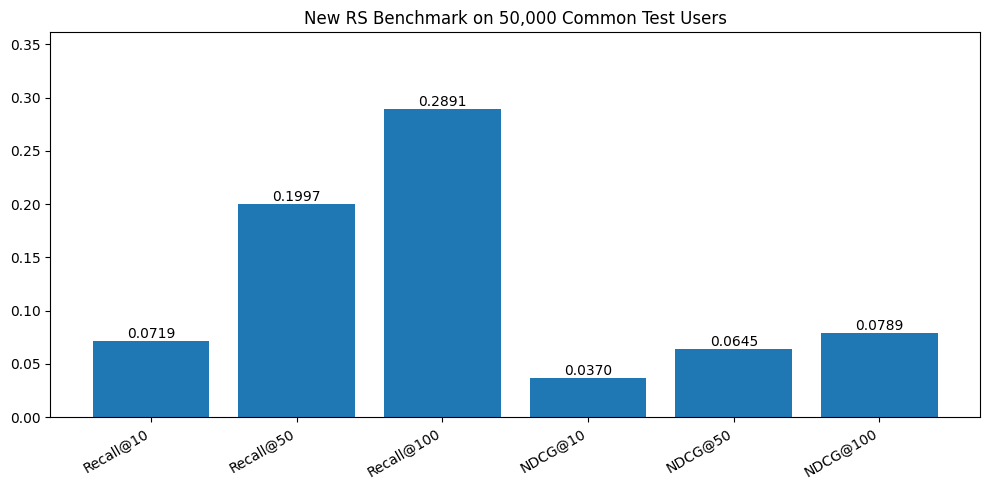

[NEW BENCHMARK] Saved detail : /content/drive/MyDrive/steam/steam_base2/eval_outputs/new_rs_benchmark_50k_detail.csv
[NEW BENCHMARK] Saved summary: /content/drive/MyDrive/steam/steam_base2/eval_outputs/new_rs_benchmark_50k_summary.json
[NEW BENCHMARK] Saved plot   : /content/drive/MyDrive/steam/steam_base2/eval_outputs/new_rs_benchmark_50k_plot.png


In [ ]:
# ====================================================================================
# CELL NEW-BENCHMARK: BENCHMARK RS MỚI TRÊN TẬP TEST CHUNG 50K USERS
# Fast batch evaluator: Dense game embedding + ALS + Popular
# Dùng cùng BENCHMARK_PATH với model cũ để so sánh công bằng.
# ====================================================================================

import os
import json
import math
import time
import pickle
import runpy
import gc

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

import torch


# =========================
# CONFIG
# =========================

# Tập benchmark chung 50k của Phú/Công.
# Nếu file này không tồn tại, code sẽ fallback sang TEST_PATH của RS mới.
COMMON_BENCHMARK_PATH = "/content/drive/MyDrive/steam/steam_100M/processed_data/eval_users_50k.parquet"

NEW_BENCHMARK_MAX_USERS = 50_000
NEW_BENCHMARK_TOPK = 100
NEW_BENCHMARK_KS = (10, 50, 100)

# Batch càng lớn càng nhanh nhưng dễ OOM. T4 15GB thường thử 1024 hoặc 2048.
NEW_BENCHMARK_BATCH_USERS = 1024

# Lấy tối đa N game gần nhất trong history để tạo dense user vector.
NEW_HISTORY_LIMIT = 50

# Trọng số fusion nhanh.
W_DENSE = 0.55
W_ALS = 0.35
W_POPULAR = 0.10

OUTPUT_DIR = "/content/drive/MyDrive/steam/steam_base2/eval_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DETAIL_CSV = f"{OUTPUT_DIR}/new_rs_benchmark_50k_detail.csv"
SUMMARY_JSON = f"{OUTPUT_DIR}/new_rs_benchmark_50k_summary.json"
PLOT_PATH = f"{OUTPUT_DIR}/new_rs_benchmark_50k_plot.png"


# =========================
# LOAD CELL 0 IF NEEDED
# =========================

def load_cell0_if_needed():
    required = [
        "TRAIN_PATH", "VAL_PATH", "TEST_PATH",
        "GAME_TEXT_EMB_PATH", "FAISS_NLP_APPIDS_PATH",
        "POPULAR_PATH", "ALS_MODEL_PATH",
        "USER2IDX_PATH", "ITEM2IDX_PATH",
    ]

    missing = [x for x in required if x not in globals()]
    if not missing:
        return

    if os.path.exists("cell_0.py"):
        print("[NEW BENCHMARK] Reload cell_0.py...")
        globals().update(runpy.run_path("cell_0.py"))
        return

    raise RuntimeError("Thiếu biến config. Hãy chạy Cell 0 trước.")


load_cell0_if_needed()


# =========================
# HELPER FUNCTIONS
# =========================

def find_col(cols, candidates):
    lower = {str(c).lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def resolve_user_item_cols(path):
    con = duckdb.connect()
    try:
        cols_df = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{path}')").df()
    finally:
        con.close()

    cols = cols_df["column_name"].tolist()

    user_col = find_col(cols, ["author_id", "user_id", "steamid", "steam_id", "uid"])
    item_col = find_col(cols, ["true_appid", "target_appid", "appid", "app_id", "game_id", "item_id"])

    if user_col is None or item_col is None:
        raise ValueError(f"Không tìm được cột user/item trong {path}. Columns={cols}")

    return user_col, item_col


def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def smart_get(mapping, key):
    if mapping is None:
        return None

    tries = [key, str(key)]
    try:
        tries.append(int(key))
    except Exception:
        pass

    for k in tries:
        try:
            if k in mapping:
                return mapping[k]
        except Exception:
            pass

    return None


def normalize_np(x, eps=1e-8):
    x = x.astype("float32", copy=False)
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norm, eps)


def row_minmax_torch(x, eps=1e-8):
    mn = torch.min(x, dim=1, keepdim=True).values
    mx = torch.max(x, dim=1, keepdim=True).values
    return (x - mn) / (mx - mn + eps)


def compute_user_metrics(ranked_appids, true_appids, ks):
    true_set = set(str(x) for x in true_appids)
    ranked = [str(x) for x in ranked_appids]

    out = {}

    first_hit = None
    for rank, aid in enumerate(ranked, start=1):
        if aid in true_set:
            first_hit = rank
            break

    for k in ks:
        topk = ranked[:k]
        topk_set = set(topk)
        hits = len(topk_set.intersection(true_set))

        recall = hits / max(len(true_set), 1)
        hitrate = 1.0 if hits > 0 else 0.0

        if first_hit is not None and first_hit <= k:
            mrr = 1.0 / first_hit
        else:
            mrr = 0.0

        dcg = 0.0
        for rank, aid in enumerate(topk, start=1):
            if aid in true_set:
                dcg += 1.0 / math.log2(rank + 1)

        ideal_hits = min(len(true_set), k)
        idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
        ndcg = dcg / idcg if idcg > 0 else 0.0

        out[f"Recall@{k}"] = recall
        out[f"HitRate@{k}"] = hitrate
        out[f"MRR@{k}"] = mrr
        out[f"NDCG@{k}"] = ndcg

    return out


# =========================
# LOAD COMMON BENCHMARK
# =========================

def load_common_benchmark():
    if os.path.exists(COMMON_BENCHMARK_PATH):
        benchmark_path = COMMON_BENCHMARK_PATH
        print("[NEW BENCHMARK] Using common benchmark:", benchmark_path)
    else:
        benchmark_path = TEST_PATH
        print("[NEW BENCHMARK][WARN] Common benchmark not found.")
        print("[NEW BENCHMARK] Fallback to TEST_PATH:", benchmark_path)

    user_col, item_col = resolve_user_item_cols(benchmark_path)

    con = duckdb.connect()
    con.execute("PRAGMA memory_limit='8GB'")
    con.execute("PRAGMA threads=4")

    try:
        q = f"""
            WITH base AS (
                SELECT
                    CAST({user_col} AS VARCHAR) AS author_id,
                    CAST({item_col} AS VARCHAR) AS true_appid
                FROM read_parquet('{benchmark_path}')
                WHERE {user_col} IS NOT NULL
                  AND {item_col} IS NOT NULL
            ),
            sampled_users AS (
                SELECT DISTINCT author_id
                FROM base
                ORDER BY hash(author_id || '42')
                LIMIT {int(NEW_BENCHMARK_MAX_USERS)}
            )
            SELECT b.author_id, b.true_appid
            FROM base b
            JOIN sampled_users s
            ON b.author_id = s.author_id
        """
        df = con.execute(q).df()
    finally:
        con.close()

    df["author_id"] = df["author_id"].astype(str)
    df["true_appid"] = df["true_appid"].astype(str)

    grouped = (
        df.groupby("author_id")["true_appid"]
        .apply(lambda x: sorted(set(map(str, x))))
        .reset_index()
        .rename(columns={"true_appid": "true_appids"})
    )

    print(f"[NEW BENCHMARK] Target rows: {len(df):,}")
    print(f"[NEW BENCHMARK] Users      : {len(grouped):,}")

    return grouped, benchmark_path


def load_history_for_users(users_df):
    users_df = users_df[["author_id"]].drop_duplicates().copy()
    users_df["author_id"] = users_df["author_id"].astype(str)

    all_parts = []

    for path in [TRAIN_PATH, VAL_PATH]:
        user_col, item_col = resolve_user_item_cols(path)

        con = duckdb.connect()
        con.execute("PRAGMA memory_limit='8GB'")
        con.execute("PRAGMA threads=4")
        con.register("sampled_users", users_df)

        try:
            q = f"""
                SELECT
                    CAST(t.{user_col} AS VARCHAR) AS author_id,
                    CAST(t.{item_col} AS VARCHAR) AS appid
                FROM read_parquet('{path}') t
                JOIN sampled_users u
                ON CAST(t.{user_col} AS VARCHAR) = u.author_id
                WHERE t.{user_col} IS NOT NULL
                  AND t.{item_col} IS NOT NULL
            """
            part = con.execute(q).df()
            all_parts.append(part)
            print(f"[NEW BENCHMARK] Loaded history from {os.path.basename(path)}: {len(part):,}")
        finally:
            con.close()

    hist = pd.concat(all_parts, ignore_index=True)
    hist["author_id"] = hist["author_id"].astype(str)
    hist["appid"] = hist["appid"].astype(str)

    grouped = (
        hist.groupby("author_id")["appid"]
        .apply(lambda x: list(dict.fromkeys(map(str, x))))
        .reset_index()
        .rename(columns={"appid": "history_appids"})
    )

    print(f"[NEW BENCHMARK] Users with history: {len(grouped):,}")
    return dict(zip(grouped["author_id"], grouped["history_appids"]))


# =========================
# LOAD NEW RS ARTIFACTS
# =========================

def load_new_rs_artifacts():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("[NEW BENCHMARK] torch device:", device)

    appids = np.load(FAISS_NLP_APPIDS_PATH, allow_pickle=True).astype(str).tolist()
    appid_to_pos = {str(a): i for i, a in enumerate(appids)}

    game_emb = np.load(GAME_TEXT_EMB_PATH).astype("float32")
    if game_emb.shape[0] != len(appids):
        raise ValueError(f"Mismatch: game_emb={game_emb.shape}, appids={len(appids)}")

    game_emb = normalize_np(game_emb)
    print("[NEW BENCHMARK] Loaded game embeddings:", game_emb.shape)

    # Popular vector
    pop_vec = np.zeros(len(appids), dtype="float32")

    try:
        pop_df = pd.read_parquet(POPULAR_PATH)
        app_col = find_col(pop_df.columns, ["appid", "app_id", "game_id", "item_id"])
        if app_col is None:
            app_col = pop_df.columns[0]

        numeric_cols = [
            c for c in pop_df.columns
            if c != app_col and pd.api.types.is_numeric_dtype(pop_df[c])
        ]

        if numeric_cols:
            score_col = numeric_cols[0]
            tmp = pop_df[[app_col, score_col]].copy()
            tmp[score_col] = pd.to_numeric(tmp[score_col], errors="coerce").fillna(0)
            mx = tmp[score_col].max()
            tmp["pop_score"] = tmp[score_col] / mx if mx > 0 else 0.0
        else:
            tmp = pop_df[[app_col]].copy()
            tmp["pop_score"] = np.linspace(1.0, 0.0, len(tmp))

        for r in tmp.itertuples(index=False):
            aid = str(getattr(r, app_col))
            pos = appid_to_pos.get(aid)
            if pos is not None:
                pop_vec[pos] = float(getattr(r, "pop_score"))

        print("[NEW BENCHMARK] Loaded popular vector.")
    except Exception as e:
        print("[NEW BENCHMARK][WARN] Popular disabled:", repr(e))

    # ALS
    user2idx = None
    item2idx = None
    als_user_factors = None
    als_item_matrix = None

    try:
        user2idx = load_pickle(USER2IDX_PATH)
        item2idx = load_pickle(ITEM2IDX_PATH)
        als_model = load_pickle(ALS_MODEL_PATH)

        raw_user_factors = np.asarray(als_model.user_factors, dtype="float32")
        raw_item_factors = np.asarray(als_model.item_factors, dtype="float32")

        als_user_factors = normalize_np(raw_user_factors)
        als_item_matrix = np.zeros((len(appids), raw_item_factors.shape[1]), dtype="float32")

        found = 0
        for pos, aid in enumerate(appids):
            idx = smart_get(item2idx, aid)
            if idx is not None and int(idx) < raw_item_factors.shape[0]:
                als_item_matrix[pos] = raw_item_factors[int(idx)]
                found += 1

        als_item_matrix = normalize_np(als_item_matrix)
        print(f"[NEW BENCHMARK] Loaded ALS item factors: {found:,}/{len(appids):,}")

    except Exception as e:
        print("[NEW BENCHMARK][WARN] ALS disabled:", repr(e))

    return {
        "device": device,
        "appids": appids,
        "appid_to_pos": appid_to_pos,
        "game_emb": game_emb,
        "pop_vec": pop_vec,
        "user2idx": user2idx,
        "als_user_factors": als_user_factors,
        "als_item_matrix": als_item_matrix,
    }


def build_dense_user_matrix(batch_users, history_map, appid_to_pos, game_emb):
    dim = game_emb.shape[1]
    out = np.zeros((len(batch_users), dim), dtype="float32")
    hist_positions = []

    for i, uid in enumerate(batch_users):
        hist = history_map.get(str(uid), [])
        hist = hist[-NEW_HISTORY_LIMIT:]

        pos_list = []
        for aid in hist:
            pos = appid_to_pos.get(str(aid))
            if pos is not None:
                pos_list.append(pos)

        hist_positions.append(pos_list)

        if pos_list:
            out[i] = game_emb[pos_list].mean(axis=0)

    out = normalize_np(out)
    return out, hist_positions


def build_als_user_matrix(batch_users, user2idx, als_user_factors):
    if user2idx is None or als_user_factors is None:
        return None

    dim = als_user_factors.shape[1]
    out = np.zeros((len(batch_users), dim), dtype="float32")

    for i, uid in enumerate(batch_users):
        idx = smart_get(user2idx, uid)
        if idx is not None and int(idx) < als_user_factors.shape[0]:
            out[i] = als_user_factors[int(idx)]

    out = normalize_np(out)
    return out


# =========================
# MAIN BENCHMARK
# =========================

def run_new_rs_benchmark():
    start_time = time.time()

    ks = tuple(sorted(k for k in NEW_BENCHMARK_KS if k <= NEW_BENCHMARK_TOPK))
    if not ks:
        raise ValueError("Không có K hợp lệ. Hãy tăng TOPK hoặc giảm KS.")

    targets, benchmark_path = load_common_benchmark()
    history_map = load_history_for_users(targets)

    artifacts = load_new_rs_artifacts()

    device = artifacts["device"]
    appids = artifacts["appids"]
    appid_to_pos = artifacts["appid_to_pos"]
    game_emb = artifacts["game_emb"]
    pop_vec = artifacts["pop_vec"]
    user2idx = artifacts["user2idx"]
    als_user_factors = artifacts["als_user_factors"]
    als_item_matrix = artifacts["als_item_matrix"]

    target_map = dict(zip(targets["author_id"], targets["true_appids"]))
    users = targets["author_id"].astype(str).tolist()
    n_items = len(appids)

    game_emb_t = torch.tensor(game_emb.T, dtype=torch.float32, device=device)
    pop_t = torch.tensor(pop_vec.reshape(1, -1), dtype=torch.float32, device=device)

    if als_item_matrix is not None:
        als_item_t = torch.tensor(als_item_matrix.T, dtype=torch.float32, device=device)
    else:
        als_item_t = None

    rows = []

    print("=" * 80)
    print("NEW RS BENCHMARK ON COMMON 50K TEST".center(80))
    print("=" * 80)
    print("benchmark_path:", benchmark_path)
    print("users:", len(users))
    print("topK:", NEW_BENCHMARK_TOPK)
    print("ks:", ks)
    print("=" * 80)

    for start in tqdm(range(0, len(users), NEW_BENCHMARK_BATCH_USERS), desc="New RS Benchmark"):
        end = min(start + NEW_BENCHMARK_BATCH_USERS, len(users))
        batch_users = users[start:end]

        dense_user_np, hist_pos_lists = build_dense_user_matrix(
            batch_users=batch_users,
            history_map=history_map,
            appid_to_pos=appid_to_pos,
            game_emb=game_emb,
        )

        final_scores = torch.zeros((len(batch_users), n_items), dtype=torch.float32, device=device)

        dense_user_t = torch.tensor(dense_user_np, dtype=torch.float32, device=device)
        dense_scores = dense_user_t @ game_emb_t
        dense_scores = row_minmax_torch(dense_scores)
        final_scores += W_DENSE * dense_scores

        if als_item_t is not None:
            als_user_np = build_als_user_matrix(batch_users, user2idx, als_user_factors)
            als_user_t = torch.tensor(als_user_np, dtype=torch.float32, device=device)
            als_scores = als_user_t @ als_item_t
            als_scores = row_minmax_torch(als_scores)
            final_scores += W_ALS * als_scores

        final_scores += W_POPULAR * pop_t

        # Loại game user đã chơi khỏi recommendation.
        for bi, pos_list in enumerate(hist_pos_lists):
            if pos_list:
                final_scores[bi, pos_list] = -1e9

        _, top_idx = torch.topk(final_scores, k=NEW_BENCHMARK_TOPK, dim=1)
        top_idx = top_idx.detach().cpu().numpy()

        for bi, uid in enumerate(batch_users):
            ranked_appids = [appids[j] for j in top_idx[bi].tolist()]
            true_appids = target_map.get(uid, [])

            metric = compute_user_metrics(ranked_appids, true_appids, ks)

            row = {
                "author_id": uid,
                "n_history": len(history_map.get(uid, [])),
                "n_targets": len(true_appids),
            }
            row.update(metric)
            rows.append(row)

        gc.collect()

    detail_df = pd.DataFrame(rows)
    detail_df.to_csv(DETAIL_CSV, index=False, encoding="utf-8-sig")

    summary = {
        "model": "New RS Fast Hybrid",
        "benchmark_path": benchmark_path,
        "users": int(len(detail_df)),
        "topK": int(NEW_BENCHMARK_TOPK),
        "ks": list(ks),
        "weights": {
            "dense": W_DENSE,
            "als": W_ALS,
            "popular": W_POPULAR,
        },
        "elapsed_sec": round(time.time() - start_time, 2),
        "detail_csv": DETAIL_CSV,
    }

    for k in ks:
        for metric in ["Recall", "HitRate", "MRR", "NDCG"]:
            col = f"{metric}@{k}"
            summary[col] = float(pd.to_numeric(detail_df[col], errors="coerce").fillna(0).mean())

    with open(SUMMARY_JSON, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("=" * 80)
    print("NEW RS BENCHMARK SUMMARY")
    print(json.dumps(summary, ensure_ascii=False, indent=2))
    print("=" * 80)

    # Plot
    labels = [f"Recall@{k}" for k in ks] + [f"NDCG@{k}" for k in ks]
    values = [summary[x] for x in labels]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, values)
    plt.title(f"New RS Benchmark on {len(detail_df):,} Common Test Users")
    plt.ylim(0, max(values + [0.01]) * 1.25)
    plt.xticks(rotation=30, ha="right")

    for i, v in enumerate(values):
        plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=300)
    plt.show()

    print("[NEW BENCHMARK] Saved detail :", DETAIL_CSV)
    print("[NEW BENCHMARK] Saved summary:", SUMMARY_JSON)
    print("[NEW BENCHMARK] Saved plot   :", PLOT_PATH)

    return summary, detail_df


new_rs_benchmark_summary, new_rs_benchmark_detail = run_new_rs_benchmark()

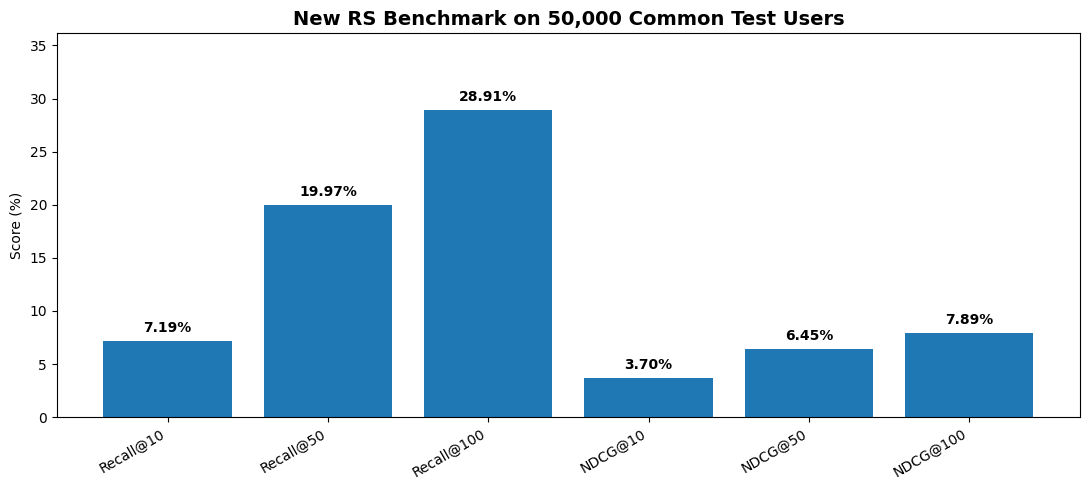

Saved percent chart: /content/drive/MyDrive/steam/steam_base2/eval_outputs/new_rs_benchmark_50k_plot_percent.png


In [ ]:
# ====================================================================================
# CELL: REDRAW NEW RS BENCHMARK CHART AS PERCENT (%)
# Chạy sau khi đã có new_rs_benchmark_summary
# ====================================================================================

import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "/content/drive/MyDrive/steam/steam_base2/eval_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PLOT_PERCENT_PATH = f"{OUTPUT_DIR}/new_rs_benchmark_50k_plot_percent.png"

ks = new_rs_benchmark_summary["ks"]

labels = [f"Recall@{k}" for k in ks] + [f"NDCG@{k}" for k in ks]
values_decimal = [new_rs_benchmark_summary[x] for x in labels]
values_percent = [v * 100 for v in values_decimal]

plt.figure(figsize=(11, 5))
bars = plt.bar(labels, values_percent)

plt.title(
    f"New RS Benchmark on {new_rs_benchmark_summary['users']:,} Common Test Users",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Score (%)")
plt.ylim(0, max(values_percent + [1]) * 1.25)
plt.xticks(rotation=30, ha="right")

for i, v in enumerate(values_percent):
    plt.text(
        i,
        v + max(values_percent) * 0.02,
        f"{v:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(PLOT_PERCENT_PATH, dpi=300)
plt.show()

print("Saved percent chart:", PLOT_PERCENT_PATH)

In [ ]:
# ============================================================
# CELL 10: RERANKER FEATURE BUILDER
# ============================================================

print("Loading feature caches...")

GAME_DOCS_DF = pd.read_parquet(GAME_DOCS_PATH)
GAME_DOCS_DF["appid"] = GAME_DOCS_DF["appid"].astype(str)

GAME_NUM_DF = GAME_DOCS_DF[[ "appid", "total_reviews", "positive_review_ratio", "avg_weighted_score", "global_avg_playtime", "avg_review_length", "deep_review_ratio" ]].copy()

USER_FEAT_DF = pd.read_parquet(USER_FEAT_PATH)
USER_FEAT_DF["author_id"] = USER_FEAT_DF["author_id"].astype(str)

for c in USER_FEAT_DF.columns:
    if c != "author_id" and USER_FEAT_DF[c].dtype == "object":
        USER_FEAT_DF[c] = USER_FEAT_DF[c].astype(str)

USER_NUM_COLS = [ "total_reviews_written", "max_games_owned", "total_lifetime_reviews", "avg_playtime_all_games", "avg_playtime_before_review", "steam_purchase_ratio", "deck_usage_ratio", ]

for c in USER_NUM_COLS:
    if c not in USER_FEAT_DF.columns:
        USER_FEAT_DF[c] = 0.0

GAME_TOKEN_SETS = { row.appid: set(simple_tokenize(row.tag_text)) for row in GAME_DOCS_DF[["appid", "tag_text"]].itertuples(index=False) }

HISTORY_TOKEN_CACHE = {}

def get_history_token_set(author_id, history_scope="train"):
    key = (str(author_id), history_scope)
    if key in HISTORY_TOKEN_CACHE:
        return HISTORY_TOKEN_CACHE[key]

    hist = ENGINE.get_history_appids(author_id, scope=history_scope, limit=50)
    s = set()
    for aid in hist:
        s.update(GAME_TOKEN_SETS.get(str(aid), set()))

    HISTORY_TOKEN_CACHE[key] = s
    return s

def build_rerank_features(cand_df, history_scope="train"):
    if cand_df is None or cand_df.empty:
        return pd.DataFrame(), []

    df = cand_df.copy()
    df["appid"] = df["appid"].astype(str)
    df["author_id"] = df["author_id"].astype(str)

    source_cols = ["dense_score", "bm25_score", "als_score", "i2i_score", "popular_score", "final_blend"]
    for c in source_cols:
        if c not in df.columns:
            df[c] = 0.0
    df[source_cols] = df[source_cols].fillna(0.0)

    df = df.merge(GAME_NUM_DF, on="appid", how="left")
    df = df.merge( USER_FEAT_DF[["author_id"] + USER_NUM_COLS], on="author_id", how="left" )
    num_cols = [ "total_reviews", "positive_review_ratio", "avg_weighted_score", "global_avg_playtime", "avg_review_length", "deep_review_ratio",] + USER_NUM_COLS
    for c in num_cols:
        if c not in df.columns:
            df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
    df["playtime_diff_abs"] = np.abs( df["avg_playtime_all_games"].fillna(0.0) - df["global_avg_playtime"].fillna(0.0) )
    overlaps = []
    jaccards = []
    for row in df[["author_id", "appid"]].itertuples(index=False):
        hset = get_history_token_set(row.author_id, history_scope=history_scope)
        gset = GAME_TOKEN_SETS.get(str(row.appid), set())
        if not hset or not gset:
            overlaps.append(0)
            jaccards.append(0.0)
        else:
            inter = len(hset & gset)
            union = len(hset | gset)
            overlaps.append(inter)
            jaccards.append(inter / max(union, 1))
    df["history_token_overlap"] = overlaps
    df["history_token_jaccard"] = jaccards

    feature_cols = source_cols + [ "total_reviews", "positive_review_ratio", "avg_weighted_score", "global_avg_playtime", "avg_review_length", "deep_review_ratio",
                                  "total_reviews_written", "max_games_owned", "total_lifetime_reviews", "avg_playtime_all_games", "avg_playtime_before_review",
                                   "steam_purchase_ratio", "deck_usage_ratio", "playtime_diff_abs", "history_token_overlap", "history_token_jaccard",
                                   ]

    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    return df, feature_cols

print("Feature builder ready.")

In [ ]:
# ============================================================
# CELL 10B: PATCH RERANKER FEATURES WITH SASREC SCORE
# ============================================================

def build_rerank_features(cand_df, history_scope="train"):
    if cand_df is None or cand_df.empty:
        return pd.DataFrame(), []

    df = cand_df.copy()
    df["appid"] = df["appid"].astype(str)
    df["author_id"] = df["author_id"].astype(str)

    source_cols = [ "dense_score", "bm25_score", "als_score", "i2i_score", "sasrec_score", "popular_score", "final_blend" ]

    for c in source_cols:
        if c not in df.columns:
            df[c] = 0.0
    df[source_cols] = df[source_cols].fillna(0.0)

    df = df.merge(GAME_NUM_DF, on="appid", how="left")
    df = df.merge( USER_FEAT_DF[["author_id"] + USER_NUM_COLS], on="author_id", how="left" )
    num_cols = [ "total_reviews", "positive_review_ratio", "avg_weighted_score", "global_avg_playtime", "avg_review_length", "deep_review_ratio", ] + USER_NUM_COLS
    for c in num_cols:
        if c not in df.columns:
            df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
    df["playtime_diff_abs"] = np.abs( df["avg_playtime_all_games"].fillna(0.0) - df["global_avg_playtime"].fillna(0.0) )
    overlaps = []
    jaccards = []
    for row in df[["author_id", "appid"]].itertuples(index=False):
        hset = get_history_token_set(row.author_id, history_scope=history_scope)
        gset = GAME_TOKEN_SETS.get(str(row.appid), set())
        if not hset or not gset:
            overlaps.append(0)
            jaccards.append(0.0)
        else:
            inter = len(hset & gset)
            union = len(hset | gset)
            overlaps.append(inter)
            jaccards.append(inter / max(union, 1))
    df["history_token_overlap"] = overlaps
    df["history_token_jaccard"] = jaccards

    # Interaction giữa RecSys score và NLP score
    df["sasrec_x_dense"] = df["sasrec_score"] * df["dense_score"]
    df["sasrec_x_als"] = df["sasrec_score"] * df["als_score"]
    df["dense_x_bm25"] = df["dense_score"] * df["bm25_score"]

    feature_cols = source_cols + [ "total_reviews", "positive_review_ratio", "avg_weighted_score", "global_avg_playtime", "avg_review_length", "deep_review_ratio",
                                  "total_reviews_written", "max_games_owned", "total_lifetime_reviews", "avg_playtime_all_games", "avg_playtime_before_review",
                                   "steam_purchase_ratio", "deck_usage_ratio", "playtime_diff_abs", "history_token_overlap", "history_token_jaccard",
                                   "sasrec_x_dense", "sasrec_x_als", "dense_x_bm25",
                                   ]

    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    return df, feature_cols


print("[V3] build_rerank_features patched. New feature includes sasrec_score.")

In [ ]:
# ============================================================
# CELL 11B: TRAIN LIGHTGBM RERANKER V3 WITH SASREC HARD NEGATIVES
# ============================================================

RETRAIN_RERANKER_V3 = True

RERANK_TRAIN_USERS = 12_000
CANDIDATES_PER_USER = 500
CANDIDATE_FINAL_LIMIT = 1500

if os.path.exists(RERANKER_V3_MODEL_PATH) and os.path.exists(RERANKER_V3_FEATURES_PATH) and not RETRAIN_RERANKER_V3:
    print("[V3] Reranker V3 exists. Skip.")
else:
    print("[V3] Build V3 hard-negative training set from val targets...")

    con = duckdb.connect()
    con.execute("PRAGMA memory_limit='6GB'")
    con.execute("PRAGMA threads=4")

    targets = con.execute(f"""
        SELECT
            CAST(author_id AS VARCHAR) AS author_id,
            CAST(appid AS VARCHAR) AS true_appid
        FROM read_parquet('{VAL_PATH}')
        ORDER BY random()
        LIMIT {RERANK_TRAIN_USERS}
    """).df()

    con.close()

    all_groups = []
    candidate_recall_before_forced_add = 0

    for row in tqdm(targets.itertuples(index=False), total=len(targets), desc="Build V3 rerank candidates"):
        uid = str(row.author_id)
        true_item = str(row.true_appid)
        cands = ENGINE.collect_candidates( author_id=uid, query="", history_scope="train", mode="evaluate", final_limit=CANDIDATE_FINAL_LIMIT )

        if cands is None or cands.empty:
            continue
        if true_item in set(cands["appid"].astype(str)):
            candidate_recall_before_forced_add += 1
        cands = cands.head(CANDIDATES_PER_USER).copy()

        # nếu true item không vào candidate, ép thêm vào để reranker có positive
        if true_item not in set(cands["appid"].astype(str)):
            add_row = {
                "appid": true_item,
                "author_id": uid,
                "dense_score": 0.0,
                "bm25_score": 0.0,
                "als_score": 0.0,
                "i2i_score": 0.0,
                "sasrec_score": 0.0,
                "popular_score": 0.0,
                "final_blend": 0.0,
            }
            cands = pd.concat([cands, pd.DataFrame([add_row])], ignore_index=True)

        cands["author_id"] = uid
        cands["label"] = (cands["appid"].astype(str) == true_item).astype(int)

        if cands["label"].sum() > 0 and len(cands) >= 2:
            all_groups.append(cands)

    train_raw = pd.concat(all_groups, ignore_index=True)
    train_raw_path = f"{ADV_CACHE_DIR}/reranker_v3_train_raw.parquet"
    train_raw.to_parquet(train_raw_path, index=False)

    print(f"[V3] Raw train rows: {len(train_raw):,}")
    print(f"[V3] Groups: {len(all_groups):,}")
    print(f"[V3] Candidate recall before forced-add: {candidate_recall_before_forced_add / max(len(all_groups), 1):.4f}")
    print(f"[V3] Saved raw candidates: {train_raw_path}")

    print("[V3] Build V3 features...")
    train_feat, feature_cols = build_rerank_features(train_raw, history_scope="train")

    train_feat = train_feat.sort_values("author_id").reset_index(drop=True)
    group_sizes = train_feat.groupby("author_id", sort=False).size().values

    X = train_feat[feature_cols]
    y = train_feat["label"].astype(int).values

    print(f"[V3] X shape: {X.shape}")
    print(f"[V3] Positive labels: {y.sum():,}")
    print(f"[V3] Feature cols: {feature_cols}")

    lgb_train = lgb.Dataset( data=X, label=y, group=group_sizes, free_raw_data=False )

    params = {
        "objective": "lambdarank", "metric": "ndcg", "eval_at": [10, 50, 100], "learning_rate": 0.03, "num_leaves": 63,
        "min_data_in_leaf": 50, "feature_fraction": 0.85, "bagging_fraction": 0.85, "bagging_freq": 1, "lambda_l2": 1.0, "verbose": -1, "seed": 42,
    }

    ranker_v3 = lgb.train(
        params=params,
        train_set=lgb_train,
        num_boost_round=800,
        callbacks=[ lgb.log_evaluation(period=50) ]
    )

    ranker_v3.save_model(RERANKER_V3_MODEL_PATH)

    with open(RERANKER_V3_FEATURES_PATH, "w", encoding="utf-8") as f:
        json.dump(feature_cols, f, ensure_ascii=False, indent=2)

    print(f"[V3] Saved reranker: {RERANKER_V3_MODEL_PATH}")
    print(f"[V3] Saved features: {RERANKER_V3_FEATURES_PATH}")

    imp = pd.DataFrame({
        "feature": feature_cols,
        "importance_gain": ranker_v3.feature_importance(importance_type="gain")
    }).sort_values("importance_gain", ascending=False)

    display(imp)

## CELL 12A - RERANKER LOADER HELPER

Cell này chỉ định nghĩa hàm `load_reranker()` để các cell demo query có thể chạy mà không bắt buộc phải chạy full Cell 12B evaluate trước.

In [ ]:
# ============================================================
# CELL 12A: RERANKER LOADER HELPER ONLY
# Dùng khi muốn chạy demo query mà không muốn chạy full Cell 12B evaluate.
# ============================================================

def load_reranker():
    import os
    import json

    try:
        import lightgbm as lgb
    except Exception as e:
        print(f"[V3] Không import được LightGBM: {e}. Fallback to final_blend.")
        return None, None

    if "RERANKER_V3_MODEL_PATH" not in globals() or "RERANKER_V3_FEATURES_PATH" not in globals():
        if "_load_cell0_if_needed" in globals():
            _load_cell0_if_needed()
        elif os.path.exists("cell_0.py"):
            import runpy
            globals().update(runpy.run_path("cell_0.py"))

    if "RERANKER_V3_MODEL_PATH" not in globals() or not os.path.exists(RERANKER_V3_MODEL_PATH):
        print("[V3] Reranker V3 not found. Fallback to final_blend.")
        return None, None

    model = lgb.Booster(model_file=RERANKER_V3_MODEL_PATH)

    if "RERANKER_V3_FEATURES_PATH" not in globals() or not os.path.exists(RERANKER_V3_FEATURES_PATH):
        print("[V3] Reranker feature list not found. Fallback to final_blend.")
        return None, None

    with open(RERANKER_V3_FEATURES_PATH, "r", encoding="utf-8") as f:
        features = json.load(f)

    return model, features

print("[CELL 12A] load_reranker() is ready.")


In [ ]:
# ============================================================
# CELL 12B: EVALUATE FINAL V3
# ============================================================

def load_reranker():
    if not os.path.exists(RERANKER_V3_MODEL_PATH):
        print("[V3] Reranker V3 not found. Fallback to final_blend.")
        return None, None
    model = lgb.Booster(model_file=RERANKER_V3_MODEL_PATH)
    with open(RERANKER_V3_FEATURES_PATH, "r", encoding="utf-8") as f:
        features = json.load(f)
    return model, features

def evaluate_final_v3(split="test", sample_users=3000, candidate_limit=1500):
    assert split in ["val", "test"]

    target_path = VAL_PATH if split == "val" else TEST_PATH
    history_scope = "train" if split == "val" else "train_val"

    ranker, feature_cols = load_reranker()

    con = duckdb.connect()
    con.execute("PRAGMA memory_limit='6GB'")
    con.execute("PRAGMA threads=4")

    targets = con.execute(f"""
        SELECT CAST(author_id AS VARCHAR) AS author_id, CAST(appid AS VARCHAR) AS true_appid
        FROM read_parquet('{target_path}')
        ORDER BY random()
        LIMIT {sample_users}
    """).df()

    con.close()

    metrics = {
        "candidate_recall@100": 0,
        "candidate_recall@500": 0,
        "candidate_recall@1000": 0,
        "final_hit@10": 0,
        "final_hit@50": 0,
        "final_hit@100": 0,
        "final_ndcg@10": 0.0,
        "final_ndcg@50": 0.0,
        "final_ndcg@100": 0.0,
    }

    valid = 0

    for row in tqdm(targets.itertuples(index=False), total=len(targets), desc=f"Evaluate V3 {split}"):
        uid = str(row.author_id)
        true_item = str(row.true_appid)

        cands = ENGINE.collect_candidates( author_id=uid, query="", history_scope=history_scope, mode="evaluate", final_limit=candidate_limit )

        if cands is None or cands.empty:
            continue

        valid += 1

        raw_ranked = cands.sort_values("final_blend", ascending=False)["appid"].astype(str).tolist()

        for k in [100, 500, 1000]:
            if true_item in raw_ranked[:k]:
                metrics[f"candidate_recall@{k}"] += 1

        if ranker is not None:
            feat_df, _ = build_rerank_features(cands, history_scope=history_scope)

            for c in feature_cols:
                if c not in feat_df.columns:
                    feat_df[c] = 0.0

            feat_df["final_score"] = ranker.predict(feat_df[feature_cols])
            final_ranked = feat_df.sort_values("final_score", ascending=False)["appid"].astype(str).tolist()
        else:
            final_ranked = raw_ranked

        for k in [10, 50, 100]:
            if true_item in final_ranked[:k]:
                metrics[f"final_hit@{k}"] += 1
                rank_pos = final_ranked.index(true_item) + 1
                metrics[f"final_ndcg@{k}"] += 1.0 / np.log2(rank_pos + 1)

    for key in metrics:
        metrics[key] = metrics[key] / max(valid, 1)

    metrics["valid_users"] = valid
    return metrics


v3_test_metrics = evaluate_final_v3( split="test", sample_users=3000, candidate_limit=1500 )

print("[V3] FINAL TEST METRICS")
print(json.dumps(v3_test_metrics, indent=2, ensure_ascii=False))

In [ ]:
# ============================================================
# CELL 13: PRODUCTION-LIKE RECOMMEND FUNCTION V2
# ============================================================

NSFW_PATTERNS = [
    "nudity", "sexual content", "hentai", "adult only", "nsfw", "sex"
]

def is_nsfw_game(appid):
    text = ENGINE.appid_to_tag_text.get(str(appid), "").lower()
    name = ENGINE.appid_to_name.get(str(appid), "").lower()
    full = text + " " + name
    return any(p in full for p in NSFW_PATTERNS)

def make_explanation(author_id, appid, history_scope="train_val"):
    hset = get_history_token_set(author_id, history_scope=history_scope)
    gset = GAME_TOKEN_SETS.get(str(appid), set())

    overlap = list(hset & gset)
    overlap = [x for x in overlap if len(x) > 2][:8]

    if overlap:
        return "Khớp với gu của bạn qua các tag/từ khóa: " + ", ".join(overlap)

    return "Được đề xuất từ tổ hợp NLP similarity, collaborative filtering và độ phổ biến/chất lượng."

def recommend_games_v2(
    author_id=None,
    query="",
    top_k=10,
    mode="discover",
    filter_nsfw=True,
    history_scope="train_val"
):
    """
    mode:
      discover: đề xuất game mới, loại game đã có trong history.
      continue: cho phép đề xuất cả game đã/đang chơi, dùng để debug gu user.
      evaluate: dùng cho offline eval.
    """

    cands = ENGINE.collect_candidates(
        author_id=str(author_id) if author_id else None,
        query=query,
        history_scope=history_scope,
        mode=mode,
        final_limit=2000
    )

    if cands.empty:
        return pd.DataFrame()

    if filter_nsfw:
        cands = cands[~cands["appid"].apply(is_nsfw_game)].copy()

    ranker, feature_cols = load_reranker()

    if ranker is not None and author_id:
        feat_df, _ = build_rerank_features(cands, history_scope=history_scope)

        for c in feature_cols:
            if c not in feat_df.columns:
                feat_df[c] = 0.0

        feat_df["rerank_score"] = ranker.predict(feat_df[feature_cols])
        ranked = feat_df.sort_values("rerank_score", ascending=False).head(top_k).copy()
    else:
        ranked = cands.sort_values("final_blend", ascending=False).head(top_k).copy()
        ranked["rerank_score"] = ranked["final_blend"]

    meta = GAME_DOCS_DF[[
        "appid", "name", "genres", "categories", "review_keywords",
        "positive_review_ratio", "avg_weighted_score", "total_reviews"
    ]].copy()

    ranked["appid"] = ranked["appid"].astype(str)
    result = ranked.merge(meta, on="appid", how="left")

    result["steam_link"] = "https://store.steampowered.com/app/" + result["appid"].astype(str)

    if author_id:
        result["explanation"] = result["appid"].apply(
            lambda x: make_explanation(str(author_id), str(x), history_scope=history_scope)
        )
    else:
        result["explanation"] = "Được đề xuất theo query ngôn ngữ và chất lượng game."

    show_cols = [
        "appid", "name", "rerank_score",
        "dense_score", "bm25_score", "als_score", "i2i_score", "popular_score",
        "genres", "categories", "review_keywords",
        "explanation", "steam_link"
    ]

    for c in show_cols:
        if c not in result.columns:
            result[c] = ""

    return result[show_cols].reset_index(drop=True)

In [ ]:
# ============================================================
# CELL 16A: INSTALL GRADIO WEB DEMO
# Chạy 1 lần sau khi Runtime reset.
# ============================================================

!pip -q install gradio

print("[CELL 16A] Gradio installed. Chạy tiếp Cell 16B rồi Cell 16C.")

[CELL 16A] Gradio installed. Chạy tiếp Cell 16B rồi Cell 16C.


In [ ]:
# ============================================================
# CELL 16B: GRADIO DEMO HELPERS - ROBUST LOADER + FORMATTER
# Không dùng Streamlit/FastAPI/localtunnel.
# ============================================================

import os
import json
import time
import runpy
import traceback

import numpy as np
import pandas as pd
import duckdb

try:
    import gradio as gr
except Exception as e:
    raise RuntimeError("Chưa cài gradio. Hãy chạy Cell 16A trước.") from e


# -----------------------------
# 1. Robust config / engine loader
# -----------------------------

DEMO_DEFAULT_EXAMPLE_QUERIES = [
    "open world survival crafting base building",
    "co-op zombie shooter multiplayer",
    "relaxing farming simulation cozy",
    "anime RPG story rich turn based",
    "tactical shooter multiplayer competitive",
    "roguelike deckbuilding strategy",
]

DEMO_NUMERIC_COLS = [
    "final_blend", "rerank_score",
    "dense_score", "bm25_score", "als_score", "i2i_score",
    "sasrec_score", "popular_score", "source_count",
]


def demo_load_cell0_if_needed():
    """Load lại config nếu Runtime bị reset và biến path bị mất."""
    required = [
        "TRAIN_PATH", "VAL_PATH", "TEST_PATH",
        "GAME_DOCS_PATH", "POPULAR_PATH",
        "BASE_EMBEDDING_MODEL", "FINETUNED_ENCODER_DIR",
        "FAISS_NLP_INDEX_PATH", "FAISS_NLP_APPIDS_PATH", "GAME_TEXT_EMB_PATH", "BM25_PATH",
        "USER2IDX_PATH", "ITEM2IDX_PATH", "IDX2ITEM_PATH", "USER_ITEM_MATRIX_PATH",
        "ALS_MODEL_PATH", "ITEM2ITEM_PATH", "DEVICE",
    ]
    missing = [x for x in required if x not in globals()]
    if not missing:
        return "[OK] Cell 0 config already loaded."
    if os.path.exists("cell_0.py"):
        globals().update(runpy.run_path("cell_0.py"))
        return "[OK] Reloaded config from cell_0.py."
    raise RuntimeError(
        "Thiếu biến config như GAME_DOCS_PATH/TRAIN_PATH và không thấy cell_0.py. "
        "Hãy chạy Cell 0 trước, gồm cả cell %%writefile cell_0.py và %run cell_0.py."
    )


def demo_has_sasrec_patch(engine):
    return bool( hasattr(engine, "sasrec_candidates") or hasattr(engine.__class__, "sasrec_candidates") )

def demo_load_engine(enable_sasrec=True, force_reload=False):
    """
    Load CandidateEngineV2 nếu ENGINE chưa tồn tại.
    Nếu enable_sasrec=True, cố patch thêm SASRec. Nếu thiếu checkpoint/file patch thì fallback Base Hybrid.
    """
    messages = []
    messages.append(demo_load_cell0_if_needed())

    if force_reload and "ENGINE" in globals() and globals().get("ENGINE") is not None:
        try:
            ENGINE.close()
        except Exception:
            pass
        globals().pop("ENGINE", None)
        messages.append("[OK] Old ENGINE closed and removed.")

    if "ENGINE" not in globals() or globals().get("ENGINE") is None:
        if "run_load_candidate_engine" not in globals():
            if os.path.exists("cell_8.py"):
                globals().update(runpy.run_path("cell_8.py"))
                messages.append("[OK] Loaded definitions from cell_8.py.")
            else:
                raise RuntimeError(
                    "Chưa có ENGINE và không thấy cell_8.py. Hãy chạy Cell 8 trước "
                    "hoặc chạy cell %%writefile cell_8.py trong notebook."
                )
        messages.append("[INFO] Loading CandidateEngineV2... lần đầu có thể mất vài phút.")
        result = run_load_candidate_engine(
            game_docs_path=GAME_DOCS_PATH,
            popular_path=POPULAR_PATH,
            base_embedding_model=BASE_EMBEDDING_MODEL,
            finetuned_encoder_dir=FINETUNED_ENCODER_DIR,
            device=DEVICE,
            faiss_index_path=FAISS_NLP_INDEX_PATH,
            faiss_appids_path=FAISS_NLP_APPIDS_PATH,
            game_text_emb_path=GAME_TEXT_EMB_PATH,
            bm25_path=BM25_PATH,
            user2idx_path=USER2IDX_PATH,
            item2idx_path=ITEM2IDX_PATH,
            idx2item_path=IDX2ITEM_PATH,
            user_item_matrix_path=USER_ITEM_MATRIX_PATH,
            als_model_path=ALS_MODEL_PATH,
            train_path=TRAIN_PATH,
            val_path=VAL_PATH,
            item2item_path=ITEM2ITEM_PATH,
            memory_limit="6GB",
            threads=4,
            run_audit=False,
        )
        globals()["cell8_result"] = result
        globals()["ENGINE"] = result["engine"]
        messages.append("[OK] ENGINE loaded.")
    else:
        messages.append("[OK] Reusing existing ENGINE.")

    engine = globals()["ENGINE"]

    if enable_sasrec and not demo_has_sasrec_patch(engine):
        try:
            # Load config again to expose TEXT_SASREC_MODEL_PATH if defined in Cell 0.
            demo_load_cell0_if_needed()
            sasrec_path = globals().get("TEXT_SASREC_MODEL_PATH", None)
            if not sasrec_path or not os.path.exists(sasrec_path):
                messages.append("[WARN] Không thấy TEXT_SASREC_MODEL_PATH/checkpoint. Demo chạy Base Hybrid, chưa có SASRec.")
            elif not os.path.exists("cell_8e.py"):
                messages.append("[WARN] Không thấy cell_8e.py. Demo chạy Base Hybrid, chưa patch SASRec.")
            else:
                if "patch_candidate_engine_with_sasrec" not in globals():
                    globals().update(runpy.run_path("cell_8e.py"))
                globals()["SASREC_SCORER"] = patch_candidate_engine_with_sasrec(
                    engine=engine,
                    text_sasrec_model_path=TEXT_SASREC_MODEL_PATH,
                    item2idx_path=ITEM2IDX_PATH,
                    idx2item_path=IDX2ITEM_PATH,
                    game_text_emb_path=GAME_TEXT_EMB_PATH,
                    faiss_nlp_appids_path=FAISS_NLP_APPIDS_PATH,
                    device=DEVICE,
                    default_top_sasrec=500,
                )
                messages.append("[OK] ENGINE patched with Text-Enhanced SASRec. Đây là Hybrid + SASRec.")
        except Exception as e:
            messages.append("[WARN] Patch SASRec failed, fallback Base Hybrid: " + repr(e))
    elif enable_sasrec and demo_has_sasrec_patch(engine):
        messages.append("[OK] ENGINE already has SASRec branch.")

    mode_name = "Hybrid + SASRec" if demo_has_sasrec_patch(engine) else "Base Hybrid"
    messages.append(f"[READY] Current engine mode: {mode_name}")
    return engine, "\n".join(messages)


# -----------------------------
# 2. Metadata / history helpers
# -----------------------------


def demo_get_meta_df(engine):
    meta = engine.game_docs.copy()
    meta["appid"] = meta["appid"].astype(str)
    for c in ["name", "genres", "categories", "review_keywords", "tag_text", "short_document"]:
        if c not in meta.columns:
            meta[c] = ""
    return meta


def demo_pick_example_user():
    """Lấy nhanh 1 user mẫu từ VAL_PATH để demo, tránh phải nhớ author_id."""
    demo_load_cell0_if_needed()
    con = duckdb.connect()
    con.execute("PRAGMA threads=4")
    try:
        q = f"""
            SELECT CAST(author_id AS VARCHAR) AS author_id
            FROM read_parquet('{VAL_PATH}')
            WHERE author_id IS NOT NULL
            LIMIT 1
        """
        df = con.execute(q).df()
    finally:
        con.close()
    if df.empty:
        return ""
    return str(df.iloc[0]["author_id"])


def demo_history_df(author_id, history_scope="train_val", limit=20):
    engine, _ = demo_load_engine(enable_sasrec=False, force_reload=False)
    author_id = str(author_id).strip()
    if not author_id:
        return pd.DataFrame(columns=["rank", "appid", "name", "genres", "short_document"])

    hist = engine.get_history_appids(author_id, scope=history_scope, limit=int(limit))
    if not hist:
        return pd.DataFrame(columns=["rank", "appid", "name", "genres", "short_document"])

    meta = demo_get_meta_df(engine)
    df = pd.DataFrame({"appid": [str(x) for x in hist]})
    df["rank"] = np.arange(1, len(df) + 1)
    df = df.merge(meta[["appid", "name", "genres", "short_document"]], on="appid", how="left")
    return df[["rank", "appid", "name", "genres", "short_document"]]


def demo_profile_text(author_id=None, query="", history_scope="train_val"):
    engine, _ = demo_load_engine(enable_sasrec=False, force_reload=False)
    try:
        text = engine.make_user_profile_text(
            author_id=str(author_id).strip() if author_id else None,
            query=str(query).strip() if query else "",
            history_scope=history_scope,
            max_items=12,
        )
        return text if text else "Không có profile text. Hãy nhập user_id hoặc query."
    except Exception as e:
        return "Không tạo được profile text: " + repr(e)


# -----------------------------
# 3. Recommendation formatting
# -----------------------------

NSFW_PATTERNS_DEMO = ["nudity", "sexual content", "hentai", "adult only", "nsfw", "sex"]


def demo_is_nsfw(engine, appid):
    appid = str(appid)
    text = str(engine.appid_to_tag_text.get(appid, "")).lower()
    name = str(engine.appid_to_name.get(appid, "")).lower()
    full = text + " " + name
    return any(p in full for p in NSFW_PATTERNS_DEMO)


def demo_collect_candidates(engine, author_id=None, query="", top_n=10, mode="discover", history_scope="train_val"):
    """Collect nhẹ hơn default để demo phản hồi nhanh."""
    kwargs = dict(
        author_id=str(author_id).strip() if author_id else None,
        query=str(query).strip() if query else "",
        history_scope=history_scope,
        mode=mode,
        top_dense=350,
        top_bm25=250,
        top_als=350,
        top_i2i=350,
        top_popular=100,
        final_limit=max(200, int(top_n) * 40),
    )
    if demo_has_sasrec_patch(engine):
        kwargs["top_sasrec"] = 350
    return engine.collect_candidates(**kwargs)


def demo_explain_row(row):
    reasons = []
    def val(col):
        try:
            return float(row.get(col, 0.0) or 0.0)
        except Exception:
            return 0.0

    if val("sasrec_score") > 0.05:
        reasons.append("SASRec: phù hợp với thứ tự/lịch sử chơi gần đây")
    if val("als_score") > 0.05:
        reasons.append("ALS: người dùng có hành vi tương tự cũng quan tâm")
    if val("i2i_score") > 0.05:
        reasons.append("Item2Item: thường được chơi cùng các game trong history")
    if val("dense_score") > 0.05:
        reasons.append("Dense/FAISS: gần về ngữ nghĩa nội dung game")
    if val("bm25_score") > 0.05:
        reasons.append("BM25: khớp keyword/tag/mô tả")
    if val("popular_score") > 0.05:
        reasons.append("Popular: game có tín hiệu phổ biến/chất lượng")

    if not reasons:
        reasons.append("Được chọn từ candidate fusion của nhiều nhánh")
    return " | ".join(reasons[:3])


def demo_format_candidates(engine, cands, author_id=None, query="", top_n=10, filter_nsfw=True):
    if cands is None or cands.empty:
        return pd.DataFrame(columns=[
            "Rank", "AppID", "Game", "Final", "Dense", "BM25", "ALS", "I2I", "SASRec", "Popular", "Sources", "Why", "Steam"
        ])

    df = cands.copy()
    df["appid"] = df["appid"].astype(str)

    for c in DEMO_NUMERIC_COLS:
        if c not in df.columns:
            df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    if filter_nsfw:
        df = df[~df["appid"].apply(lambda x: demo_is_nsfw(engine, x))].copy()

    score_col = "rerank_score" if "rerank_score" in df.columns and df["rerank_score"].sum() != 0 else "final_blend"
    df = df.sort_values(score_col, ascending=False).head(int(top_n)).copy()

    meta = demo_get_meta_df(engine)
    keep_meta = ["appid", "name", "genres", "categories", "review_keywords"]
    df = df.merge(meta[keep_meta], on="appid", how="left")

    df["Rank"] = np.arange(1, len(df) + 1)
    df["AppID"] = df["appid"].astype(str)
    df["Game"] = df["name"].fillna("Unknown")
    df["Final"] = df[score_col].astype(float).round(4)
    df["Dense"] = df["dense_score"].astype(float).round(4)
    df["BM25"] = df["bm25_score"].astype(float).round(4)
    df["ALS"] = df["als_score"].astype(float).round(4)
    df["I2I"] = df["i2i_score"].astype(float).round(4)
    df["SASRec"] = df["sasrec_score"].astype(float).round(4)
    df["Popular"] = df["popular_score"].astype(float).round(4)
    df["Sources"] = df["source_count"].astype(float).fillna(0).astype(int)
    df["Genres"] = df["genres"].fillna("").astype(str)
    df["Tags/Keywords"] = df["review_keywords"].fillna("").astype(str).str.slice(0, 160)
    df["Why"] = df.apply(demo_explain_row, axis=1)
    df["Steam"] = "https://store.steampowered.com/app/" + df["AppID"].astype(str)

    show_cols = [
        "Rank", "AppID", "Game", "Final", "Dense", "BM25", "ALS", "I2I", "SASRec", "Popular", "Sources", "Genres", "Tags/Keywords", "Why", "Steam"
    ]
    return df[show_cols].reset_index(drop=True)


# -----------------------------
# 4. Gradio callback functions
# -----------------------------


def demo_status(enable_sasrec=True, force_reload=False):
    try:
        engine, msg = demo_load_engine(enable_sasrec=enable_sasrec, force_reload=force_reload)
        extra = [
            "",
            f"Game catalog: {len(engine.game_docs):,}",
            f"FAISS items: {getattr(engine.faiss_index, 'ntotal', 'unknown')}",
            f"SASRec patched: {demo_has_sasrec_patch(engine)}",
        ]
        return msg + "\n" + "\n".join(extra)
    except Exception:
        return "[ERROR]\n" + traceback.format_exc()


def demo_run_hybrid(author_id, query, top_n, mode, history_scope, filter_nsfw, enable_sasrec):
    try:
        engine, msg = demo_load_engine(enable_sasrec=enable_sasrec, force_reload=False)
        author_id = str(author_id).strip()
        query = str(query).strip()
        if not author_id and not query:
            return "Hãy nhập author_id hoặc query.", pd.DataFrame(), "", pd.DataFrame()

        cands = demo_collect_candidates(engine, author_id=author_id or None, query=query, top_n=top_n, mode=mode, history_scope=history_scope)
        rec_df = demo_format_candidates(engine, cands, author_id=author_id, query=query, top_n=top_n, filter_nsfw=filter_nsfw)
        hist_df = demo_history_df(author_id, history_scope=history_scope, limit=20) if author_id else pd.DataFrame()
        profile = demo_profile_text(author_id=author_id or None, query=query, history_scope=history_scope)

        status = (
            "### Kết quả Hybrid User + Query\n"
            f"- Engine: {'Hybrid + SASRec' if demo_has_sasrec_patch(engine) else 'Base Hybrid'}\n"
            f"- Mode: `{mode}` | History scope: `{history_scope}` | Top N: `{top_n}`\n"
            f"- Candidates returned: `{0 if cands is None else len(cands)}`\n\n"
            "Tab này là demo chính: kết hợp user history + query tự nhiên + Dense/FAISS + BM25 + ALS + Item2Item + Popular + SASRec nếu đã patch."
        )
        return status, hist_df, profile, rec_df
    except Exception:
        return "[ERROR]\n```text\n" + traceback.format_exc() + "\n```", pd.DataFrame(), "", pd.DataFrame()


def demo_run_user(author_id, top_n, mode, history_scope, filter_nsfw, enable_sasrec):
    return demo_run_hybrid(author_id, "", top_n, mode, history_scope, filter_nsfw, enable_sasrec)


def demo_run_query(query, top_n, mode, filter_nsfw, enable_sasrec):
    status, hist_df, profile, rec_df = demo_run_hybrid("", query, top_n, mode, "train_val", filter_nsfw, enable_sasrec)
    return status, profile, rec_df


def demo_compare_base_vs_sasrec(author_id, query, top_n, mode, history_scope, filter_nsfw):
    try:
        engine, msg = demo_load_engine(enable_sasrec=True, force_reload=False)
        author_id = str(author_id).strip()
        query = str(query).strip()
        if not author_id and not query:
            return "Hãy nhập author_id hoặc query để so sánh.", pd.DataFrame(), pd.DataFrame()

        # Base Hybrid: nếu engine đã patch thì collect_candidates_base vẫn là hàm gốc trước SASRec.
        if hasattr(engine, "collect_candidates_base"):
            kwargs = dict(
                author_id=author_id or None,
                query=query,
                history_scope=history_scope,
                mode=mode,
                top_dense=350,
                top_bm25=250,
                top_als=350,
                top_i2i=350,
                top_popular=100,
                final_limit=max(200, int(top_n) * 40),
            )
            base_cands = engine.collect_candidates_base(**kwargs)
        else:
            base_cands = demo_collect_candidates(engine, author_id=author_id or None, query=query, top_n=top_n, mode=mode, history_scope=history_scope)

        # V3 current: có SASRec nếu patch thành công.
        v3_cands = demo_collect_candidates(engine, author_id=author_id or None, query=query, top_n=top_n, mode=mode, history_scope=history_scope)

        base_df = demo_format_candidates(engine, base_cands, author_id=author_id, query=query, top_n=top_n, filter_nsfw=filter_nsfw)
        v3_df = demo_format_candidates(engine, v3_cands, author_id=author_id, query=query, top_n=top_n, filter_nsfw=filter_nsfw)

        status = (
            "### Base Hybrid vs Hybrid + SASRec\n"
            f"- SASRec patched: `{demo_has_sasrec_patch(engine)}`\n"
            "- Base Hybrid = Dense/FAISS + BM25 + ALS + Item2Item + Popular.\n"
            "- Hybrid + SASRec = Base Hybrid + Text-Enhanced SASRec.\n"
            "- Nếu bảng hai bên giống nhau, nghĩa là SASRec chưa được patch hoặc checkpoint chưa tồn tại."
        )
        return status, base_df, v3_df
    except Exception:
        return "[ERROR]\n```text\n" + traceback.format_exc() + "\n```", pd.DataFrame(), pd.DataFrame()


print("[CELL 16B] Demo helpers ready. Chạy Cell 16C để mở Gradio UI.")

[CELL 16B] Demo helpers ready. Chạy Cell 16C để mở Gradio UI.


In [ ]:
# ============================================================
# CELL 16C: START GRADIO WEB DEMO
# Chạy cell này để mở giao diện trực quan trong Colab.
# Không cần Streamlit/FastAPI/localtunnel.
# ============================================================

import gradio as gr

# Đóng app cũ nếu chạy lại cell nhiều lần.
try:
    demo_app.close()
except Exception:
    pass

with gr.Blocks(
    title="Steam Hybrid Game Recommender Demo",
    theme=gr.themes.Soft(),
    css="""
    .gradio-container {max-width: 1500px !important;}
    .demo-note {font-size: 15px;}
    """,
) as demo_app:
    gr.Markdown(
        """
        # 🎮 Steam Hybrid Game Recommender Demo

        Demo trực quan cho hệ thống gợi ý game Steam.
        **Tab nên trình diễn chính:** `User + Query Hybrid` vì nó thể hiện đầy đủ user history + query tự nhiên + nhiều nhánh gợi ý.
        """
    )

    with gr.Row():
        with gr.Column(scale=2):
            enable_sasrec_global = gr.Checkbox(value=True, label="Cố gắng dùng Hybrid + SASRec nếu checkpoint tồn tại")
            force_reload_global = gr.Checkbox(value=False, label="Force reload ENGINE")
        with gr.Column(scale=1):
            load_btn = gr.Button("Load / Check Engine", variant="primary")
    engine_status = gr.Textbox(label="Engine status", lines=8)
    load_btn.click(
        demo_status,
        inputs=[enable_sasrec_global, force_reload_global],
        outputs=[engine_status],
    )

    gr.Markdown("---")

    common_topn = gr.Slider(5, 30, value=10, step=1, label="Top N")
    common_mode = gr.Dropdown(["discover", "continue", "evaluate"], value="discover", label="Mode")
    common_scope = gr.Dropdown(["train_val", "train"], value="train_val", label="History scope")

    with gr.Tab("⭐ Demo chính: User + Query Hybrid"):
        gr.Markdown(
            "Nhập cả `author_id` và query. Đây là kịch bản đẹp nhất để trình bày với giảng viên."
        )
        with gr.Row():
            hybrid_user = gr.Textbox(label="author_id", placeholder="VD: 76561199241018614")
            hybrid_query = gr.Textbox(label="Query tự nhiên", value="open world survival crafting base building")
        with gr.Row():
            hybrid_topn = gr.Slider(5, 30, value=10, step=1, label="Top N")
            hybrid_mode = gr.Dropdown(["discover", "continue", "evaluate"], value="discover", label="Mode")
            hybrid_scope = gr.Dropdown(["train_val", "train"], value="train_val", label="History scope")
            hybrid_nsfw = gr.Checkbox(value=True, label="Filter NSFW")
            hybrid_sasrec = gr.Checkbox(value=True, label="Use SASRec if available")
        with gr.Row():
            hybrid_run = gr.Button("Recommend", variant="primary")
            hybrid_pick = gr.Button("Lấy user mẫu")
        hybrid_status = gr.Markdown()
        with gr.Row():
            hybrid_history = gr.Dataframe(label="User history / game đã chơi", wrap=True, interactive=False)
            hybrid_profile = gr.Textbox(label="Profile text được tạo từ user/query", lines=12)
        hybrid_recs = gr.Dataframe(label="Top recommendations", wrap=True, interactive=False)

        hybrid_run.click(
            demo_run_hybrid,
            inputs=[hybrid_user, hybrid_query, hybrid_topn, hybrid_mode, hybrid_scope, hybrid_nsfw, hybrid_sasrec],
            outputs=[hybrid_status, hybrid_history, hybrid_profile, hybrid_recs],
        )
        hybrid_pick.click(demo_pick_example_user, outputs=[hybrid_user])

        gr.Examples(
            examples=[
                ["", "open world survival crafting base building", 10, "discover", "train_val", True, True],
                ["", "co-op zombie shooter multiplayer", 10, "discover", "train_val", True, True],
                ["", "relaxing farming simulation cozy", 10, "discover", "train_val", True, True],
            ],
            inputs=[hybrid_user, hybrid_query, hybrid_topn, hybrid_mode, hybrid_scope, hybrid_nsfw, hybrid_sasrec],
        )

    with gr.Tab("👤 User-based Recommendation"):
        gr.Markdown("Chỉ nhập user_id để chứng minh hệ thống cá nhân hóa theo lịch sử chơi game.")
        with gr.Row():
            user_user = gr.Textbox(label="author_id", placeholder="VD: 76561199241018614")
            user_topn = gr.Slider(5, 30, value=10, step=1, label="Top N")
            user_mode = gr.Dropdown(["discover", "continue", "evaluate"], value="discover", label="Mode")
            user_scope = gr.Dropdown(["train_val", "train"], value="train_val", label="History scope")
            user_nsfw = gr.Checkbox(value=True, label="Filter NSFW")
            user_sasrec = gr.Checkbox(value=True, label="Use SASRec if available")
        with gr.Row():
            user_run = gr.Button("Recommend by user", variant="primary")
            user_pick = gr.Button("Lấy user mẫu")
        user_status = gr.Markdown()
        with gr.Row():
            user_history = gr.Dataframe(label="User history", wrap=True, interactive=False)
            user_profile = gr.Textbox(label="Profile text", lines=12)
        user_recs = gr.Dataframe(label="Top recommendations", wrap=True, interactive=False)

        user_run.click(
            demo_run_user,
            inputs=[user_user, user_topn, user_mode, user_scope, user_nsfw, user_sasrec],
            outputs=[user_status, user_history, user_profile, user_recs],
        )
        user_pick.click(demo_pick_example_user, outputs=[user_user])

    with gr.Tab("🔎 Query-based Discovery"):
        gr.Markdown("Không cần user_id. Tab này giống semantic game discovery bằng query tự nhiên.")
        with gr.Row():
            query_query = gr.Textbox(label="Query", value="open world survival crafting base building")
            query_topn = gr.Slider(5, 30, value=10, step=1, label="Top N")
            query_mode = gr.Dropdown(["discover", "continue", "evaluate"], value="discover", label="Mode")
            query_nsfw = gr.Checkbox(value=True, label="Filter NSFW")
            query_sasrec = gr.Checkbox(value=False, label="Use SASRec if available")
        query_run = gr.Button("Search / Recommend by query", variant="primary")
        query_status = gr.Markdown()
        query_profile = gr.Textbox(label="Query profile text", lines=7)
        query_recs = gr.Dataframe(label="Top games matching query", wrap=True, interactive=False)
        query_run.click(
            demo_run_query,
            inputs=[query_query, query_topn, query_mode, query_nsfw, query_sasrec],
            outputs=[query_status, query_profile, query_recs],
        )
        gr.Examples(
            examples=[[q, 10, "discover", True, False] for q in DEMO_DEFAULT_EXAMPLE_QUERIES],
            inputs=[query_query, query_topn, query_mode, query_nsfw, query_sasrec],
        )

    with gr.Tab("🆚 Base Hybrid vs Hybrid + SASRec"):
        gr.Markdown(
            "So sánh nhanh hai bảng kết quả trên cùng input. Nếu chưa patch SASRec, hai bảng có thể giống nhau."
        )
        with gr.Row():
            cmp_user = gr.Textbox(label="author_id", placeholder="VD: 76561199241018614")
            cmp_query = gr.Textbox(label="Query optional", value="tactical shooter multiplayer")
        with gr.Row():
            cmp_topn = gr.Slider(5, 30, value=10, step=1, label="Top N")
            cmp_mode = gr.Dropdown(["discover", "continue", "evaluate"], value="discover", label="Mode")
            cmp_scope = gr.Dropdown(["train_val", "train"], value="train_val", label="History scope")
            cmp_nsfw = gr.Checkbox(value=True, label="Filter NSFW")
        with gr.Row():
            cmp_run = gr.Button("Compare", variant="primary")
            cmp_pick = gr.Button("Lấy user mẫu")
        cmp_status = gr.Markdown()
        with gr.Row():
            cmp_base = gr.Dataframe(label="Base Hybrid: Dense + BM25 + ALS + Item2Item + Popular", wrap=True, interactive=False)
            cmp_v3 = gr.Dataframe(label="Hybrid + SASRec", wrap=True, interactive=False)

        cmp_run.click(
            demo_compare_base_vs_sasrec,
            inputs=[cmp_user, cmp_query, cmp_topn, cmp_mode, cmp_scope, cmp_nsfw],
            outputs=[cmp_status, cmp_base, cmp_v3],
        )
        cmp_pick.click(demo_pick_example_user, outputs=[cmp_user])

    with gr.Tab("📌 Cách thuyết trình nhanh"):
        gr.Markdown(
            """
            ### Luồng demo nên nói với thầy

            1. **User-based:** hệ thống đọc lịch sử game của user và tạo profile sở thích.
            2. **Query-based:** khi không có user hoặc muốn khám phá, hệ thống hiểu query tự nhiên bằng Dense/FAISS + BM25.
            3. **User + Query Hybrid:** kết hợp cả gu cá nhân và nhu cầu hiện tại. Đây là demo chính.
            4. **Base vs SASRec:** SASRec bổ sung tín hiệu thứ tự chơi game, giúp hệ thống không chỉ biết user thích gì mà còn học xu hướng chơi tiếp theo.

            ### Gợi ý cài đặt khi demo

            - `mode = discover`: đề xuất game mới, loại game đã chơi.
            - `history_scope = train_val`: dùng nhiều lịch sử hơn, giống demo sản phẩm.
            - `top_n = 10`: dễ nhìn, đủ để trình bày.
            """
        )

print("[CELL 16C] Launching Gradio app. Đợi vài giây để Colab sinh public link.")
demo_app.launch(share=True, debug=False, show_error=True)

[CELL 16C] Launching Gradio app. Đợi vài giây để Colab sinh public link.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0c09a212f6fd51a6d3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
